# Mini-project: Applying supervised learning to predict student dropout

## Objective
In this mini-project, I will apply advanced machine learning techniques to create a predictive model for student dropout. This project will involve comprehensive data exploration, preprocessing, and feature engineering to ensure high-quality input for the models. I will employ and compare multiple predictive algorithms, such as XGBoost, and a neural network-based model, to determine the most effective model for predicting student dropout.

In the Notebook, I will:
- explore the data sets, taking a phased approach
- preprocess the data and conduct feature engineering
- predict the dropout rate using XGBoost, and a neural network-based model.

# Stage 1: Data Import

In [ ]:
import datetime
import re

import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    ParameterGrid
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras import Sequential, Input, layers
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

!pip install country_converter
import country_converter as coco

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Import Stage 1 Data.

file_url = "https://drive.google.com/uc?id=1pA8DDYmQuaLyxADCOZe1QaSQwF16q1J6"

study_data = pd.read_csv(file_url)

In [ ]:
# Set random seed to make model results consistent in the notebook.

seed = 0

## Data Cleaning

Prior to pre-processing for model-readiness, I will inspect and clean the dataset.

Focus:

- Removing useless features
- Removing or reducing high cardinality features
- Feature transformation on applicable data

**Stage 1: Pre-processing instructions**
- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with > 50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.

In [ ]:
# Inspect raw dataset.

print(study_data.head(5))

     CentreName  LearnerCode BookingType              LeadSource DiscountType  \
0  ISC_Aberdeen      2284932       Agent  Standard Agent Booking          NaN   
1  ISC_Aberdeen      2399500       Agent  Standard Agent Booking          NaN   
2  ISC_Aberdeen      2424946       Agent  Standard Agent Booking          NaN   
3  ISC_Aberdeen      2426583       Agent  Standard Agent Booking          NaN   
4  ISC_Aberdeen      2434674       Agent  Standard Agent Booking          NaN   

  DateofBirth Gender Nationality                          HomeState  \
0  13/01/1998   Male     Chinese  Jianye District; Jiangsu Province   
1   12/2/1998   Male     Chinese                                NaN   
2    7/4/2000   Male     Chinese                                NaN   
3  18/05/1999   Male     Chinese                                NaN   
4  19/04/1996   Male     Chinese                                NaN   

                 HomeCity             CourseLevel  \
0                 Nanjing        

In [ ]:
# Get shape of the raw dataset.

print(study_data.shape, "\n")

# Get info on the dataset.

print(study_data.info())

# For features with dtype object - ensure strs are trimmed.

for col in study_data.columns:
  if study_data.dtypes[col] == 'object':
    study_data[col] = study_data[col].str.strip()

(25059, 16) 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   CentreName             25059 non-null  object
 1   LearnerCode            25059 non-null  int64 
 2   BookingType            25059 non-null  object
 3   LeadSource             25059 non-null  object
 4   DiscountType           7595 non-null   object
 5   DateofBirth            25059 non-null  object
 6   Gender                 25059 non-null  object
 7   Nationality            25059 non-null  object
 8   HomeState              8925 non-null   object
 9   HomeCity               21611 non-null  object
 10  CourseLevel            25059 non-null  object
 11  CourseName             25059 non-null  object
 12  IsFirstIntake          25059 non-null  bool  
 13  CompletedCourse        25059 non-null  object
 14  ProgressionDegree      24184 non-null  object
 15  Progr

In [ ]:
# Check for duplicates.

print(f"Duplicated Values: {study_data.duplicated().sum()}\n")

# Check for the number of missing columns in each column.

print(study_data.isnull().sum(),"\n")

# for loop listing columns to remove (NaN > 0.5).

for col in study_data.columns:
  is_null = study_data[col].isnull().sum()
  null_stat = is_null / len(study_data)
  if is_null / len(study_data) > 0.5:
    print(f"Remove {col}, {null_stat:.2f}")

Duplicated Values: 0

CentreName                   0
LearnerCode                  0
BookingType                  0
LeadSource                   0
DiscountType             17464
DateofBirth                  0
Gender                       0
Nationality                  0
HomeState                16134
HomeCity                  3448
CourseLevel                  0
CourseName                   0
IsFirstIntake                0
CompletedCourse              0
ProgressionDegree          875
ProgressionUniversity        0
dtype: int64 

Remove DiscountType, 0.70
Remove HomeState, 0.64


Removing columns that are not useful for analysis & those with > 50% data missing.

In [ ]:
# Drop LearnerCode and values with >0.5 NaN values.

study_data_clean = study_data.drop(columns=['LearnerCode','DiscountType','HomeState'])

# Specifying number of unique values for each column.

for col in study_data_clean.columns:
  print(f"{col}: {study_data_clean[col].nunique()}")

CentreName: 19
BookingType: 2
LeadSource: 7
DateofBirth: 4705
Gender: 2
Nationality: 151
HomeCity: 5877
CourseLevel: 4
CourseName: 172
IsFirstIntake: 2
CompletedCourse: 2
ProgressionDegree: 2616
ProgressionUniversity: 40


Removing columns with high cardinality.

In [ ]:
# Drop HomeCity and ProgressionDegree from dataset.

study_data_clean = study_data_clean.drop(columns=['HomeCity'])
study_data_clean = study_data_clean.drop(columns=['ProgressionDegree'])

for col in study_data_clean.columns:
  print(f"{col}: {study_data_clean[col].nunique()}")

CentreName: 19
BookingType: 2
LeadSource: 7
DateofBirth: 4705
Gender: 2
Nationality: 151
CourseLevel: 4
CourseName: 172
IsFirstIntake: 2
CompletedCourse: 2
ProgressionUniversity: 40


Turning DOB into an Age feature.

In [ ]:
# Turn date of birth into age.

study_data_clean['DateofBirth'] = pd.to_datetime(study_data_clean['DateofBirth'], format='%d/%m/%Y')

# Calculate age.
current_year = datetime.datetime.now().year
study_data_clean['Age'] = current_year - study_data_clean['DateofBirth'].dt.year

# Drop the original DateofBirth column.
study_data_clean = study_data_clean.drop(columns=['DateofBirth'])

print(study_data_clean['Age'].head(10))

0    28
1    28
2    26
3    27
4    30
5    26
6    24
7    25
8    27
9    26
Name: Age, dtype: int32


Nationality contains 151 unique values. Though the threshold for high cardinality is +200 unique values, I want to reduce the number of values by cleaning the feature and potentially grouping it by geographical subregion or continent. I can do this using the country converter library (CoCo).

In [ ]:
# Inspect Nationality.

print(study_data_clean['Nationality'].value_counts(), "\n")

# Print full list of nationalities.

print(study_data_clean['Nationality'].unique(), "\n")

# Print how many instances of 'Not known' are present.

print(f"Instances of 'Not Known': {study_data_clean['Nationality'].value_counts()['(Not known)']}", "\n")

Nationality
Chinese              9042
Indian               2072
Bangladeshi          2007
Pakistani            1973
Hong Kong Chinese    1278
                     ... 
Nicaraguan              1
Laotian                 1
Bosnian                 1
Barbadian               1
Jamaican                1
Name: count, Length: 151, dtype: int64 

['Chinese' 'Iraqi' 'Kenyan' 'British' 'Kazakhstani' 'Taiwanese' 'Lebanese'
 'Kuwaiti' 'Qatari' 'Vietnamese' 'Egyptian' 'Emirati' 'Hong Kong Chinese'
 'Nigerian' 'Indian' 'Myanmarian' 'Singaporean' 'Bahraini' 'Japanese'
 'Bangladeshi' 'Libyan' 'Jordanian' 'Saudi' 'Angolan' 'Namibian'
 'Zimbabwean' 'Ghanaian' 'American' 'Omani' 'Senegalese' 'Brazilian'
 'Ugandan' 'Turkish' 'Mexican' 'Peruvian' 'Mozambican' 'Syrian'
 'Pakistani' 'Mauritanian' 'German' 'Afghan' 'Antiguan' 'Russian'
 'Algerian' 'Guyanese' 'Malaysian' 'Spanish' 'South Sudanese' 'Thai'
 'Sri Lankan' 'Grenadian' 'Korean' 'Guinean' 'Slovak' 'Belgian' 'Sudanese'
 'Indonesian' 'Moroccan' 'Venezuel

Before proceeding with cardinality reduction, let's isolate the 'not known' value and see if we can make an assumption about the individual's nationality based on their HomeState and HomeCity.

In [ ]:
# Index the row that has not ('Not known' as its nationality).

print(study_data_clean.index[study_data_clean['Nationality'] == '(Not known)'])

# Print the indexed row.

print(study_data.loc[4430])

# Change nationality of row 4430 to 'Dominican Republic'.

study_data_clean.at[4430, 'Nationality'] = 'Dominican Republic'

Index([4430], dtype='int64')
CentreName                                                     ISC_Holland
LearnerCode                                                        2711169
BookingType                                                         Direct
LeadSource                                                   Digital (Web)
DiscountType                                                           NaN
DateofBirth                                                     25/03/2002
Gender                                                                Male
Nationality                                                    (Not known)
HomeState                                                    Santo Domingo
HomeCity                                                     Santo Domingo
CourseLevel                                                     Foundation
CourseName               Business; Economics and Social Sciences Founda...
IsFirstIntake                                                        Fa

To use the country converter library for cardinality reduction, I need to convert the 'nationality' values into the relevant country. I will save this feature as nation and drop it the original nationality feature.  

In [ ]:
# Cleaning up countries.

nationality_to_country = {
    "Chinese": "China",
    "Iraqi": "Iraq",
    "Kenyan": "Kenya",
    "British": "United Kingdom",
    "Kazakhstani": "Kazakhstan",
    "Taiwanese": "Taiwan",
    "Lebanese": "Lebanon",
    "Kuwaiti": "Kuwait",
    "Qatari": "Qatar",
    "Vietnamese": "Vietnam",
    "Egyptian": "Egypt",
    "Emirati": "United Arab Emirates",
    "Hong Kong Chinese": "Hong Kong",
    "Nigerian": "Nigeria",
    "Indian": "India",
    "Myanmarian": "Myanmar",
    "Singaporean": "Singapore",
    "Bahraini": "Bahrain",
    "Japanese": "Japan",
    "Bangladeshi": "Bangladesh",
    "Libyan": "Libya",
    "Jordanian": "Jordan",
    "Saudi": "Saudi Arabia",
    "Angolan": "Angola",
    "Namibian": "Namibia",
    "Zimbabwean": "Zimbabwe",
    "Ghanaian": "Ghana",
    "American": "United States",
    "Omani": "Oman",
    "Senegalese": "Senegal",
    "Brazilian": "Brazil",
    "Ugandan": "Uganda",
    "Turkish": "Turkey",
    "Mexican": "Mexico",
    "Peruvian": "Peru",
    "Mozambican": "Mozambique",
    "Syrian": "Syria",
    "Pakistani": "Pakistan",
    "Mauritanian": "Mauritania",
    "German": "Germany",
    "Afghan": "Afghanistan",
    "Antiguan": "Antigua and Barbuda",
    "Russian": "Russia",
    "Algerian": "Algeria",
    "Guyanese": "Guyana",
    "Malaysian": "Malaysia",
    "Spanish": "Spain",
    "South Sudanese": "South Sudan",
    "Thai": "Thailand",
    "Sri Lankan": "Sri Lanka",
    "Grenadian": "Grenada",
    "Korean": "South Korea",
    "Guinean": "Guinea",
    "Slovak": "Slovakia",
    "Belgian": "Belgium",
    "Sudanese": "Sudan",
    "Indonesian": "Indonesia",
    "Moroccan": "Morocco",
    "Venezuelan": "Venezuela",
    "Tanzanian": "Tanzania",
    "Gabonese": "Gabon",
    "Iranian": "Iran",
    "South African": "South Africa",
    "Albanian": "Albania",
    "Irish": "Ireland",
    "Nepalese": "Nepal",
    "Armenian": "Armenia",
    "Ukrainian": "Ukraine",
    "Eritrean": "Eritrea",
    "Botswanan": "Botswana",
    "Italian": "Italy",
    "Azerbaijani": "Azerbaijan",
    "Uzbek": "Uzbekistan",
    "Dominica (Commonwealth)": "Dominica",
    "Belarusian": "Belarus",
    "Canadian": "Canada",
    "Dominican Republic": "Dominican Republic",
    "Bolivian": "Bolivia",
    "Philippine": "Philippines",
    "Dutch": "Netherlands",
    "Israeli": "Israel",
    "Portuguese": "Portugal",
    "Norwegian": "Norway",
    "Macau Chinese": "Macau",
    "Romanian": "Romania",
    "Zambian": "Zambia",
    "Bruneian": "Brunei",
    "Seychelles": "Seychelles",
    "French": "France",
    "Swiss": "Switzerland",
    "Ecuadorian": "Ecuador",
    "Bahamian": "Bahamas",
    "British National (Overseas)": "United Kingdom",
    "Honduran": "Honduras",
    "Cameroonian": "Cameroon",
    "Argentine": "Argentina",
    "Yemeni": "Yemen",
    "Icelandic": "Iceland",
    "Liberian": "Liberia",
    "Tunisian": "Tunisia",
    "Georgian": "Georgia",
    "Swedish": "Sweden",
    "Guatemalan": "Guatemala",
    "Chilean": "Chile",
    "Mongolian": "Mongolia",
    "Polish": "Poland",
    "Kyrgyzstani": "Kyrgyzstan",
    "Latvian": "Latvia",
    "Colombian": "Colombia",
    "Czech": "Czechia",
    "Greek": "Greece",
    "Cypriot": "Cyprus",
    "Paraguayan": "Paraguay",
    "Ethiopian": "Ethiopia",
    "Cambodian": "Cambodia",
    "Palestinian": "Palestine",
    "Rwandan": "Rwanda",
    "Ivorian": "Côte d'Ivoire",
    "Tajikistani": "Tajikistan",
    "Mauritian": "Mauritius",
    "Kittitian": "Saint Kitts and Nevis",
    "Sierra Leonean": "Sierra Leone",
    "Moldovan": "Moldova",
    "Australian": "Australia",
    "Bermudian": "Bermuda",
    "Panamanian": "Panama",
    "Malawian": "Malawi",
    "Equatoguinean": "Equatorial Guinea",
    "Maltese": "Malta",
    "Bulgarian": "Bulgaria",
    "Malian": "Mali",
    "Hungarian": "Hungary",
    "Austrian": "Austria",
    "Swazi": "Eswatini",
    "Croatian": "Croatia",
    "New Zealand": "New Zealand",
    "Uruguayan": "Uruguay",
    "Turkmen": "Turkmenistan",
    "Danish": "Denmark",
    "Burundi": "Burundi",
    "Fijian": "Fiji",
    "Trinidadian": "Trinidad and Tobago",
    "Nigerien": "Niger",
    "Maldivian": "Maldives",
    "Serbian": "Serbia",
    "Nicaraguan": "Nicaragua",
    "Laotian": "Laos",
    "Bosnian": "Bosnia and Herzegovina",
    "Barbadian": "Barbados",
    "Jamaican": "Jamaica"
}

study_data_clean["Country"] = study_data_clean["Nationality"].map(nationality_to_country)

# Check for anything that did not map.
unmapped_nationalities = sorted(
    study_data_clean.loc[study_data_clean["Country"].isna(), "Nationality"].unique()
)

print("Unmapped nationalities:", unmapped_nationalities, "\n")
print(study_data_clean[["Nationality", "Country"]].head(10))

Unmapped nationalities: [] 

  Nationality Country
0     Chinese   China
1     Chinese   China
2     Chinese   China
3     Chinese   China
4     Chinese   China
5     Chinese   China
6     Chinese   China
7     Chinese   China
8       Iraqi    Iraq
9      Kenyan   Kenya


For the purposes of this exercise, I am going to convert the nationality of British National (Overseas) into British - so that I can standardise the list of nationalities into grouped features.

In [ ]:
# Instantiate CountryConverter.

cc = coco.CountryConverter()

# Create a continent feature (largest grouping).

study_data_clean['Continent'] = cc.convert(names=study_data_clean['Country'], to='continent')

print(study_data_clean['Continent'].unique(),"\n")

# Create a subregion feature.

study_data_clean['Subregion'] = cc.convert(names=study_data_clean['Country'], to='UNregion')

print(study_data_clean['Subregion'].unique(),"\n")

print(study_data_clean['Subregion'].value_counts())

['Asia' 'Africa' 'Europe' 'America' 'Oceania'] 

['Eastern Asia' 'Western Asia' 'Eastern Africa' 'Northern Europe'
 'Central Asia' 'South-eastern Asia' 'Northern Africa' 'Western Africa'
 'Southern Asia' 'Middle Africa' 'Southern Africa' 'Northern America'
 'South America' 'Central America' 'Western Europe' 'Caribbean'
 'Eastern Europe' 'Southern Europe' 'Australia and New Zealand'
 'Melanesia'] 

Subregion
Eastern Asia                 11115
Southern Asia                 6446
Western Asia                  3469
Northern Africa               1164
South-eastern Asia             938
Western Africa                 348
Northern Europe                263
Eastern Africa                 217
Northern America               211
South America                  177
Eastern Europe                 174
Southern Europe                149
Central Asia                    86
Western Europe                  78
Southern Africa                 69
Central America                 57
Caribbean                    

I will use subregions in my models as the nationality-related feature; this reduces cardinality from 149 unique values to 20, which will make the dataset much smaller after one-hot encoding.

In [ ]:
# Inspect ProgressionUniversity.

print(f"Number of Unique Values: {study_data_clean['ProgressionUniversity'].nunique()}","\n")
print(np.sort(study_data_clean['ProgressionUniversity'].unique()))

Number of Unique Values: 40 

['Cardiff University' 'Coventry University' 'Coventry University London'
 'Durham University' 'Erasmus Rotterdam' 'HULT Business School'
 'Hanze UAS' 'Holland ISC - Erasmus University Rotterdam'
 'Holland ISC - Erasmus University Rotterdam/ Holland ISC - Tilburg University'
 'Holland ISC - Erasmus University Rotterdam/ Tilburg University'
 'Holland ISC - Erasmus University Rotterdam/Holland ISC - Tilburg University'
 'Holland ISC - Erasmus University Rotterdam/Holland ISC - VU Amsterdam'
 'Holland ISC - Erasmus University Rotterdam/Tilburg University'
 'Holland ISC - Hanze UAS' 'Holland ISC - Hanze UAS/VU Amsterdam'
 'Holland ISC - Tilburg University'
 'Holland ISC - Tilburg University/VU Amsterdam/Hanze'
 'Holland ISC - VU Amsterdam'
 'Holland ISC - VU Amsterdam/ Military service' 'Keele University'
 'Kingston University London' 'Lancaster University'
 'Leeds Beckett University' 'Liverpool John Moores University'
 'Outside of partnership' 'Royal Holloway'

Clearly, this feature needs some standardisation.

In [ ]:
# Standardise each institution.

institution_standardisation = {

    # Standard institutions
    "Cardiff University": "Cardiff University",
    "Coventry University": "Coventry University",
    "Coventry University London": "Coventry University London",
    "Durham University": "Durham University",
    "Erasmus Rotterdam": "Erasmus University Rotterdam",
    "Erasmus University Rotterdam": "Erasmus University Rotterdam",
    "HULT Business School": "Hult International Business School",
    "Hult International Business School": "Hult International Business School",
    "Hanze UAS": "Hanze University of Applied Sciences",
    "Hanze University of Applied Sciences": "Hanze University of Applied Sciences",
    "Keele University": "Keele University",
    "Kingston University London": "Kingston University London",
    "Lancaster University": "Lancaster University",
    "Leeds Beckett University": "Leeds Beckett University",
    "Liverpool John Moores University": "Liverpool John Moores University",
    "Outside of partnership": "Outside of partnership",
    "Royal Holloway": "Royal Holloway, University of London",
    "Royal Holloway, University of London": "Royal Holloway, University of London",
    "Strathclyde University": "University of Strathclyde",
    "University of Strathclyde": "University of Strathclyde",
    "Teesside University": "Teesside University",
    "Tilburg University": "Tilburg University",
    "UK Online Pathways": "UK Online Pathways",
    "University College Dublin": "University College Dublin",
    "University of Aberdeen": "University of Aberdeen",
    "University of Huddersfield": "University of Huddersfield",
    "University of Leeds": "University of Leeds",
    "University of Lincoln": "University of Lincoln",
    "University of Sheffield International College": "University of Sheffield International College",
    "University of Surrey": "University of Surrey",
    "University of Sussex": "University of Sussex",
    "VU Amsterdam": "VU Amsterdam",

    # Holland ISC pathways
    "Holland ISC - Erasmus University Rotterdam": "Holland ISC - Erasmus University Rotterdam",

    "Holland ISC - Erasmus University Rotterdam/ Holland ISC - Tilburg University":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University",
    "Holland ISC - Erasmus University Rotterdam/ Tilburg University":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University",
    "Holland ISC - Erasmus University Rotterdam/Holland ISC - Tilburg University":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University",
    "Holland ISC - Erasmus University Rotterdam/Tilburg University":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University",
    "Holland ISC - Erasmus University Rotterdam/ Holland ISC - Tilburg University":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University",

    "Holland ISC - Erasmus University Rotterdam/Holland ISC - VU Amsterdam":
        "Holland ISC - Erasmus University Rotterdam / Holland ISC - VU Amsterdam",

    "Holland ISC - Hanze UAS":
        "Holland ISC - Hanze University of Applied Sciences",

    "Holland ISC - Hanze UAS/VU Amsterdam":
        "Holland ISC - Hanze University of Applied Sciences / Holland ISC - VU Amsterdam",

    "Holland ISC - Tilburg University":
        "Holland ISC - Tilburg University",

    "Holland ISC - Tilburg University/VU Amsterdam/Hanze":
        "Holland ISC - Tilburg University / Holland ISC - VU Amsterdam / Holland ISC - Hanze University of Applied Sciences",

    "Holland ISC - VU Amsterdam":
        "Holland ISC - VU Amsterdam",

    "Holland ISC - VU Amsterdam/ Military service":
        "Holland ISC - VU Amsterdam / Military service"
}

# Standardisation function.

def standardise_institution(x):
    if pd.isna(x):
        return x
    return institution_standardisation.get(x, x)

# Apply to dataframe and create new cleaned feature.

study_data_clean["Institution_clean"] = study_data_clean["ProgressionUniversity"].apply(standardise_institution)

# Check results.

print(sorted(study_data_clean["Institution_clean"].unique()),"\n")
print(study_data_clean["Institution_clean"].nunique(),"\n")

# Drop ProgressionUniversity.

study_data_clean = study_data_clean.drop(columns=['ProgressionUniversity'])

['Cardiff University', 'Coventry University', 'Coventry University London', 'Durham University', 'Erasmus University Rotterdam', 'Hanze University of Applied Sciences', 'Holland ISC - Erasmus University Rotterdam', 'Holland ISC - Erasmus University Rotterdam / Holland ISC - Tilburg University', 'Holland ISC - Erasmus University Rotterdam / Holland ISC - VU Amsterdam', 'Holland ISC - Hanze University of Applied Sciences', 'Holland ISC - Hanze University of Applied Sciences / Holland ISC - VU Amsterdam', 'Holland ISC - Tilburg University', 'Holland ISC - Tilburg University / Holland ISC - VU Amsterdam / Holland ISC - Hanze University of Applied Sciences', 'Holland ISC - VU Amsterdam', 'Holland ISC - VU Amsterdam / Military service', 'Hult International Business School', 'Keele University', 'Kingston University London', 'Lancaster University', 'Leeds Beckett University', 'Liverpool John Moores University', 'Outside of partnership', 'Royal Holloway, University of London', 'Teesside Univers

In [ ]:
# Get value counts for each unique item in CourseName.

print(study_data_clean['CourseName'].value_counts(), "\n")

# Inspect the underlying strings.

print(f"List of Unique Course Names: {study_data_clean['CourseName'].unique()}")

CourseName
Pre-Masters Business; Social Sciences and Humanities                                              1682
Business; Law and Social Studies International Foundation Year                                    1245
Business; Social Sciences and Humanities Pre-Masters                                               949
International Foundation Year Business; Social Sciences and Humanities                             922
Science; Engineering and Computing International Foundation Year                                   860
                                                                                                  ... 
Accelerated International Foundation Year - Engineering; Physical Science and Computer Science       1
Science and Engineering Foundation Year (taught at the Holland ISC; in Amsterdam)                    1
Business and Management Foundation Year (taught at the Holland ISC; in Amsterdam)                    1
Pre-Masters Programme (Economics) - ICAS                      

Course Name is a potentially important indicator given that, historically, certain courses have higher dropout rates than others. I am going to clean the text strings to reduce the number of unique values - which contain details about the seniority/progression of the course being undertaken. We already have that information in a separate variable - judging by the list of strings themselves, this will mean we can better cluster by course types.

This is a relatively manual process, so I am going to redact a number of outputs to enhance the readability of this notebook.

In [ ]:
# Create a list of strings to remove.

remove_terms = [
    "Undergraduate Foundation Programme",
    "International Foundation Year",
    " International Foundation Year",
    "Foundation Year",
    "International Year One",
    "International Year Two",
    "Pre-Masters",
    "Pre Masters",
    "Pre-Masters Programme",
    "Pre Masters Programme",
    "Accelerated International Foundation Year",
    "Accelerated Pre-Masters",
    "Accelerated Pre-Masters Programme",
    "Accelerated - ",
    "Accelerated",
    "Online Pre-Masters Programme",
    "Online Accelerated Pre-Masters Programme",
    "Extended International Foundation Year",
    "Extended International Year One",
    "CertHE International Foundation and Year One",
    "Programme",
    "(ICAS)",
    "- ICAS",
    "- iCAS",
    "ICAS",
    "(Sponsored)",
    "(February Intake)",
    "(November Intake)",
    "(April Intake)",
    "(January intake)",
    "(3.5 Terms)",
    "(2.5 Terms)",
    "(1.5 Semesters)",
    "(2.5 Semesters)",
    "(taught at the Holland ISC; in Amsterdam)"
]

def clean_course_name(text):

    if pd.isna(text):
        return text

    cleaned = text

    # Remove unwanted phrases.
    for term in remove_terms:
        cleaned = cleaned.replace(term, "")

    # Remove leading structures like "International Year One - ".
    cleaned = re.sub(r"^(International Year One|International Foundation Year|Pre Masters|Pre-Masters)\s*[-:]*\s*",
                     "", cleaned)

    # Remove excess whitespace.
    cleaned = re.sub(r"\s+", " ", cleaned)

    # Remove leftover punctuation at edges
    cleaned = cleaned.strip(" -:;()")

    return cleaned.strip()

study_data_clean["Clean Course"] = study_data_clean["CourseName"]\
.apply(clean_course_name)

# Standardise any 'and' with '&' in the Clean Course column.

study_data_clean['Clean Course'] = study_data_clean['Clean Course']\
.str.replace(' and ', ' & ')

# For the 9 with '', populate with original CourseName.

study_data_clean.loc[study_data_clean['Clean Course'] == '',
                     'Clean Course'] = study_data_clean['CourseName']

# Check change has been made.

# print((study_data_clean['Clean Course'] == "").sum())

# Rows with 'Online' as Clean Course field.

# Revise with original course name for those with 'Online' - no alternatives.

study_data_clean.loc[study_data_clean['Clean Course']\
                     == 'Online', 'Clean Course'] = study_data_clean['CourseName']

# Revise Cleaned Course name with original course name - no alternatives.

study_data_clean.loc[study_data_clean['Clean Course'] == 'with Business',
                     'Clean Course'] = study_data_clean['CourseName']
# print((study_data_clean['Clean Course'] == "with Business").sum())

# Check the course data.

print(f"Unique Values: {study_data_clean["Clean Course"].nunique()}", "\n")
print(sorted(study_data_clean["Clean Course"].unique()))

Unique Values: 86 

['Accelerated Pre-Masters', 'Accounting & Finance', 'Art; Media & Architecture', 'Arts & Social Sciences', 'Arts; Humanities; Law & Social Sciences', 'BBA', 'Biological Sciences', 'Business', 'Business & Law', 'Business & Management', 'Business & Management Studies', 'Business & Media', 'Business & Social Sciences', 'Business Management', 'Business Management & Finance', 'Business Management with Marketing', 'Business; Economics & Finance', 'Business; Economics & Social Sciences', 'Business; Economics; Accounting & Finance', 'Business; Economics; Accounting & Real Estate', 'Business; Economics; Law & Social Sciences', 'Business; Humanities Social Sciences & Law', 'Business; Humanities; Social Sciences & Law', 'Business; Law & Social Sciences', 'Business; Law & Social Studies', 'Business; Management & Law', 'Business; Management & Marketing', 'Business; Management; Accounting & Finance', 'Business; Media & Social Sciences', 'Business; Social Sciences & Humanities', '

Create a new variable with cleaned features, ready for exploratory data analysis (EDA).

In [ ]:
# Create new version of dataframe with cleaned feature list.

study_data_prepped = study_data_clean.drop(columns=['Nationality','CourseName'])

# Rename institution_clean, nationality & clean course to ProgressionUniversity, Nation & CourseName.

study_data_prepped = study_data_prepped.rename(columns={'Institution_clean': 'ProgressionUniversity',
                                                        'Country': 'Nation',
                                                        'Clean Course': 'CourseName'})

# Reorder columns.

new_order = ['CentreName',
             'BookingType',
             'LeadSource',
             'Gender',
             'CourseLevel',
             'IsFirstIntake',
             'Age',
             'Nation',
             'Subregion',
             'Continent',
             'ProgressionUniversity',
             'CourseName',
             'CompletedCourse']

study_data_prepped = study_data_prepped[new_order]

# Specifying number of unique values for each column.

for col in study_data_prepped.columns:
  print(f"{col}: {study_data_prepped[col].nunique()}")

print("\n", study_data_prepped.shape)

CentreName: 19
BookingType: 2
LeadSource: 7
Gender: 2
CourseLevel: 4
IsFirstIntake: 2
Age: 38
Nation: 149
Subregion: 20
Continent: 5
ProgressionUniversity: 36
CourseName: 86
CompletedCourse: 2

 (25059, 13)


## Exploratory Data Analysis (EDA)

With the initial data cleaning complete, I will now perform exploratory analysis before encoding. Three geographic variables - Nation, Geographic Subregion and Continent - have been retained as hierarchical representations of Nationality. It is worth experimenting with these different geographic scales to determine which level is most effective for modelling, while considering the trade-off between informational granularity and high cardinality.

In addition, the target variable (y) will be assessed for potential class imbalance.

Inspecting the imbalance of the target variable:

   Count  Proportion
y                   
1  21305        0.85
0   3754        0.15 



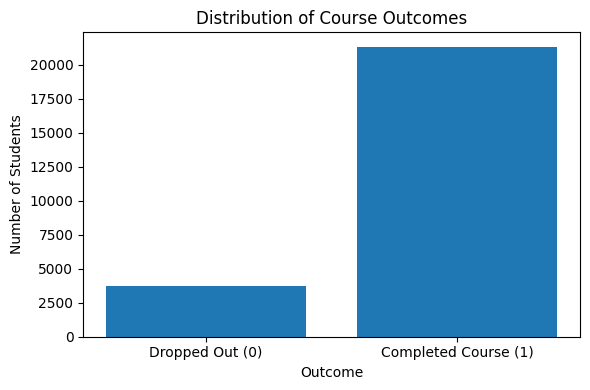

In [ ]:
# Binary encoding of y variable.

study_data_prepped['y'] = study_data_prepped['CompletedCourse'].map({'Yes': 1, 'No': 0})

# Drop the 'CompleteCourse' feature now that y is encoded.

study_data_prepped = study_data_prepped.drop(columns=['CompletedCourse'])

# Test y for imbalance.

imbalance = study_data_prepped['y'].value_counts().to_frame('Count')
imbalance['Proportion'] = study_data_prepped['y'].value_counts(normalize=True)

print(imbalance.round(2),"\n")

# Plot simple bar plot of y binary with labels.

plt.figure(figsize=(6,4))

counts = study_data_prepped['y'].value_counts().sort_index()

labels = ['Dropped Out (0)', 'Completed Course (1)']

bars = plt.bar(labels, counts)

plt.title("Distribution of Course Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

Descriptive Stats: Age

count    25059.00
mean        26.02
std          3.17
min         20.00
25%         24.00
50%         25.00
75%         28.00
max         64.00
Name: Age, dtype: float64 



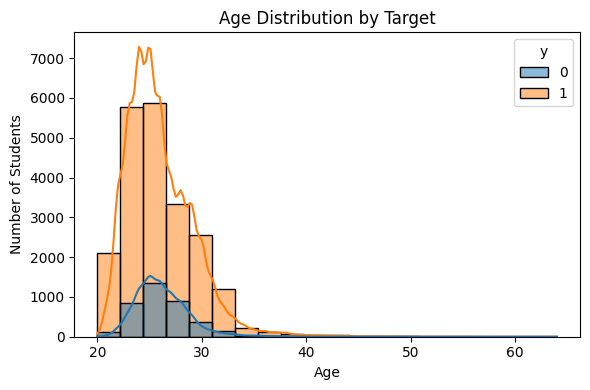

In [ ]:
# Compute summary statistics of Age.

print(study_data_prepped['Age'].describe().round(2),"\n")

# Create a histogram of age vs. course completion.

plt.figure(figsize=(6,4))
sns.histplot(
    data=study_data_prepped,
    x="Age",
    hue="y",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Target")
plt.xlabel("Age")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()

The dataset is heavily concentrated among younger students in their mid-20s, and there is no strong age threshold that clearly differentiates completion from dropout, indicating that age has limited standalone predictive power.

Visualising completion and drop-out rates on different geographical scales:

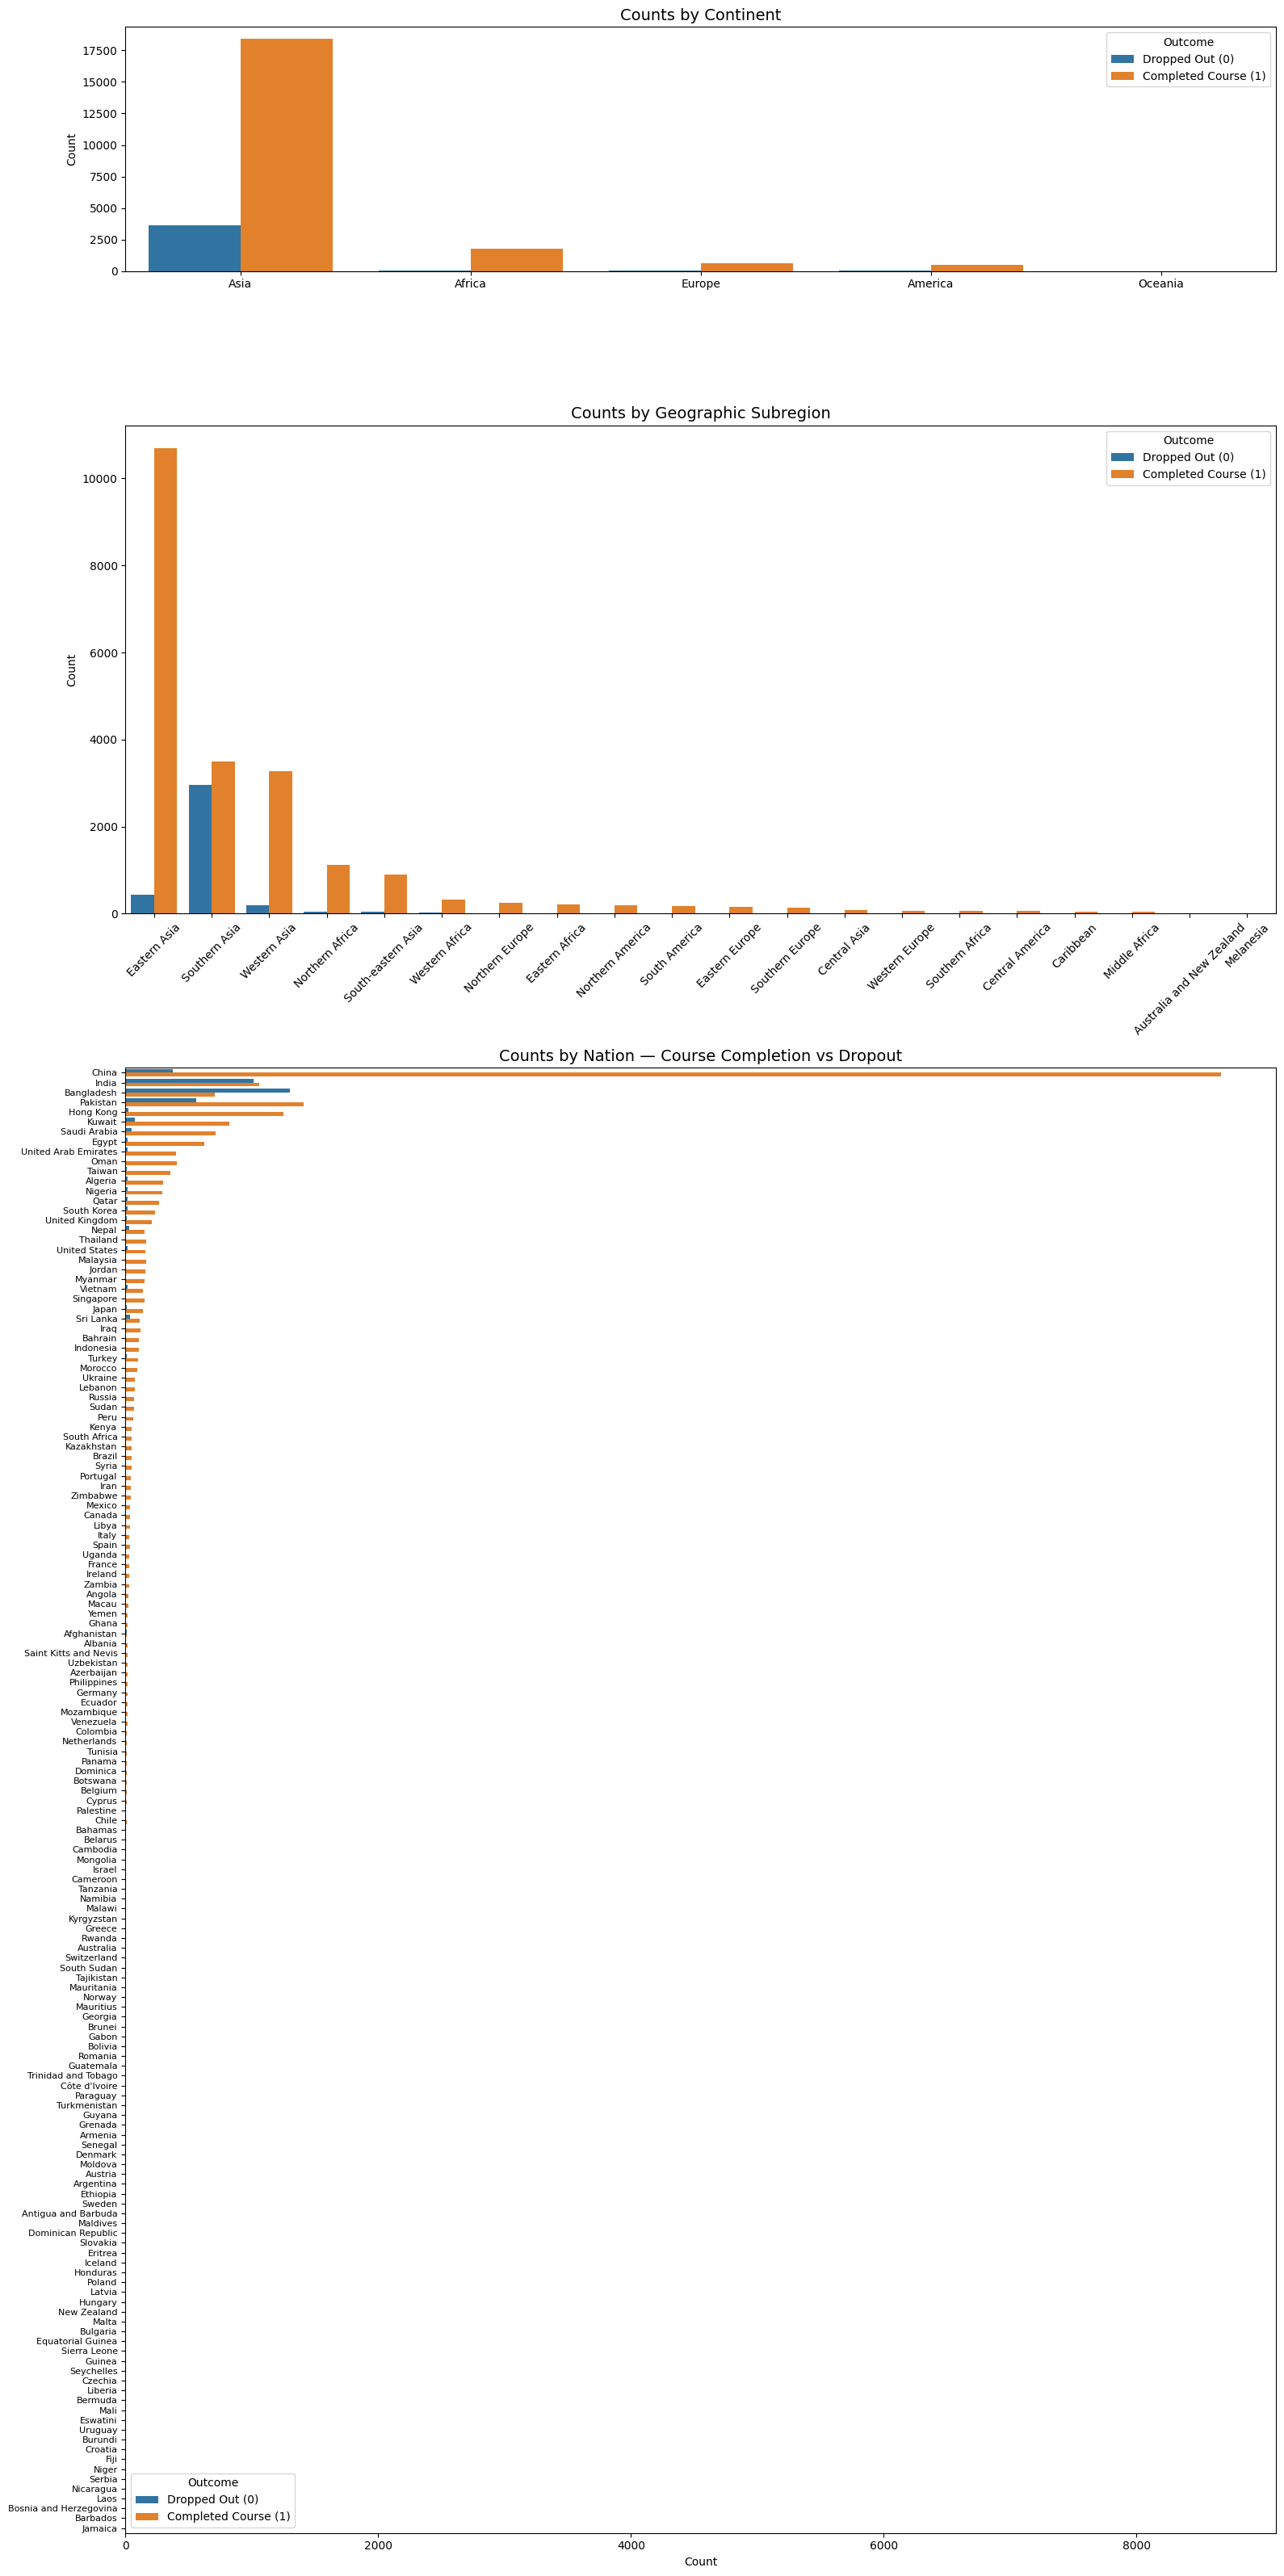

In [ ]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(16, 32),
    gridspec_kw={"height_ratios": [1, 2, 6]}
)

# 1. Continent
sns.countplot(
    data=study_data_prepped,
    x="Continent",
    hue="y",
    order=study_data_prepped["Continent"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Counts by Continent", fontsize=14)
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].legend(title="Outcome", labels=["Dropped Out (0)", "Completed Course (1)"])

# 2. Subregion
sns.countplot(
    data=study_data_prepped,
    x="Subregion",
    hue="y",
    order=study_data_prepped["Subregion"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Counts by Geographic Subregion", fontsize=14)
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Outcome", labels=["Dropped Out (0)", "Completed Course (1)"])

# 3. Nation — horizontal so all labels are visible
sns.countplot(
    data=study_data_prepped,
    y="Nation",
    hue="y",
    order=study_data_prepped["Nation"].value_counts().index,
    ax=axes[2]
)
axes[2].set_title("Counts by Nation — Course Completion vs Dropout", fontsize=14)
axes[2].set_xlabel("Count")
axes[2].set_ylabel("")
axes[2].tick_params(axis="y", labelsize=8)
axes[2].legend(title="Outcome", labels=["Dropped Out (0)", "Completed Course (1)"])

plt.tight_layout()
plt.show()

The geographic subregion variable provides a useful intermediate level of aggregation between continent and nation. It captures meaningful regional variation in course outcomes while avoiding the high cardinality and sparsity associated with modelling at the individual country level.

Summarising completion and drop-out rates by course:

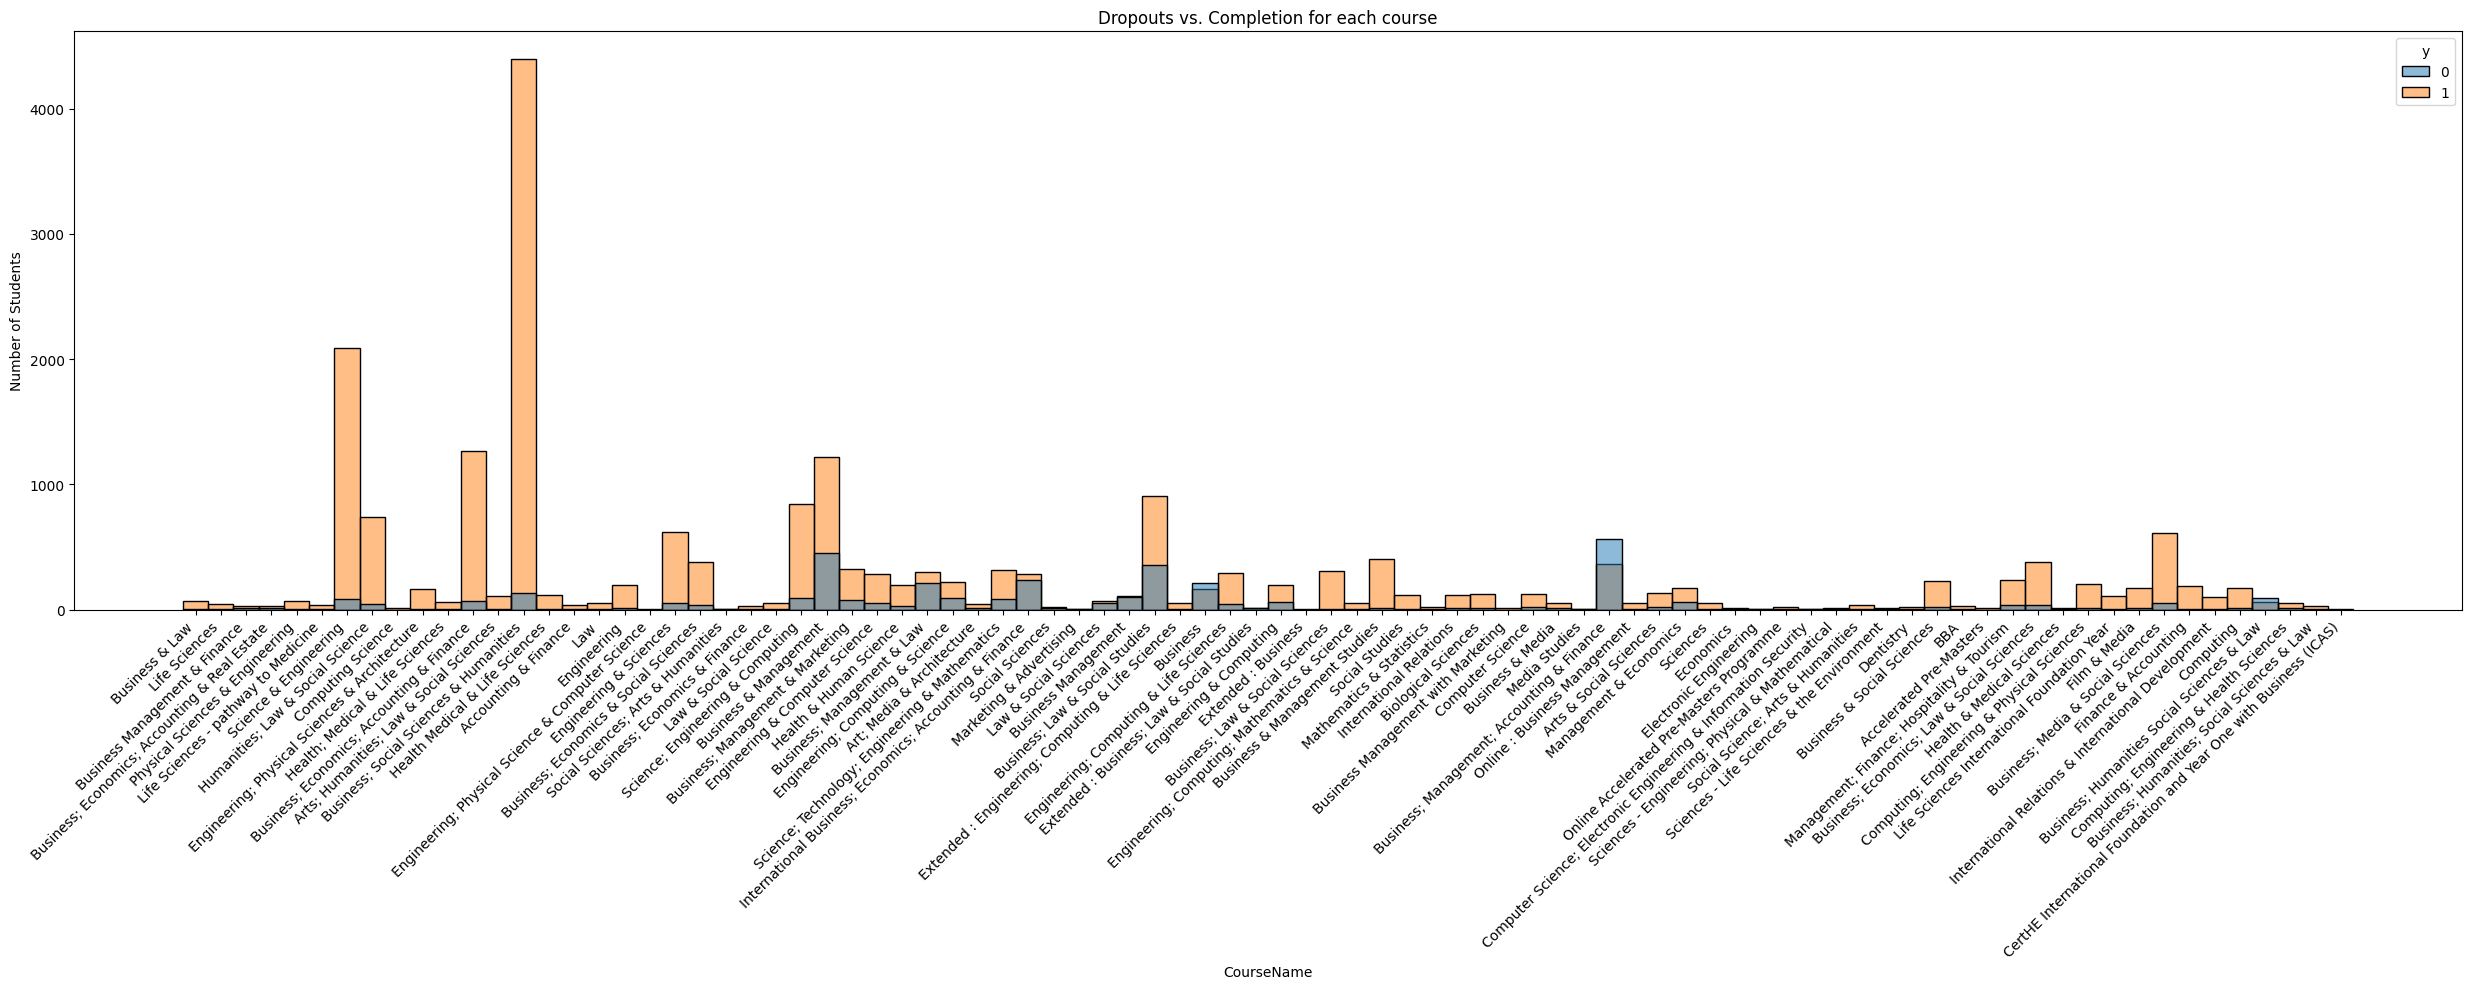

y                                                   Dropout %  Completion %
CourseName                                                                 
CertHE International Foundation and Year One wi...     100.00           NaN
Business; Management; Accounting & Finance              60.97         39.03
Business; Humanities Social Sciences & Law              59.33         40.67
Business                                                56.88         43.12
Extended : Business; Law & Social Studies               51.85         48.15
Business Management                                     48.83         51.17
International Business; Economics; Accounting &...      45.04         54.96
Law & Social Sciences                                   44.54         55.46
Business; Management & Law                              41.05         58.95
Social Sciences; Arts & Humanities                      37.50         62.50
Business; Economics; Accounting & Real Estate           36.36         63.64
Social Scien

In [ ]:
# Bar plot summarising course completion vs. drop-out rates.

plt.figure(figsize=(25, 10))

sns.histplot(
    data=study_data_prepped,
    x="CourseName",
    hue="y"
)

plt.title("Dropouts vs. Completion for each course")

plt.ylabel("Number of Students")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Followed by course rates in % terms.

course_rates = (
    study_data_prepped
    .groupby("CourseName")["y"]
    .value_counts(normalize=True)
    .unstack()
    * 100
)

course_rates = course_rates.rename(columns={
    0: "Dropout %",
    1: "Completion %"
})

with pd.option_context('display.max_rows', None):
    print(course_rates.round(2).sort_values(by='Dropout %', ascending=False))

The visualisation shows that course outcomes vary substantially across programmes, with a small number of courses accounting for the majority of enrolments and completions, while many others have relatively low student counts and more variable dropout rates.

## Pre-processing for model-readiness



In [ ]:
# Drop the continent and nation features from the dataset.

study_for_encoding = study_data_prepped.copy()
study_for_encoding = study_for_encoding.drop(columns=['Continent', 'Nation'])

# Inspect number of unique instances one final time.

for col in study_for_encoding.columns:
  print(f"{col}: {study_for_encoding[col].nunique()}")

CentreName: 19
BookingType: 2
LeadSource: 7
Gender: 2
CourseLevel: 4
IsFirstIntake: 2
Age: 38
Subregion: 20
ProgressionUniversity: 36
CourseName: 86
y: 2


Before splitting data and encoding, I will encode the only ordinal variable: CourseLevel. This can be done before splitting, because it is not a statistic gleaned from the data itself but rather - a rubric applied consistently.

In [ ]:
# Encoding course level.

course_level_map = {
    "Foundation": 0,
    "International Year One": 1,
    "International Year Two": 2,
    "Pre-Masters": 3
}

study_for_encoding["CourseLevel"] = (study_for_encoding["CourseLevel"]
                                             .map(course_level_map))

print(study_for_encoding.head(5))

     CentreName BookingType              LeadSource Gender  CourseLevel  \
0  ISC_Aberdeen       Agent  Standard Agent Booking   Male            3   
1  ISC_Aberdeen       Agent  Standard Agent Booking   Male            0   
2  ISC_Aberdeen       Agent  Standard Agent Booking   Male            2   
3  ISC_Aberdeen       Agent  Standard Agent Booking   Male            2   
4  ISC_Aberdeen       Agent  Standard Agent Booking   Male            3   

   IsFirstIntake  Age     Subregion   ProgressionUniversity  \
0           True   28  Eastern Asia  University of Aberdeen   
1          False   28  Eastern Asia  University of Aberdeen   
2          False   26  Eastern Asia  University of Aberdeen   
3           True   27  Eastern Asia  University of Aberdeen   
4           True   30  Eastern Asia  University of Aberdeen   

                      CourseName  y  
0                 Business & Law  1  
1                  Life Sciences  1  
2  Business Management & Finance  1  
3  Business Manage

Splitting the data:

In [ ]:
# Separate why from the dataframe.

y = study_for_encoding['y']
X = study_for_encoding.drop(columns=['y'])

# Split the original data into train and test sets, with a 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=seed)

# Split the train data further into train and validation sets, with a 90:10 split.
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.1,
                                                  stratify=y_train,
                                                  random_state=seed)

The ColumnTransformer applies appropriate preprocessing to each feature type by scaling continuous variables, one-hot encoding categorical variables and passing ordinal variables through unchanged.

In [ ]:
# Define feature groups.

continuous_cols = ['Age']

categorical_cols = ['CentreName',
                   'BookingType',
                   'LeadSource',
                   'Gender',
                   'IsFirstIntake',
                   'Subregion',
                   'ProgressionUniversity',
                   'CourseName']

ordinal_cols = ['CourseLevel']

# Fit preprocessing on TRAIN only.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("ord", "passthrough", ordinal_cols)
    ],
    remainder="drop"
)

# Fit on training data only.

X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation and test using same fitted preprocessor.

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Recover feature names.

feature_names = preprocessor.get_feature_names_out()

# Convert back to DataFrames for readability.

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_processed = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print(X_train_processed.shape)

(18042, 172)


## XGBoost - Preliminary Instantiation



In [ ]:
# Build a custom function to fit and evaluate XGBoost models.

def fit_evaluate_xgb(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    random_state=seed,
    model_name="XGBoost Baseline Model",
    verbose=False,
    **xgb_kwargs
):
    """
    Fit an XGBoost classifier, print evaluation metrics,
    and return the fitted model along with predictions
    and predicted probabilities.
    """

    model = XGBClassifier(
        random_state=random_state,
        **xgb_kwargs
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        verbose=verbose
    )

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"{model_name} Accuracy:", accuracy_score(y_test, y_pred))
    print(f"{model_name} AUC-ROC:", roc_auc_score(y_test, y_prob),"\n")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["no", "yes"]
    ).plot()

    plt.show()

    return model, y_pred, y_prob

In [ ]:
# Creation a function to plot feature importance.

def plot_xgb_feature_importance(model, X_processed, top_small=10, top_large=50):
    """
    Plot XGBoost feature importance for the top N features.
    """

    feature_importance = pd.Series(
        model.feature_importances_,
        index=X_processed.columns
    ).sort_values()

    # Top 10 plot.
    plt.figure(figsize=(12, 8))
    feature_importance.iloc[-top_small:].plot.barh()
    plt.title(f"Top {top_small} Most Important Features")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    # Top 50 plot.
    plt.figure(figsize=(16, 12))
    feature_importance.iloc[-top_large:].plot.barh()
    plt.title(f"Top {top_large} Most Important Features")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

In [ ]:
# Create a function to save model results.

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "AUC-ROC": roc_auc_score(y_true, y_prob)
    }

xgb_results = []

A baseline XGBoost classifier was trained using the library’s default hyperparameters. Performance metrics from this model serve as a benchmark against which tuned configurations are compared.

XGBoost Baseline Accuracy: 0.888268156424581
XGBoost Baseline AUC-ROC: 0.8674401431745077 

              precision    recall  f1-score   support

           0       0.65      0.56      0.60       751
           1       0.92      0.95      0.94      4261

    accuracy                           0.89      5012
   macro avg       0.79      0.75      0.77      5012
weighted avg       0.88      0.89      0.89      5012



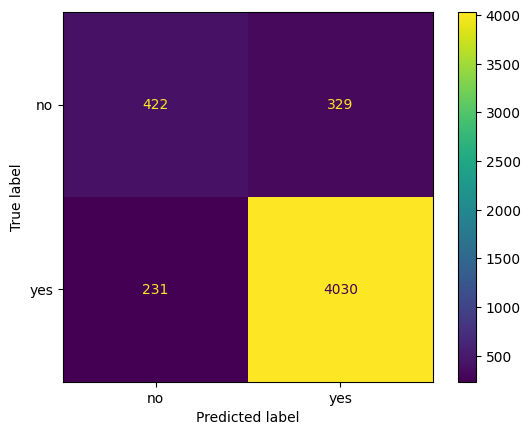

In [ ]:
# Fit baseline model on training data.

xgb_baseline, baseline_preds, baseline_probs = fit_evaluate_xgb(
    X_train=X_train_processed,
    y_train=y_train,
    X_val=X_val_processed,
    y_val=y_val,
    X_test=X_test_processed,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Baseline"
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 1: XGBoost Baseline",
        y_true=y_test,
        y_pred=baseline_preds,
        y_prob=baseline_probs
    )
)

The baseline XGBoost model achieved an accuracy of 0.888 and an AUC-ROC of 0.867, demonstrating strong overall predictive performance. However, the confusion matrix indicates that the model performs substantially better at identifying students who complete the course (recall = 0.95) than those who drop out (recall = 0.56). This imbalance reflects the underlying class distribution in the dataset and highlights the challenge of accurately identifying the minority dropout class.

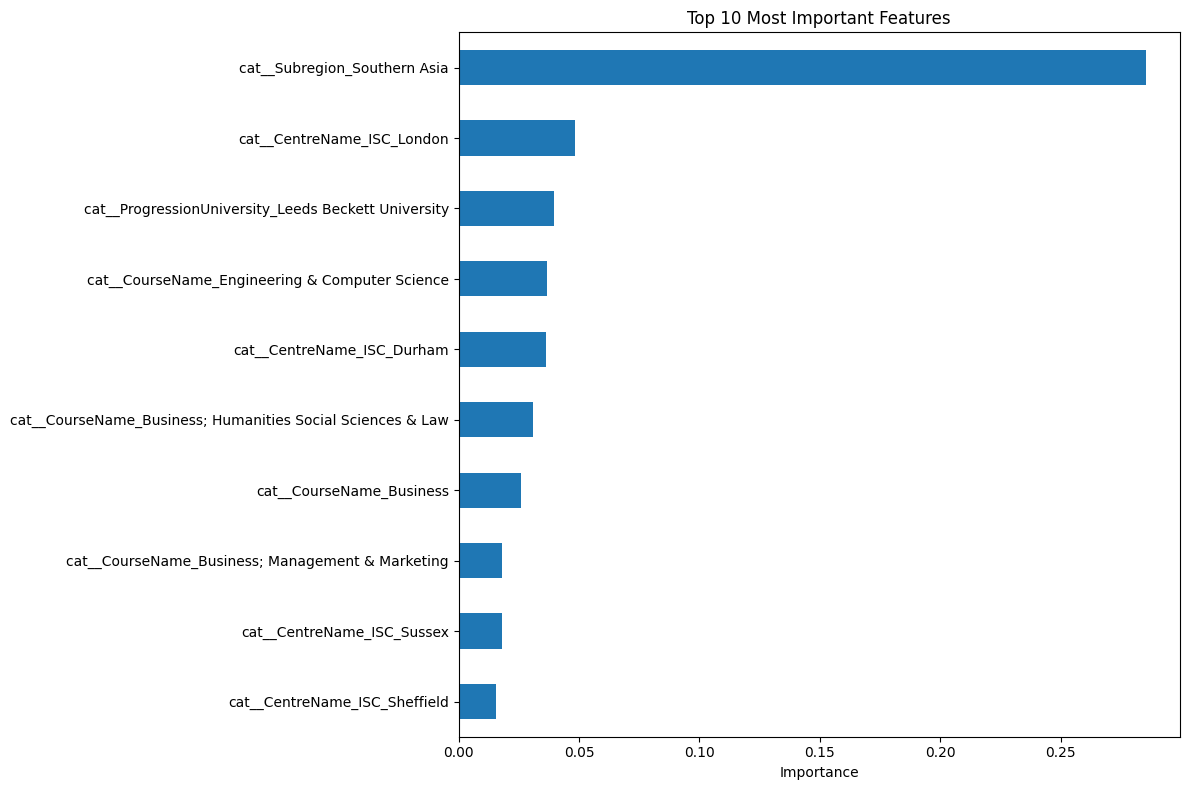

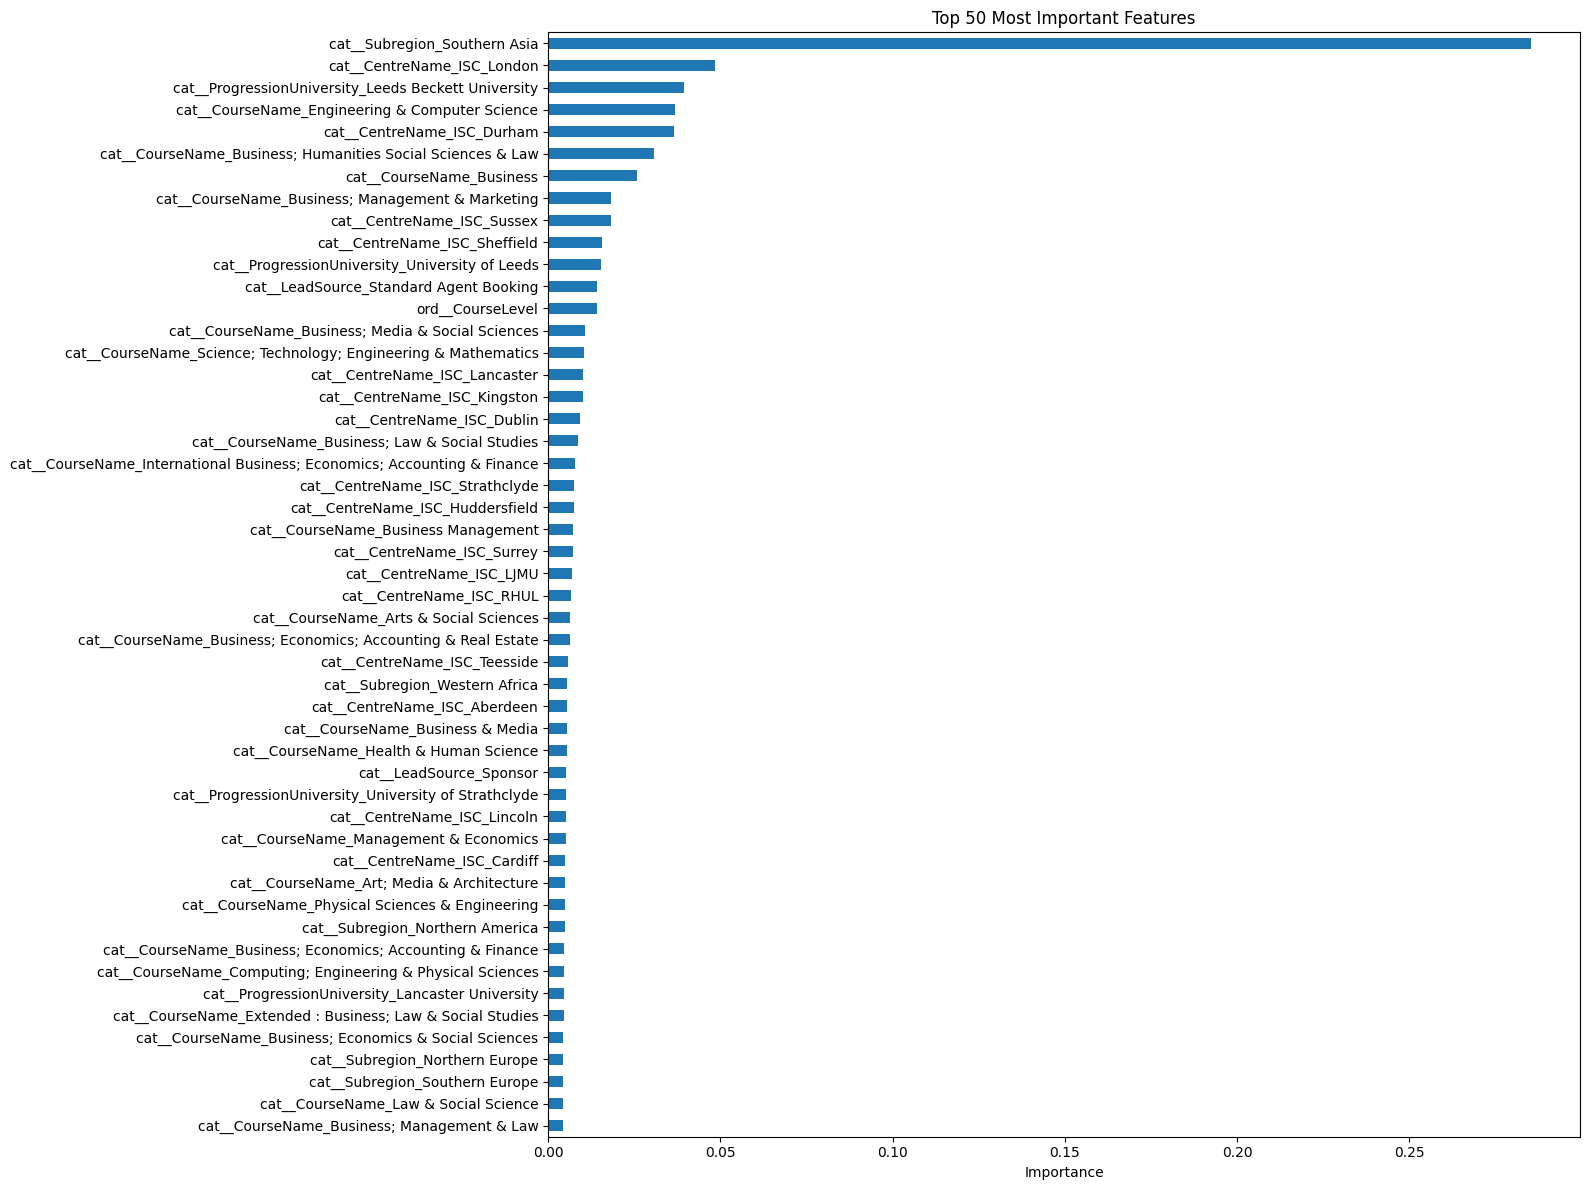

In [ ]:
# Plot feature importance.

plot_xgb_feature_importance(
    model=xgb_baseline,
    X_processed=X_train_processed
)

The feature importance plot indicates that geographic origin, particularly the Southern Asia subregion, is by far the most influential predictor in the XGBoost model, while institutional factors such as study centre location, progression university and course subject area also contribute meaningfully to predicting course completion versus dropout.

## XGBoost - Hyperparameter Tuning



In [ ]:
# Define function to run gridsearch cleanly.

def run_model_gridsearch(
    models_param_grids,
    X_train,
    y_train,
    X_test,
    y_test,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=0
):

    tuning_rows = []
    best_estimators = {}

    for name, config in models_param_grids.items():
        print(f"Tuning: {name}")

        grid = GridSearchCV(
            estimator=config["model"],
            param_grid=config["param_grid"],
            scoring=scoring,
            cv=cv,
            n_jobs=n_jobs,
            verbose=verbose
        )

        # Fit on training data only.
        grid.fit(X_train, y_train)

        best_model = grid.best_estimator_

        # Evaluate on test set.
        probs = best_model.predict_proba(X_test)[:, 1]
        preds = best_model.predict(X_test)

        row = {
            "model": name,
            "best_cv_auc": grid.best_score_,
            "test_auc": roc_auc_score(y_test, probs),
            "test_accuracy": accuracy_score(y_test, preds),
            "best_params": grid.best_params_
        }

        tuning_rows.append(row)
        best_estimators[name] = best_model

    # Create summary results table.
    tuning_results = pd.DataFrame(tuning_rows).sort_values(
        "test_auc", ascending=False
    )

    # Expand best_params into separate columns.
    params_df = tuning_results["best_params"].apply(pd.Series).fillna("Not tuned")

    final_results = pd.concat(
        [tuning_results[["model", "best_cv_auc",
                         "test_auc", "test_accuracy"]],
                         params_df],
        axis=1
    )

    return final_results, best_estimators, tuning_rows

This function runs GridSearchCV for each model configuration in models_param_grids, evaluates the best estimator on the test set and returns a final results DataFrame, a dictionary of best fitted estimators and the raw tuning rows.

In [ ]:
# Set up a parameter grid.

models_param_grids = {
    'XGBoost - 3 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
        }
    },
    'XGBoost - 5 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'gamma': [0, 0.1, 0.3],
        }
    }
}

tuning_rows = []
best_estimators = {}

This code defines two hyperparameter search configurations for the XGBoost model - one tuning three core parameters (n_estimators, learning_rate, max_depth) and another expanding the search to include additional parameters (colsample_bytree, gamma) - which will now
 be used to systematically evaluate different model configurations during hyperparameter optimisation.

In [ ]:
# Perform hyperparameter tuning.

final_results, best_estimators, tuning_rows = run_model_gridsearch(
    models_param_grids=models_param_grids,
    X_train=X_train_processed,
    y_train=y_train,
    X_test=X_test_processed,
    y_test=y_test,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=0
)

print(final_results)

Tuning: XGBoost - 3 hps
Tuning: XGBoost - 5 hps
             model  best_cv_auc  test_auc  test_accuracy colsample_bytree  \
1  XGBoost - 5 hps     0.869083  0.869031       0.884078              1.0   
0  XGBoost - 3 hps     0.869003  0.867719       0.884876        Not tuned   

       gamma  learning_rate  max_depth  n_estimators  
1        0.1            0.1        3.0         200.0  
0  Not tuned            0.1        3.0         200.0  


XGBoost Tuned Accuracy: 0.8840782122905028
XGBoost Tuned AUC-ROC: 0.8690306064572902 

              precision    recall  f1-score   support

           0       0.64      0.51      0.57       751
           1       0.92      0.95      0.93      4261

    accuracy                           0.88      5012
   macro avg       0.78      0.73      0.75      5012
weighted avg       0.88      0.88      0.88      5012



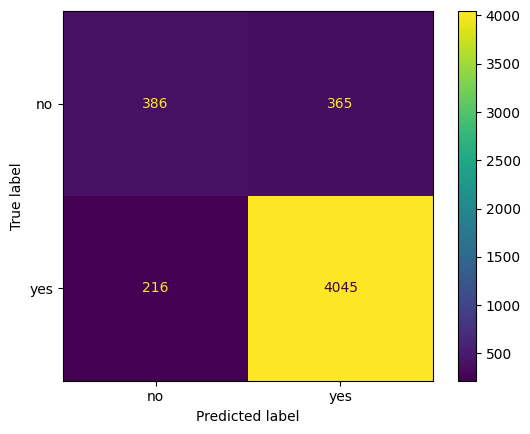

In [ ]:
# Fit tuned model on training data.

xgb_tuned, tuned_preds, tuned_probs = fit_evaluate_xgb(
    X_train=X_train_processed,
    y_train=y_train,
    X_val=X_val_processed,
    y_val=y_val,
    X_test=X_test_processed,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Tuned",

    # Tuned hyperparameters:
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    colsample_bytree=1.0,
    gamma=0.1
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 1: XGBoost Tuned",
        y_true=y_test,
        y_pred=tuned_preds,
        y_prob=tuned_probs
    )
)

The tuned XGBoost model achieved a slightly higher AUC-ROC (0.869 vs. 0.867) compared to the baseline, indicating a marginal improvement in overall ranking performance. However, overall accuracy declined slightly (0.884 vs. 0.888) and the model continued to struggle to correctly identify dropout cases, with recall for class 0 decreasing from 0.56 to 0.51. This suggests that hyperparameter tuning produced only modest performance changes, with the model still affected by the underlying class imbalance in the dataset.

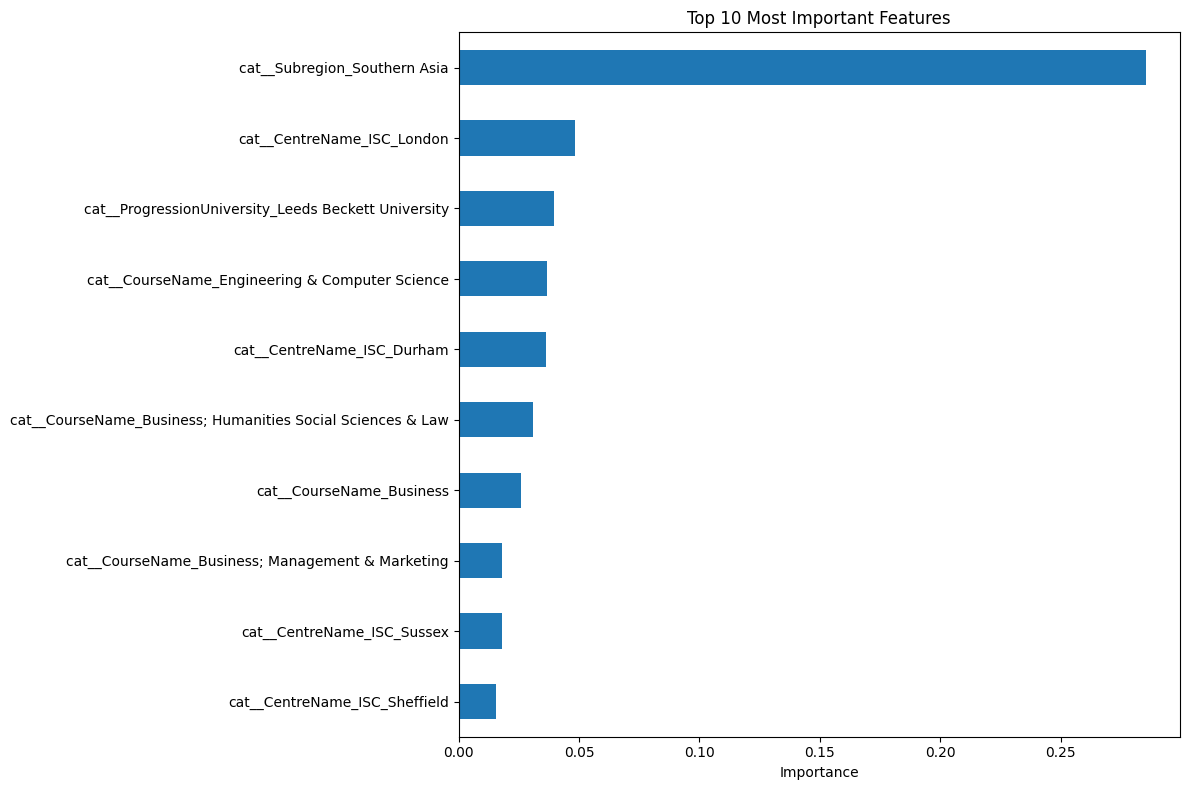

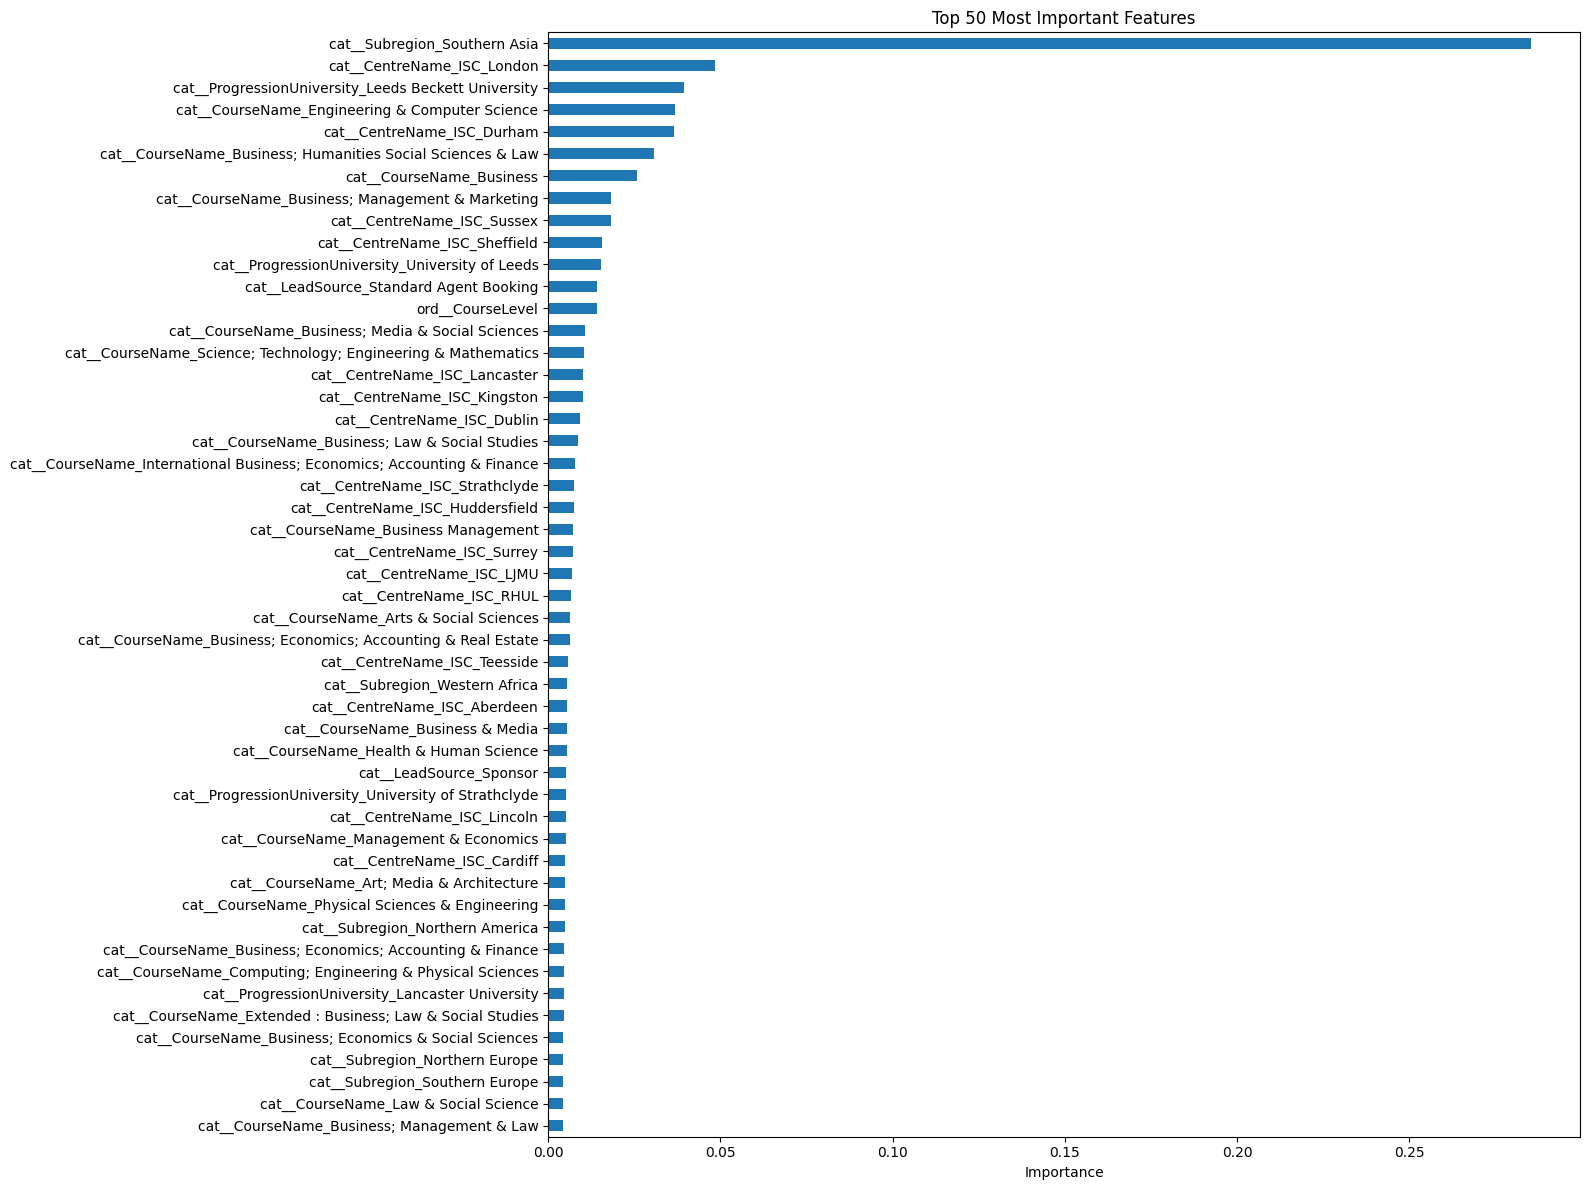

In [ ]:
# Plot feature importance.

plot_xgb_feature_importance(
    model=xgb_baseline,
    X_processed=X_train_processed
)

## Neural Network - Preliminary Instantiation

In order to converse space in this notebook: This function constructs a configurable neural network architecture, trains it on the training set with optional regularisation and early stopping, evaluates performance on the test set and returns the trained model along with predictions, probabilities and training history.

In [ ]:
# Define a custom NN function.

def fit_evaluate_nn(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    hidden_layers=(64, 32, 16),
    hidden_activation="relu",
    output_activation="sigmoid",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.0,
    l2_strength=0.0,
    batch_size=32,
    epochs=8,
    use_early_stopping=False,
    patience=3,
    verbose=1,
    model_name="Neural Network",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
):
    """
    Build, fit, and evaluate a flexible neural network for binary classification.
    Returns the fitted model, training history, test score,
    predictions and probabilities.
    """

    # Configure optimizer
    if isinstance(optimizer, str):
        opt_name = optimizer.lower()
        if opt_name == "adam":
            opt = Adam(learning_rate=learning_rate) if learning_rate\
            is not None else Adam()
        elif opt_name == "rmsprop":
            opt = RMSprop(learning_rate=learning_rate) if learning_rate\
             is not None else RMSprop()
        else:
            raise ValueError("Supported optimizers are 'adam' and 'rmsprop'.")
    else:
        opt = optimizer

    # Build model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    for units in hidden_layers:
        if l2_strength > 0:
            model.add(
                layers.Dense(
                    units,
                    activation=hidden_activation,
                    kernel_regularizer=l2(l2_strength)
                )
            )
        else:
            model.add(
                layers.Dense(
                    units,
                    activation=hidden_activation
                )
            )

        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation=output_activation))

    # Compile model
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Callbacks
    callbacks = []
    if use_early_stopping:
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True
        )
        callbacks.append(early_stop)

    # Fit model
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=verbose
    )

    # Evaluate on test set
    score = model.evaluate(X_test, y_test, verbose=0)

    # Predictions
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype(int)

    # Print core metrics
    if show_metrics:
      print(f"\n{model_name} Test loss: {score[0]:.4f}")
      print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
      print(f"{model_name} AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}","\n")

    if show_classification_report:
        print(classification_report(y_test, y_pred))

    if show_confusion_matrix:
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=["no", "yes"]
        ).plot()
        plt.title(f"{model_name} Confusion Matrix")
        plt.show()

    return model, history, score, y_pred, y_prob

In [ ]:
# Define curve plotting function.

def plot_nn_learning_curves(history, model_name="Neural Network"):
    """
    Plot training and validation accuracy/loss curves from a Keras History object.
    """

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax[0].plot(history.history["accuracy"], label="Train accuracy")
    ax[0].plot(history.history["val_accuracy"], label="Validation accuracy")
    ax[0].set_title(f"{model_name} Accuracy Curve")
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Accuracy")
    ax[0].legend()

    # Loss
    ax[1].plot(history.history["loss"], label="Train loss")
    ax[1].plot(history.history["val_loss"], label="Validation loss")
    ax[1].set_title(f"{model_name} Loss Curve")
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Loss")
    ax[1].legend()

    plt.tight_layout()
    plt.show()


Neural Network Baseline Test loss: 0.2837
Neural Network Baseline Accuracy: 0.8847
Neural Network Baseline AUC-ROC: 0.8732 

              precision    recall  f1-score   support

           0       0.61      0.64      0.63       751
           1       0.94      0.93      0.93      4261

    accuracy                           0.88      5012
   macro avg       0.77      0.79      0.78      5012
weighted avg       0.89      0.88      0.89      5012



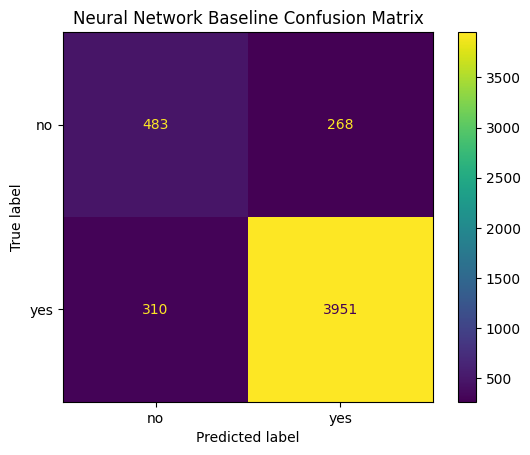

In [ ]:
# Instantiate basic neural network.

nn_baseline, baseline_history, baseline_score,\
 nn_baseline_preds, nn_baseline_probs = fit_evaluate_nn(
    X_train=X_train_processed,
    y_train=y_train,
    X_val=X_val_processed,
    y_val=y_val,
    X_test=X_test_processed,
    y_test=y_test,
    hidden_layers=(64, 32, 16),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,      # default Adam learning rate
    dropout_rate=0.0,        # turned off
    l2_strength=0.0,         # turned off
    batch_size=32,
    epochs=8,
    use_early_stopping=False,
    verbose=0,
    model_name="Neural Network Baseline",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

nn_results = []

nn_results.append(
    evaluate_model(
        model_name="Stage 1: Neural Network - Baseline",
        y_true=y_test,
        y_pred=nn_baseline_preds,
        y_prob=nn_baseline_probs
    )
)

**Neural network on its own:**
> The tuned neural network achieved a test accuracy of 0.885 and an AUC-ROC of 0.873, indicating strong overall predictive performance. The model demonstrated a relatively balanced ability to identify both classes, correctly detecting dropouts with recall = 0.64 and course completions with recall = 0.93. While class imbalance remains present in the dataset, the neural network performs comparatively well at identifying the minority dropout class.

**Comparison with the baseline XGBoost:**

> Compared with the baseline XGBoost model, the tuned neural network achieves slightly lower accuracy (0.885 vs. 0.888) but a higher AUC-ROC (0.873 vs. 0.867), suggesting marginally stronger ranking performance. The neural network also identifies dropout cases more effectively (recall = 0.64 vs. 0.56 for XGBoost), whereas XGBoost performs slightly better at predicting course completions. Overall, both models show strong predictive capability, though the class imbalance continues to make dropout detection more challenging.

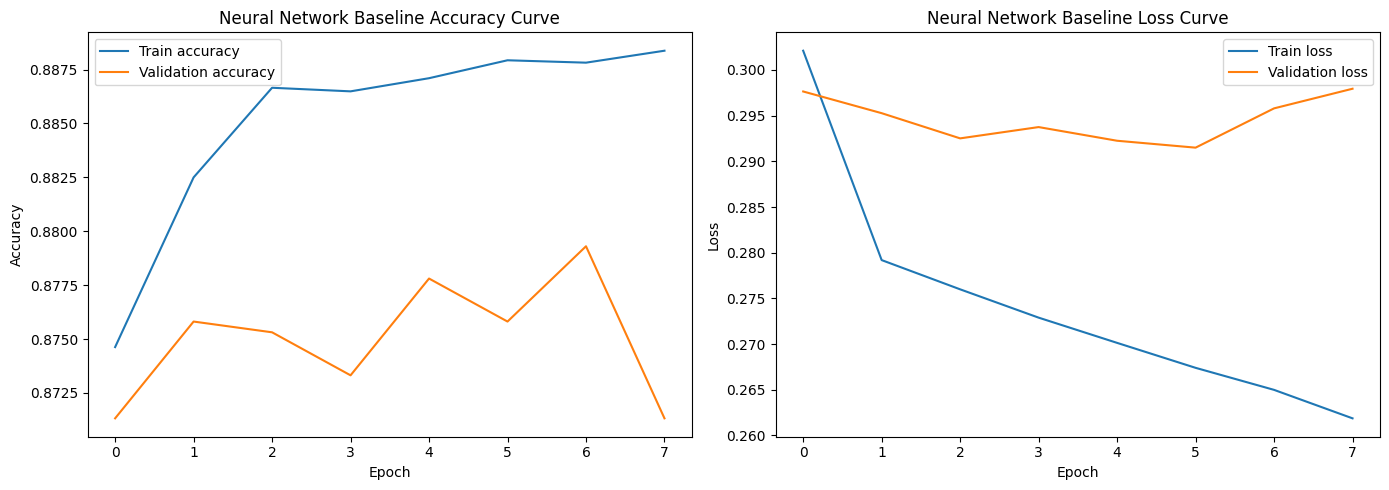

In [ ]:
# Plot accuracy and loss curves.

plot_nn_learning_curves(baseline_history, model_name="Neural Network Baseline")

The learning curves show that the neural network improves rapidly during the first few epochs, with training accuracy increasing and training loss steadily decreasing, indicating that the model is learning meaningful patterns in the data. However, validation accuracy fluctuates and remains slightly below training accuracy, while validation loss stabilises and then begins to rise slightly, suggesting the onset of mild overfitting after the early epochs as the model begins to fit the training data more closely than the validation data.

## Neural Network - Hyperparameter Tuning

In [ ]:
# Specify Stage 1 hyperparameter grid.
nn_param_grid = {
    "neurons": [
        (32, 16, 8),
        (64, 32, 16),
        (128, 64, 32)
    ],
    "optimizer": ["adam", "rmsprop"],
    "hidden_activation": ["relu"],
    "dropout_rate": [0.0, 0.2],
    "l2_strength": [0.0, 0.001]
}

# Run manual hyperparameter search using the NN function.

nn_tuning_results = []
best_nn_models = {}
best_nn_histories = {}

for params in ParameterGrid(nn_param_grid):

    # Create a readable model name.
    model_name = (
        f"NN | neurons={params['neurons']} | "
        f"optimizer={params['optimizer']} | "
        f"activation={params['hidden_activation']} | "
        f"dropout={params['dropout_rate']} | "
        f"l2={params['l2_strength']}"
    )

    model, history, score, test_preds, test_probs = fit_evaluate_nn(
        X_train=X_train_processed,
        y_train=y_train,
        X_val=X_val_processed,
        y_val=y_val,
        X_test=X_test_processed,
        y_test=y_test,
        hidden_layers=params["neurons"],
        hidden_activation=params["hidden_activation"],
        optimizer=params["optimizer"],
        learning_rate=None,                 # use default optimiser learning rate
        dropout_rate=params["dropout_rate"],
        l2_strength=params["l2_strength"],
        batch_size=32,
        epochs=30,
        use_early_stopping=True,
        patience=3,
        verbose=0,
        model_name=model_name,
        show_metrics=False,
        show_classification_report=False,
        show_confusion_matrix=False
    )

    # Validation probabilities for validation AUC.
    val_probs = model.predict(X_val_processed, verbose=0).ravel()

    # Store metrics
    nn_tuning_results.append({
        "Model": model_name,
        "Neurons": params["neurons"],
        "Optimizer": params["optimizer"],
        "Activation": params["hidden_activation"],
        "Dropout": params["dropout_rate"],
        "L2": params["l2_strength"],
        "Epochs Run": len(history.history["loss"]),
        "Best Val AUC": roc_auc_score(y_val, val_probs),
        "Test Accuracy": accuracy_score(y_test, test_preds),
        "Test Precision": precision_score(y_test, test_preds),
        "Test Recall": recall_score(y_test, test_preds),
        "Test F1": f1_score(y_test, test_preds),
        "Test AUC-ROC": roc_auc_score(y_test, test_probs)
    })

    best_nn_models[model_name] = model
    best_nn_histories[model_name] = history

# Create and sort results table.

nn_tuning_results_df = pd.DataFrame(nn_tuning_results).sort_values(
    by="Test AUC-ROC",
    ascending=False
).round(4)

print(nn_tuning_results_df.drop(columns=["Model"]))

          Neurons Optimizer Activation  Dropout     L2  Epochs Run  \
14   (64, 32, 16)      adam       relu      0.2  0.000           7   
22  (128, 64, 32)      adam       relu      0.2  0.001          14   
6     (32, 16, 8)      adam       relu      0.0  0.001          17   
12    (32, 16, 8)      adam       relu      0.2  0.000          15   
20   (64, 32, 16)      adam       relu      0.2  0.001          21   
16  (128, 64, 32)      adam       relu      0.2  0.000           7   
7     (32, 16, 8)   rmsprop       relu      0.0  0.001          10   
8    (64, 32, 16)      adam       relu      0.0  0.001          12   
2    (64, 32, 16)      adam       relu      0.0  0.000           7   
18    (32, 16, 8)      adam       relu      0.2  0.001          20   
5   (128, 64, 32)   rmsprop       relu      0.0  0.000           4   
3    (64, 32, 16)   rmsprop       relu      0.0  0.000           6   
10  (128, 64, 32)      adam       relu      0.0  0.001          14   
1     (32, 16, 8)   

The cross-validation results show that neural network performance was broadly consistent across hyperparameter configurations, with only modest variation in predictive metrics. Test AUC-ROC scores ranged narrowly between ~0.862 and 0.872, while accuracy remained stable around 0.88–0.89, indicating that model performance was relatively insensitive to changes in architecture, optimiser choice, dropout, and L2 regularisation.

The best-performing configuration used three hidden layers (64, 32, 16 neurons) with the Adam optimiser and dropout of 0.2, achieving the highest AUC-ROC of 0.8721 alongside strong precision and recall. Overall, the results suggest that hyperparameter tuning produced only marginal improvements, with most configurations delivering similar predictive performance. This indicates that feature information in the dataset was the primary driver of model accuracy rather than network architecture complexity.


Neural Network (Tuned) Test loss: 0.2920
Neural Network (Tuned) Accuracy: 0.8875
Neural Network (Tuned) AUC-ROC: 0.8708 

              precision    recall  f1-score   support

           0       0.64      0.56      0.60       751
           1       0.92      0.95      0.93      4261

    accuracy                           0.89      5012
   macro avg       0.78      0.75      0.77      5012
weighted avg       0.88      0.89      0.88      5012



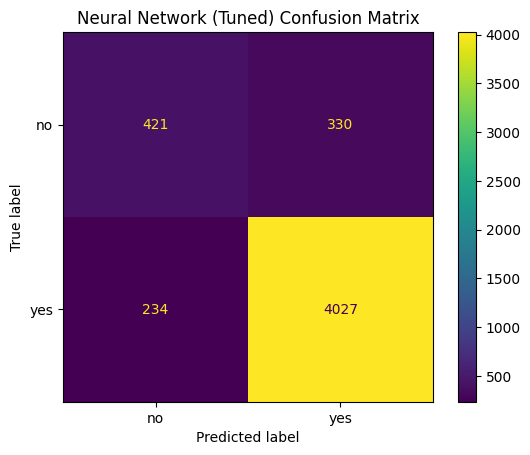

In [ ]:
# Instantiate tuned neural network for detailed review of results.

nn_tuned, tuned_history, tuned_score,\
 nn_tuned_preds, nn_tuned_probs = fit_evaluate_nn(
    X_train=X_train_processed,
    y_train=y_train,
    X_val=X_val_processed,
    y_val=y_val,
    X_test=X_test_processed,
    y_test=y_test,
    hidden_layers=(128, 64, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Tuned)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 1: Neural Network - Tuned",
        y_true=y_test,
        y_pred=nn_tuned_preds,
        y_prob=nn_tuned_probs
    )
)

The tuned neural network performs very similarly to the baseline model, achieving an accuracy of 0.8875 and an AUC-ROC of 0.8708, indicating only marginal changes in overall performance following tuning. While overall accuracy improved slightly, the model continues to perform much better at identifying students who complete the course (recall = 0.95) than those who drop out (recall = 0.56), reflecting the persistent class imbalance in the dataset.

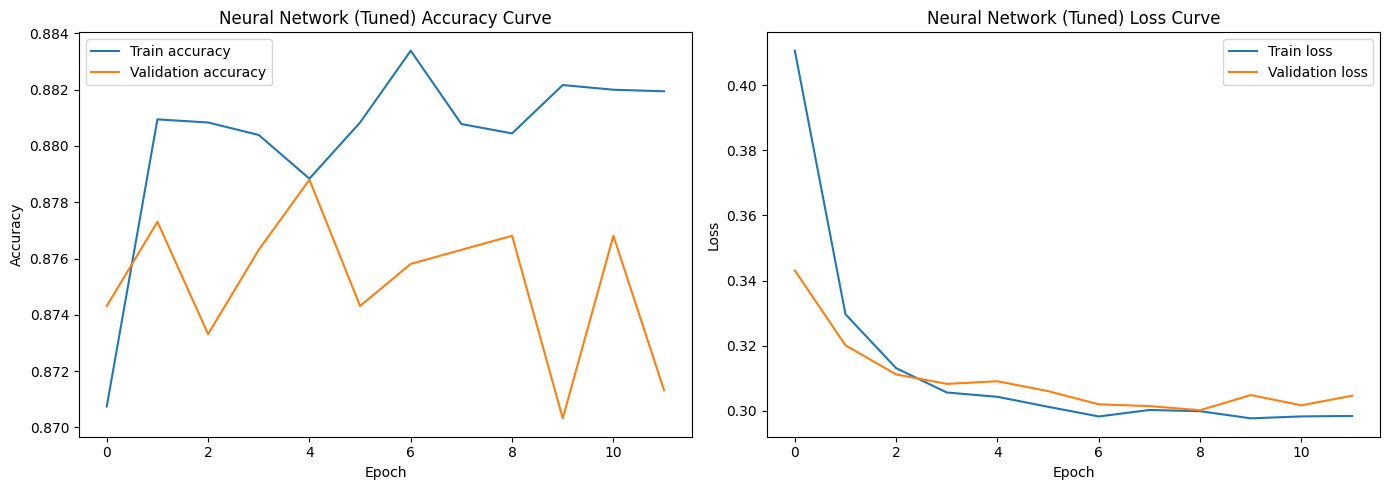

In [ ]:
plot_nn_learning_curves(tuned_history, model_name="Neural Network (Tuned)")


Neural Network (Tuned) Test loss: 0.2955
Neural Network (Tuned) Accuracy: 0.8863
Neural Network (Tuned) AUC-ROC: 0.8676 

              precision    recall  f1-score   support

           0       0.64      0.55      0.59       751
           1       0.92      0.95      0.93      4261

    accuracy                           0.89      5012
   macro avg       0.78      0.75      0.76      5012
weighted avg       0.88      0.89      0.88      5012



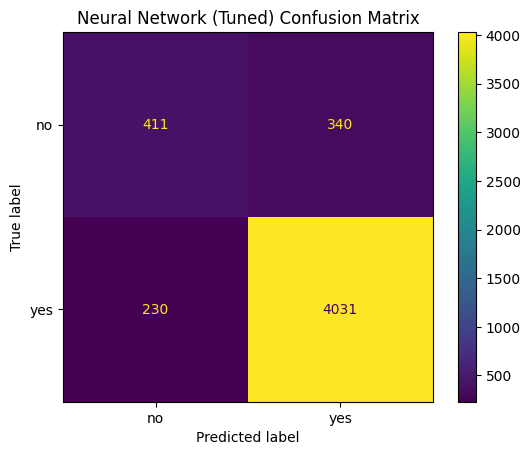

In [ ]:
# Instantiate deeper neural network; review whether this changes output.

nn_deep, deep_history, deep_score,\
 nn_deep_preds, nn_deep_probs = fit_evaluate_nn(
    X_train=X_train_processed,
    y_train=y_train,
    X_val=X_val_processed,
    y_val=y_val,
    X_test=X_test_processed,
    y_test=y_test,
    hidden_layers=(128, 64, 64, 32, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Tuned)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 1: Neural Network - Deep",
        y_true=y_test,
        y_pred=nn_deep_preds,
        y_prob=nn_deep_probs
    )
)

The deep neural network achieved an accuracy of 0.8863 and an AUC-ROC of 0.8676, performing very similarly to both the baseline and tuned neural network models. Increasing model depth did not produce meaningful improvements in predictive performance, with overall accuracy slightly lower and AUC-ROC marginally reduced compared with the tuned configuration. As with the other neural network models, performance remains stronger for predicting course completion (recall = 0.95) than dropout (recall = 0.55), reflecting the underlying class imbalance in the dataset.

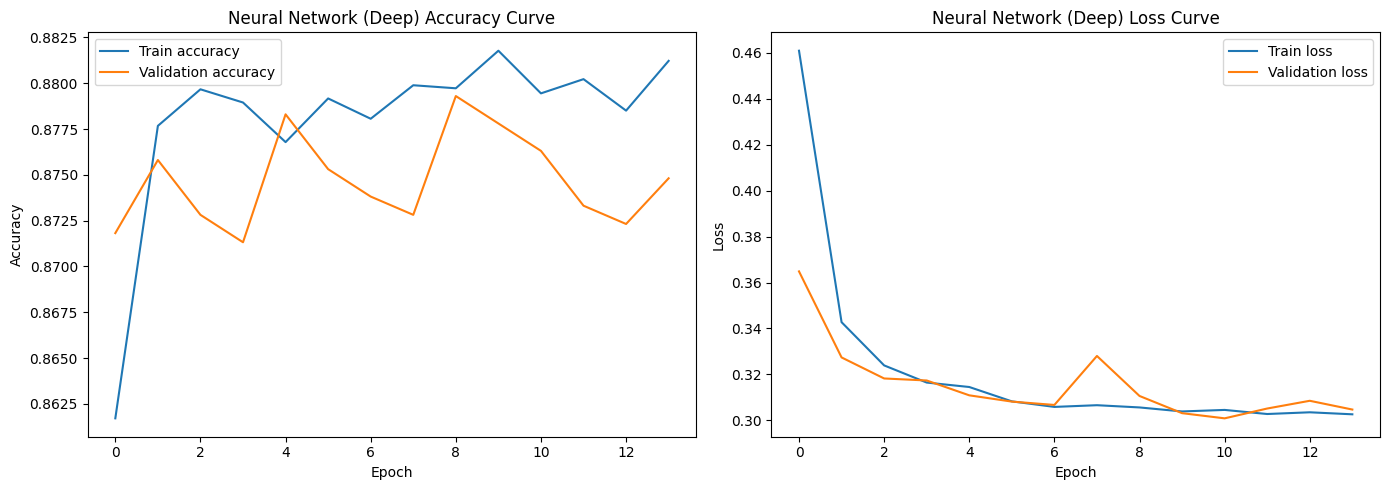

In [ ]:
plot_nn_learning_curves(deep_history, model_name="Neural Network (Deep)")

# Stage 2: Data Import

In [ ]:
# File URL
file_url_2 = "https://drive.google.com/uc?id=1vy1JFQZva3lhMJQV69C43AB1NTM4W-DZ"

study_data_2 = pd.read_csv(file_url_2)

## Data Cleaning

Prior to pre-processing for model-readiness, I will inspect and clean the dataset.

Focus:

- Feature transformation on applicable data
- Dropping rows with missing data (when <2% of the data).

**Stage 2: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.



In [ ]:
# Reconcile stage 2 data with stage 1.

new_columns = []

for col in study_data_2.columns:
    if col not in study_data.columns:
        print(f"{col} not found in study_data.")
        new_columns.append(col)

isolated_columns = study_data_2[new_columns]

# Inspect the data.

print("\n", isolated_columns.head(5))

AuthorisedAbsenceCount not found in study_data.
UnauthorisedAbsenceCount not found in study_data.

    AuthorisedAbsenceCount  UnauthorisedAbsenceCount
0                     NaN                       NaN
1                    93.0                       5.0
2                    92.0                       6.0
3                    67.0                      15.0
4                     NaN                       NaN


Stage 2 dataset contains 2 new datapoints: Authorised Absence Count & Unauthorised Absence Count.

In [ ]:
# Get information on isolation columns.

print(isolated_columns.info())

# Preliminary summary statistics.

print(isolated_columns.describe(),"\n")

# Check for duplicates within the wider dataset.

print(f"Number of duplicate rows: {study_data_2.duplicated().sum()}","\n")

# Create a summary table of missing values.

missing_summary = pd.DataFrame({
    "Missing Count": isolated_columns.isna().sum(),
    "Missing %": (isolated_columns.isna().sum() / len(isolated_columns)) * 100
})

print(missing_summary.round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   AuthorisedAbsenceCount    24851 non-null  float64
 1   UnauthorisedAbsenceCount  24851 non-null  float64
dtypes: float64(2)
memory usage: 391.7 KB
None
       AuthorisedAbsenceCount  UnauthorisedAbsenceCount
count            24851.000000              24851.000000
mean                15.120639                 40.491892
std                 28.918253                 39.029384
min                  0.000000                  0.000000
25%                  0.000000                 12.000000
50%                  1.000000                 29.000000
75%                 15.000000                 56.000000
max                292.000000                343.000000 

Number of duplicate rows: 0 

                          Missing Count  Missing %
AuthorisedAbsenceCount              20

Because the missing values make up for a minimal proportion of the actual dataset; I will assess whether to impute or drop the observations.

## Exploratory Data Analysis (EDA)

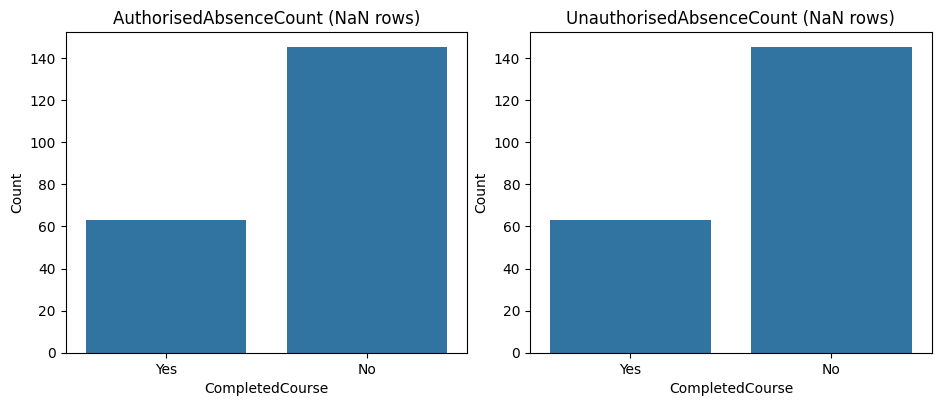

In [ ]:
# Create object that concatenates completedcourse and the isolated columns.

NaN_eval = pd.concat([study_data['CompletedCourse'], isolated_columns], axis=1)

columns_to_check = isolated_columns.columns

# Columns to inspect.

cols = isolated_columns.columns

# Define grid size.

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

# Create subplot grid.

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

# Populate plots.

for i, col in enumerate(cols):
    subset = NaN_eval[NaN_eval[col].isna()]
    sns.countplot(
        data=subset,
        x="CompletedCourse",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} (NaN rows)")
    axes[i].set_xlabel("CompletedCourse")
    axes[i].set_ylabel("Count")

# Remove unused axes if grid > number of columns.

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Tighten layout.

plt.tight_layout(pad=0.5)
plt.show()

Although the missing values show a slight skew toward students who did not complete the course, the overall number of NaN observations is relatively small compared to the full dataset, meaning that removing these rows is unlikely to materially affect class balance or model performance while avoiding the introduction of potentially misleading imputed absence values.

## Pre-processing for model-readiness



As per the instructions, we will remove rows with missing values but in cases where rows with missing values are minimal: <2% of the overall data.

In [ ]:
# Add the new isolated columns.

study_for_encoding_stage_2 = pd.concat([study_for_encoding, isolated_columns], axis=1)

print(f"Before dropping NaN rows: {study_for_encoding_stage_2.shape}")

# Drop columns with NaN values in the new isolated columns.

study_for_encoding_stage_2 = study_for_encoding_stage_2.dropna(subset=new_columns)

print(f"After dropping NaN rows: {study_for_encoding_stage_2.shape}")

# Separate why from the dataframe.

y = study_for_encoding_stage_2['y']
X = study_for_encoding_stage_2.drop(columns=['y'])

Before dropping NaN rows: (25059, 13)
After dropping NaN rows: (24851, 13)


In [ ]:
# Split the original data into train and test sets, with a 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=seed)

# Split the train data further into train and validation sets, with a 90:10 split.
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.1,
                                                  stratify=y_train,
                                                  random_state=seed)

In [ ]:
# Define feature groups.

continuous_cols = ['Age',
                   'AuthorisedAbsenceCount',
                   'UnauthorisedAbsenceCount']

categorical_cols = ['CentreName',
                   'BookingType',
                   'LeadSource',
                   'Gender',
                   'IsFirstIntake',
                   'Subregion',
                   'ProgressionUniversity',
                   'CourseName']

ordinal_cols = ['CourseLevel']

# Fit preprocessing on TRAIN only.

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False),
                              categorical_cols),
        ("ord", "passthrough", ordinal_cols)
    ],
    remainder="drop"
)

# Fit on training data only.

X_train_processed_stage_2 = preprocessor.fit_transform(X_train)

# Transform validation and test using same fitted preprocessor.

X_val_processed_stage_2 = preprocessor.transform(X_val)
X_test_processed_stage_2 = preprocessor.transform(X_test)

# Recover feature names.

feature_names = preprocessor.get_feature_names_out()

# Convert back to DataFrames for readability.

X_train_processed_stage_2 = pd.DataFrame(X_train_processed_stage_2,
                                         columns=feature_names,
                                         index=X_train.index)
X_val_processed_stage_2 = pd.DataFrame(X_val_processed_stage_2,
                                       columns=feature_names,
                                       index=X_val.index)
X_test_processed_stage_2 = pd.DataFrame(X_test_processed_stage_2,
                                        columns=feature_names,
                                        index=X_test.index)

# Ensure encoding has occurred.

print(f"New shape of the encoded data: {X_train_processed_stage_2.shape}")

# Ensure there are no NaN values in the dataset.

print(f"Number of NaN values: {X_train_processed_stage_2.isnull().sum().sum()}")

New shape of the encoded data: (17892, 174)
Number of NaN values: 0


## XGBoost - Preliminary Instantiation



XGBoost Baseline (Stage 2) Accuracy: 0.9102796218064776
XGBoost Baseline (Stage 2) AUC-ROC: 0.917150621720346 

              precision    recall  f1-score   support

           0       0.73      0.61      0.66       722
           1       0.94      0.96      0.95      4249

    accuracy                           0.91      4971
   macro avg       0.83      0.78      0.81      4971
weighted avg       0.91      0.91      0.91      4971



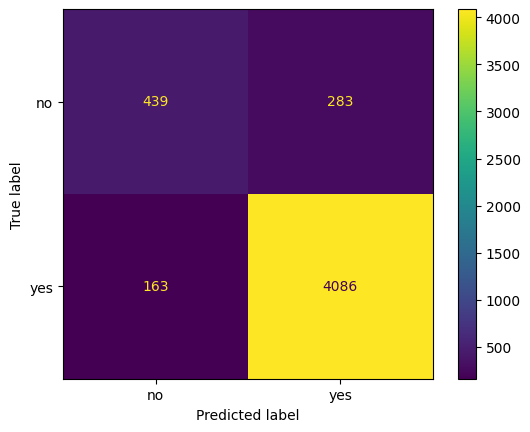

In [ ]:
# Fit Stage 2 baseline model on training data.

xgb_baseline_s2, baseline_preds_s2, baseline_probs_s2 = fit_evaluate_xgb(
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_val=X_val_processed_stage_2,
    y_val=y_val,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Baseline (Stage 2)"
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 2: XGBoost Baseline",
        y_true=y_test,
        y_pred=baseline_preds_s2,
        y_prob=baseline_probs_s2
    )
)


The Stage 2 baseline XGBoost model shows a clear improvement over Stage 1, achieving an accuracy of 0.910 and an AUC-ROC of 0.917. This indicates substantially stronger predictive performance following the inclusion of additional student engagement variables. The model also improves in identifying dropout cases, with recall for class 0 increasing to 0.61, while maintaining very strong performance for predicting course completion (recall = 0.96). Overall, the results suggest that the additional Stage 2 features meaningfully enhance the model’s ability to detect students at risk of dropping out.

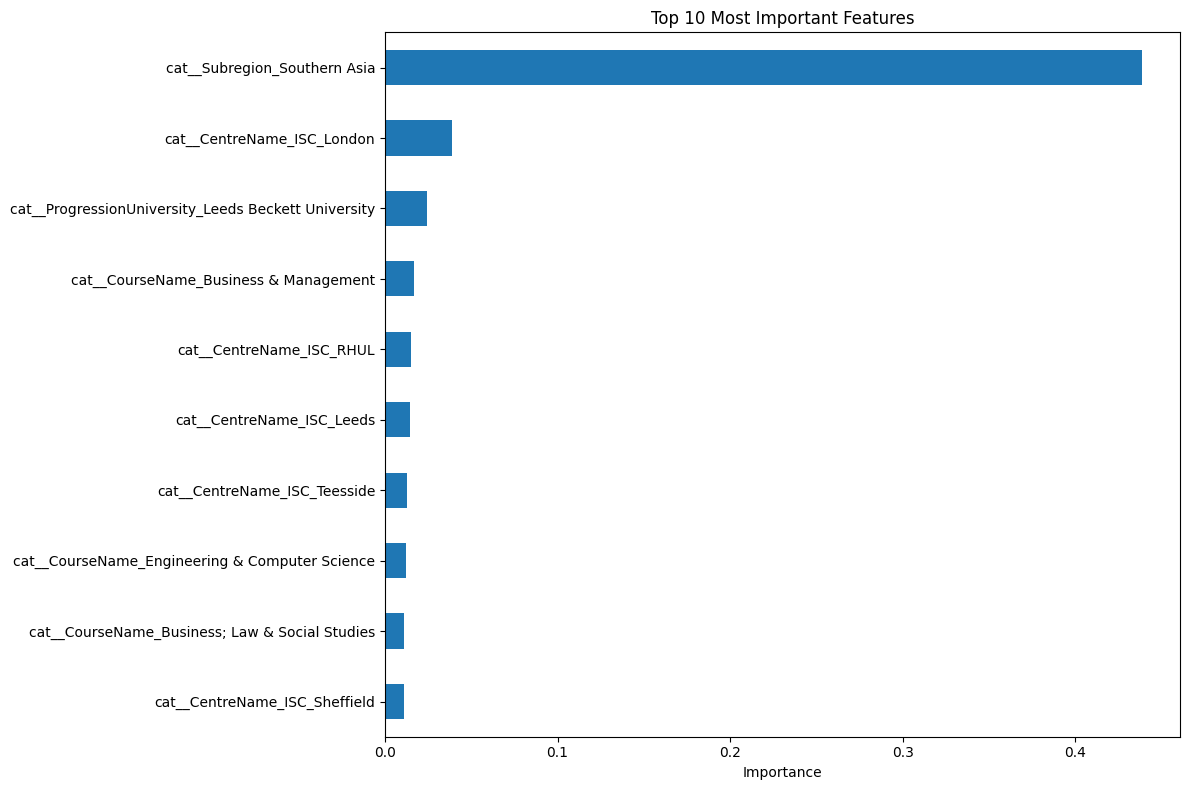

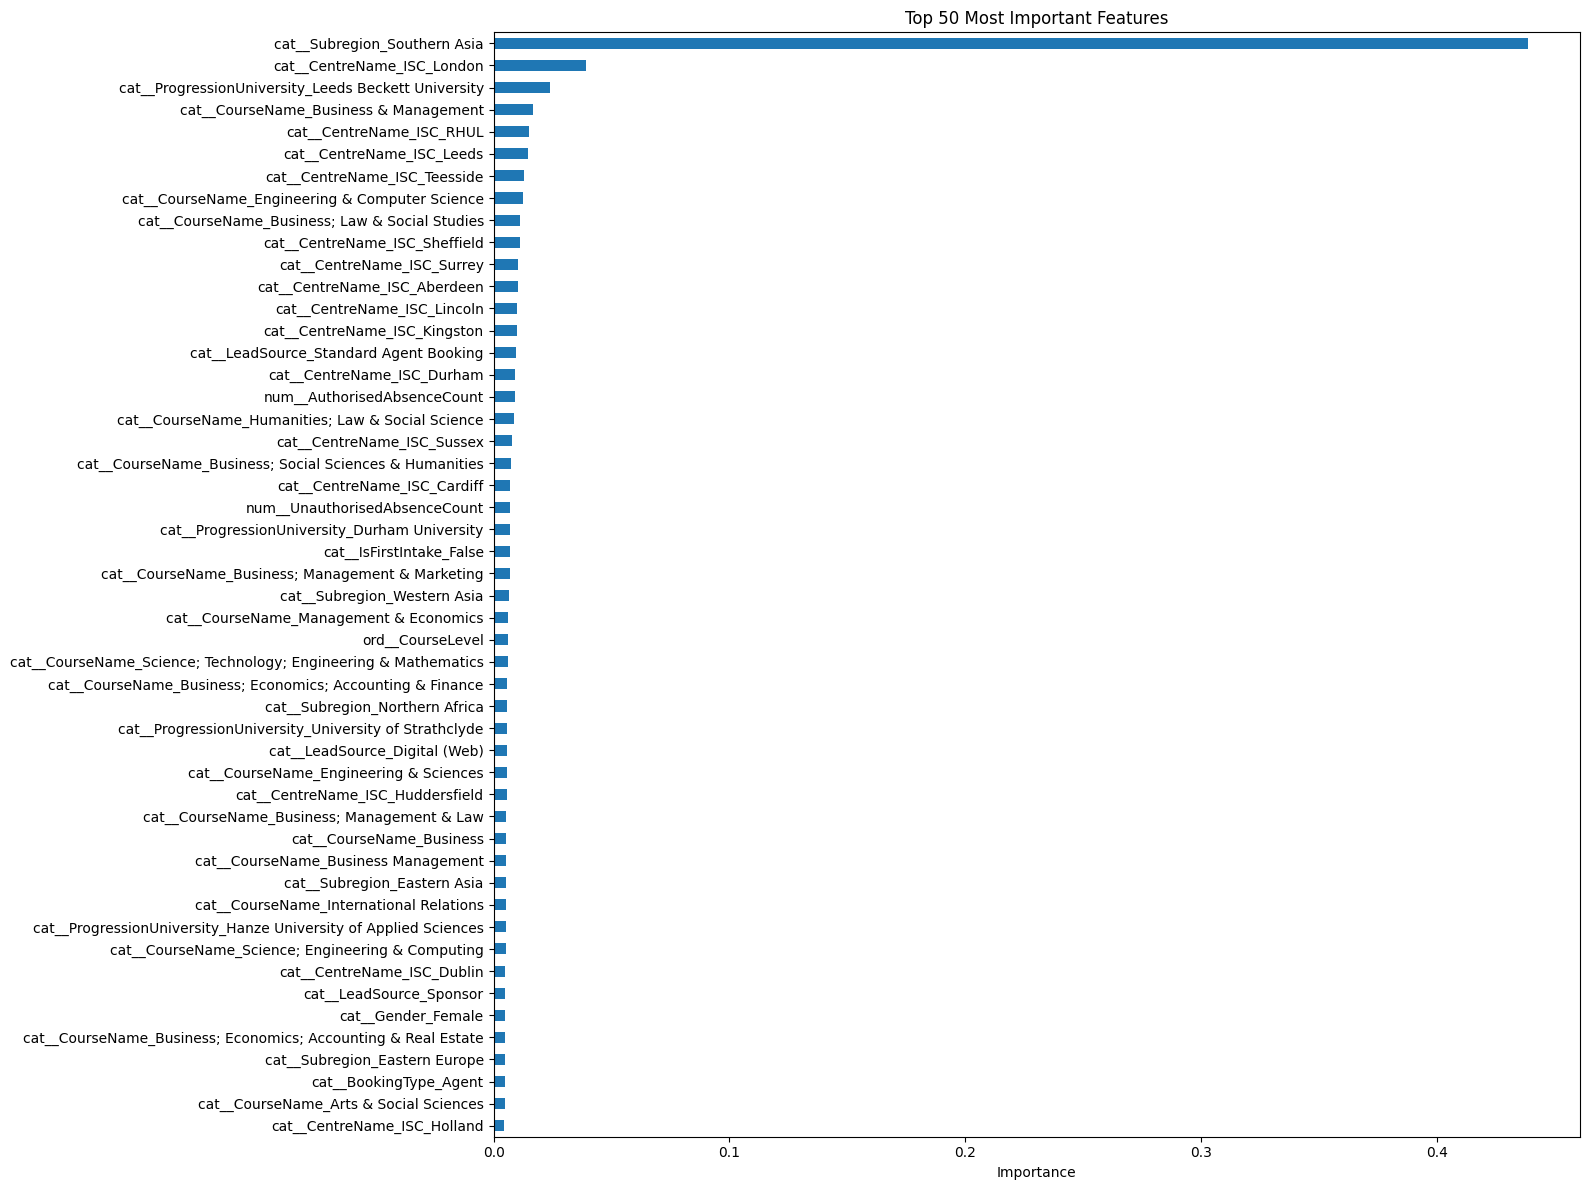

In [ ]:
# Plot feature importance for Stage 2 model.

plot_xgb_feature_importance(
    model=xgb_baseline_s2,
    X_processed=X_train_processed_stage_2
)

Compared with Stage 1, the Stage 2 XGBoost feature importance distribution becomes more balanced, although Subregion: Southern Asia remains the dominant predictor in both models. In Stage 2, additional variables such as centre location and course category features gain noticeably higher importance, indicating that the inclusion of engagement-related variables allows the model to rely less heavily on a single geographic feature and instead draw predictive signal from a broader set of institutional and course-level characteristics.

## XGBoost - Hyperparameter Tuning



In [ ]:
# Set up a Stage 2 parameter grid.

models_param_grids_s2 = {
    'Stage 2: XGBoost - 3 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
        }
    },

    'Stage 2: XGBoost - 5 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'gamma': [0, 0.1, 0.3],
        }
    }
}

# Stage 2 containers for tuning results
tuning_rows_s2 = []
best_estimators_s2 = {}

In [ ]:
# Perform Stage 2 hyperparameter tuning.

final_results_s2, best_estimators_s2, tuning_rows_s2 = run_model_gridsearch(
    models_param_grids=models_param_grids_s2,
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=0
)

print("\n", final_results_s2)

Tuning: Stage 2: XGBoost - 3 hps
Tuning: Stage 2: XGBoost - 5 hps

                       model  best_cv_auc  test_auc  test_accuracy  \
0  Stage 2: XGBoost - 3 hps     0.902833  0.916003       0.908871   
1  Stage 2: XGBoost - 5 hps     0.905040  0.915924       0.910078   

   learning_rate  max_depth  n_estimators colsample_bytree      gamma  
0           0.20        5.0         120.0        Not tuned  Not tuned  
1           0.05        5.0         500.0              0.6        0.3  


Grid search tuning for the Stage 2 XGBoost model produced very similar results across both configurations. The 5-hyperparameter model achieved a slightly higher cross-validation AUC (0.905 vs. 0.903) and marginally improved test accuracy (0.910 vs. 0.909), while the test AUC remained almost identical (0.916 vs. 0.916). Overall, expanding the tuning space from three to five hyperparameters produced only minor performance gains, suggesting that model improvements at this stage were driven more by the underlying features than by additional parameter optimisation.

XGBoost Tuned (Stage 2) Accuracy: 0.9088714544357273
XGBoost Tuned (Stage 2) AUC-ROC: 0.9160027224916536 

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       722
           1       0.94      0.96      0.95      4249

    accuracy                           0.91      4971
   macro avg       0.83      0.78      0.80      4971
weighted avg       0.90      0.91      0.91      4971



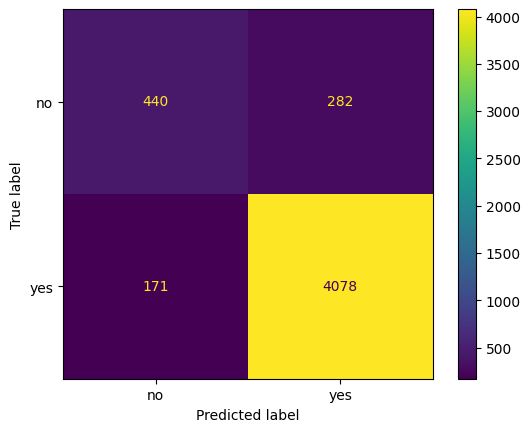

In [ ]:
# Fit Stage 2 tuned model on training data.

xgb_tuned_s2, tuned_preds_s2, tuned_probs_s2 = fit_evaluate_xgb(
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_val=X_val_processed_stage_2,
    y_val=y_val,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Tuned (Stage 2)",

    # Tuned hyperparameters
    n_estimators=120,
    learning_rate=0.2,
    max_depth=5,
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 2: XGBoost Tuned",
        y_true=y_test,
        y_pred=tuned_preds_s2,
        y_prob=tuned_probs_s2
    )
)

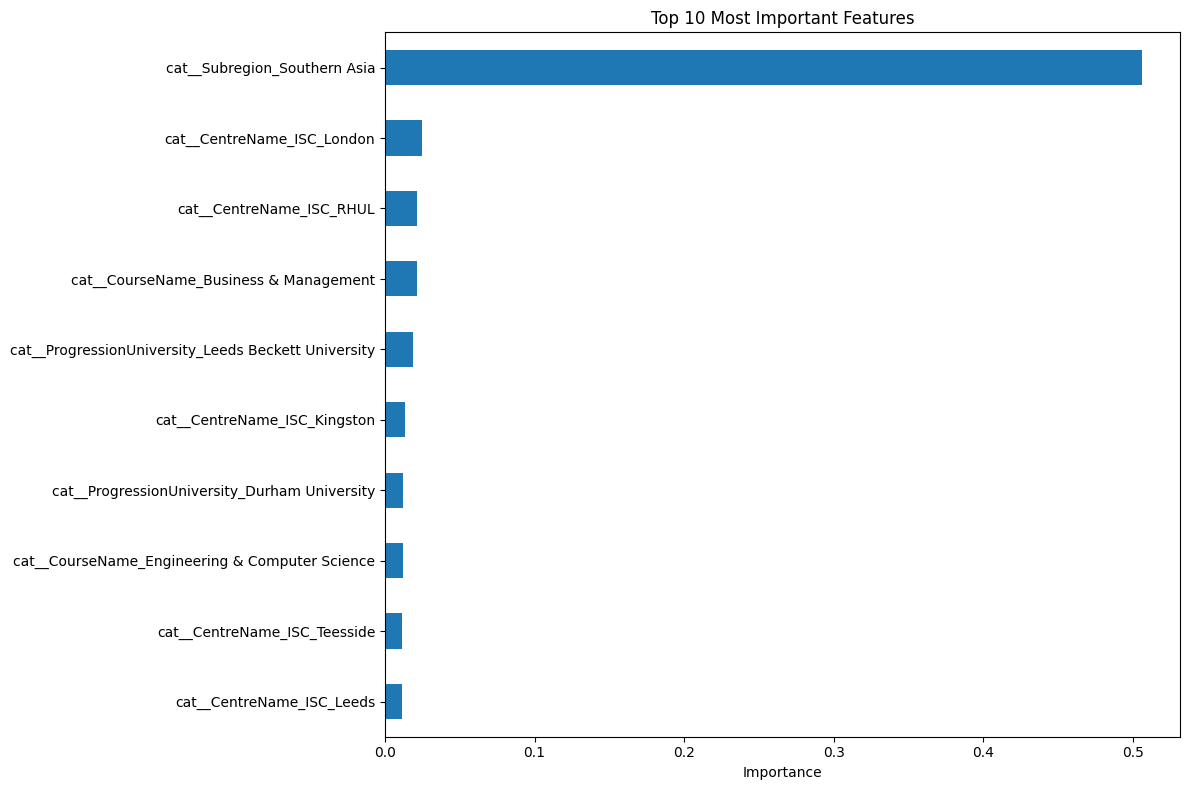

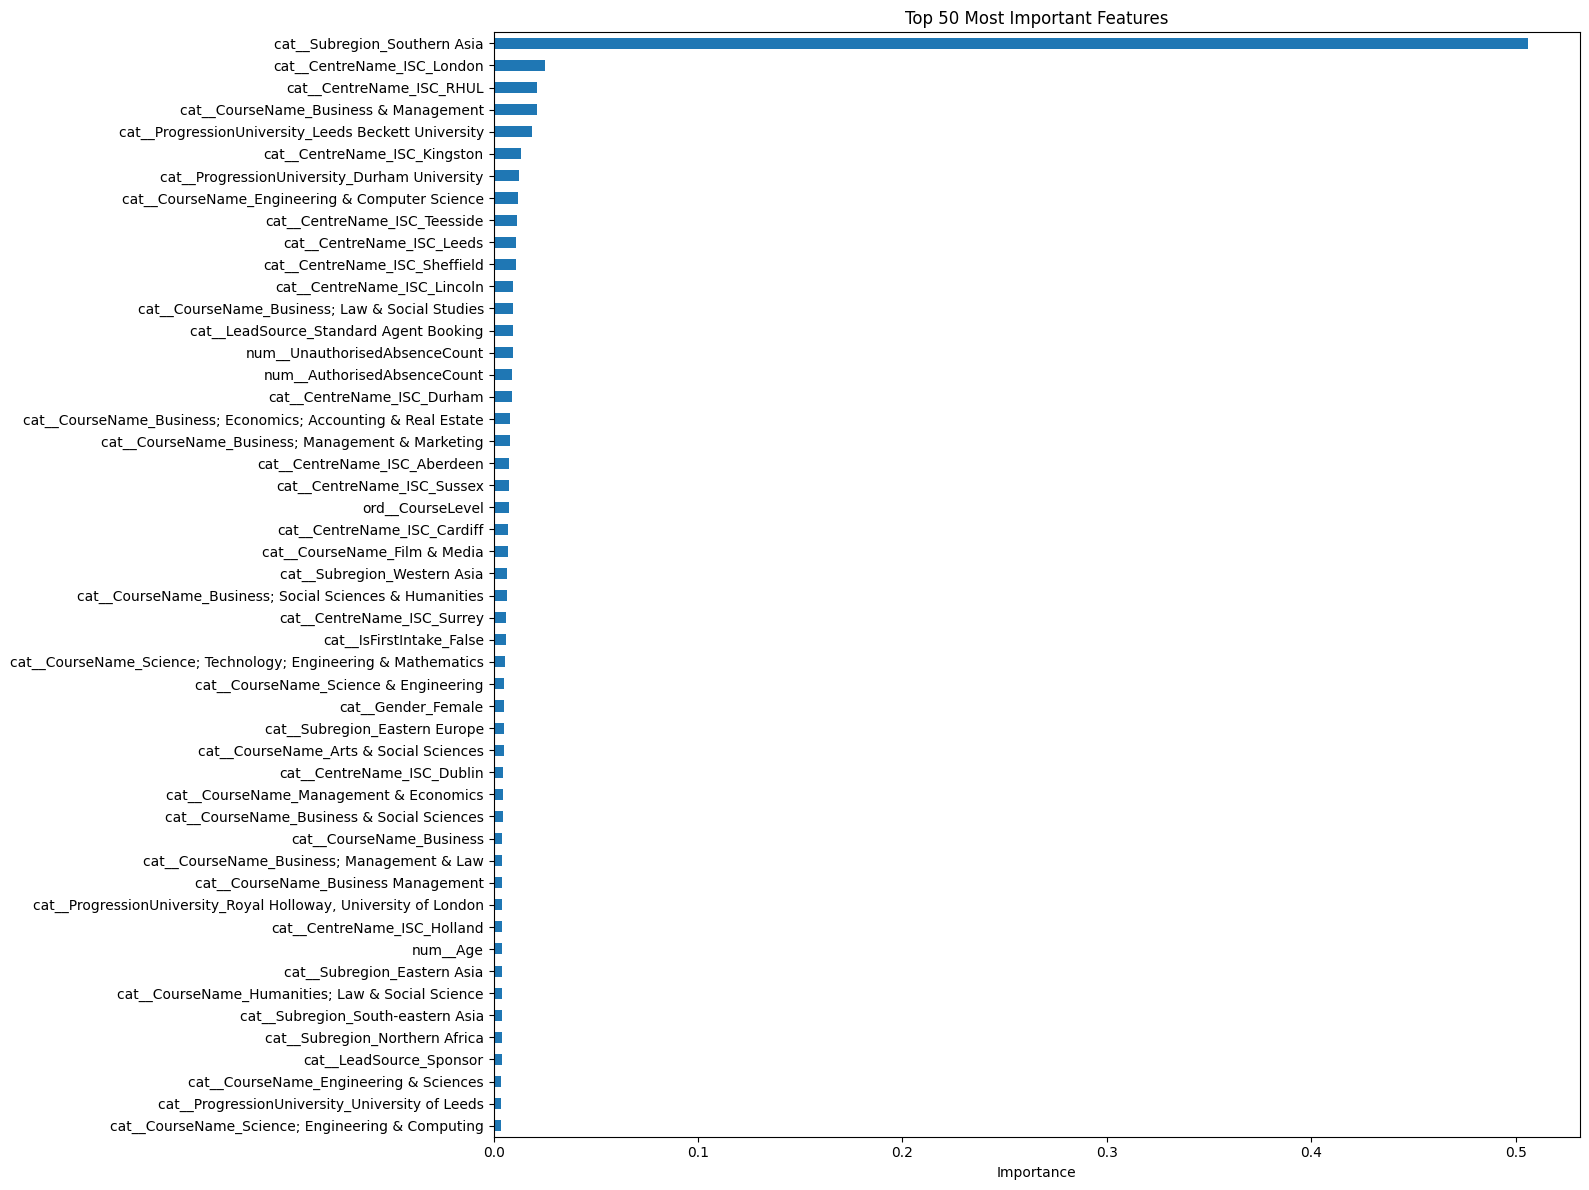

In [ ]:
# Plot Stage 2 feature importance.

plot_xgb_feature_importance(
    model=xgb_tuned_s2,
    X_processed=X_train_processed_stage_2
)

## Neural Network - Preliminary Instantiation


Neural Network Baseline (Stage 2) Test loss: 0.2458
Neural Network Baseline (Stage 2) Accuracy: 0.8994
Neural Network Baseline (Stage 2) AUC-ROC: 0.9067 

              precision    recall  f1-score   support

           0       0.65      0.67      0.66       722
           1       0.94      0.94      0.94      4249

    accuracy                           0.90      4971
   macro avg       0.80      0.80      0.80      4971
weighted avg       0.90      0.90      0.90      4971



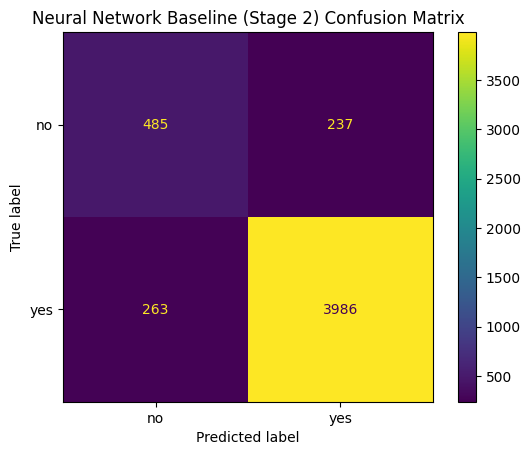

In [ ]:
# Instantiate Stage 2 basic neural network.

nn_baseline_s2, baseline_history_s2, baseline_score_s2, \
nn_baseline_preds_s2, nn_baseline_probs_s2 = fit_evaluate_nn(
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_val=X_val_processed_stage_2,
    y_val=y_val,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    hidden_layers=(64, 32, 16),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,      # default Adam learning rate
    dropout_rate=0.0,        # turned off
    l2_strength=0.0,         # turned off
    batch_size=32,
    epochs=8,
    use_early_stopping=False,
    verbose=0,
    model_name="Neural Network Baseline (Stage 2)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

nn_results.append(
    evaluate_model(
        model_name="Stage 2: Neural Network - Baseline",
        y_true=y_test,
        y_pred=nn_baseline_preds_s2,
        y_prob=nn_baseline_probs_s2
    )
)

The Stage 2 baseline neural network shows a clear improvement over Stage 1, with accuracy increasing from 0.885 to 0.899 and AUC-ROC rising from 0.873 to 0.907, indicating stronger overall predictive performance after the inclusion of additional variables. The model also improves in identifying dropout cases, with recall for class 0 increasing from 0.64 to 0.67, while maintaining strong performance for predicting course completion (recall = 0.94). Overall, the Stage 2 results suggest that the additional features meaningfully enhance the neural network’s ability to distinguish between students who complete their course and those at risk of dropping out.

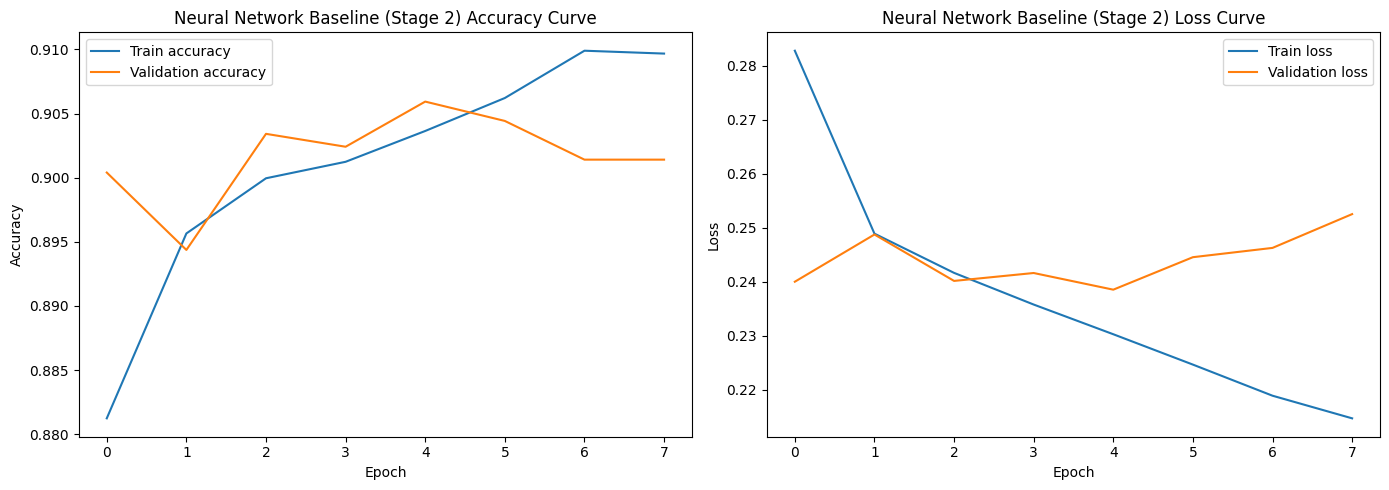

In [ ]:
# Plot Stage 2 accuracy and loss curves.

plot_nn_learning_curves(
    baseline_history_s2,
    model_name="Neural Network Baseline (Stage 2)"
)

## Neural Network - Hyperparameter Tuning

In [ ]:
# Specify Stage 2 hyperparameter grid.

nn_param_grid_s2 = {
    "neurons": [
        (32, 16, 8),
        (64, 32, 16),
        (128, 64, 32)
    ],
    "optimizer": ["adam", "rmsprop"],
    "hidden_activation": ["relu"],
    "dropout_rate": [0.2],
    "l2_strength": [0.001]
}

# Run Stage 2 manual hyperparameter search using the NN function.

nn_tuning_results_s2 = []
best_nn_models_s2 = {}
best_nn_histories_s2 = {}

In [ ]:
for params in ParameterGrid(nn_param_grid_s2):

    # Create a readable model name.
    model_name = (
        f"Stage 2 | NN | neurons={params['neurons']} | "
        f"optimizer={params['optimizer']} | "
        f"activation={params['hidden_activation']} | "
        f"dropout={params['dropout_rate']} | "
        f"l2={params['l2_strength']}"
    )

    model, history, score, test_preds, test_probs = fit_evaluate_nn(
        X_train=X_train_processed_stage_2,
        y_train=y_train,
        X_val=X_val_processed_stage_2,
        y_val=y_val,
        X_test=X_test_processed_stage_2,
        y_test=y_test,
        hidden_layers=params["neurons"],
        hidden_activation=params["hidden_activation"],
        optimizer=params["optimizer"],
        learning_rate=None,                 # use default optimiser learning rate
        dropout_rate=params["dropout_rate"],
        l2_strength=params["l2_strength"],
        batch_size=32,
        epochs=30,
        use_early_stopping=True,
        patience=3,
        verbose=0,
        model_name=model_name,
        show_metrics=False,
        show_classification_report=False,
        show_confusion_matrix=False
    )

    # Validation probabilities for validation AUC.
    val_probs = model.predict(X_val_processed_stage_2, verbose=0).ravel()

    # Store metrics
    nn_tuning_results_s2.append({
        "Model": model_name,
        "Neurons": params["neurons"],
        "Optimizer": params["optimizer"],
        "Activation": params["hidden_activation"],
        "Dropout": params["dropout_rate"],
        "L2": params["l2_strength"],
        "Epochs Run": len(history.history["loss"]),
        "Best Val AUC": roc_auc_score(y_val, val_probs),
        "Test Accuracy": accuracy_score(y_test, test_preds),
        "Test Precision": precision_score(y_test, test_preds),
        "Test Recall": recall_score(y_test, test_preds),
        "Test F1": f1_score(y_test, test_preds),
        "Test AUC-ROC": roc_auc_score(y_test, test_probs)
    })

    best_nn_models_s2[model_name] = model
    best_nn_histories_s2[model_name] = history

# Create and sort Stage 2 results table.

nn_tuning_results_df_s2 = pd.DataFrame(nn_tuning_results_s2).sort_values(
    by="Test AUC-ROC",
    ascending=False
).round(4)

print(nn_tuning_results_df_s2.drop(columns=["Model"]))

         Neurons Optimizer Activation  Dropout     L2  Epochs Run  \
2   (64, 32, 16)      adam       relu      0.2  0.001          12   
4  (128, 64, 32)      adam       relu      0.2  0.001          10   
0    (32, 16, 8)      adam       relu      0.2  0.001          20   
1    (32, 16, 8)   rmsprop       relu      0.2  0.001          20   
5  (128, 64, 32)   rmsprop       relu      0.2  0.001          11   
3   (64, 32, 16)   rmsprop       relu      0.2  0.001          19   

   Best Val AUC  Test Accuracy  Test Precision  Test Recall  Test F1  \
2        0.9127         0.8976          0.9410       0.9390   0.9400   
4        0.9110         0.8996          0.9344       0.9492   0.9417   
0        0.9115         0.9020          0.9352       0.9513   0.9432   
1        0.9091         0.9028          0.9341       0.9536   0.9438   
5        0.9091         0.8992          0.9399       0.9423   0.9411   
3        0.9098         0.8970          0.9318       0.9489   0.9403   

   Test AUC

The neural network parameter tests produced very similar results across all configurations, indicating that model performance was relatively stable regardless of architecture or optimiser choice. Test accuracy ranged narrowly between 0.897 and 0.903, while AUC-ROC varied only slightly between 0.902 and 0.908. The best-performing configuration used three hidden layers (64, 32, 16) with the Adam optimiser, achieving the highest AUC-ROC of 0.9076, although several alternative configurations produced nearly identical results. Overall, the findings suggest that changes in network size or optimiser produced only marginal performance differences, reinforcing that the additional Stage 2 features were the primary driver of improved predictive performance.


Neural Network (Tuned, Stage 2) Test loss: 0.2554
Neural Network (Tuned, Stage 2) Accuracy: 0.9002
Neural Network (Tuned, Stage 2) AUC-ROC: 0.9108 

              precision    recall  f1-score   support

           0       0.66      0.63      0.65       722
           1       0.94      0.95      0.94      4249

    accuracy                           0.90      4971
   macro avg       0.80      0.79      0.80      4971
weighted avg       0.90      0.90      0.90      4971



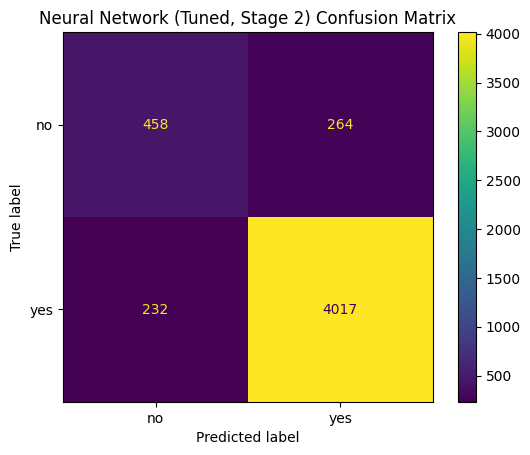

In [ ]:
# Instantiate tuned Stage 2 neural network for detailed review of results.

nn_tuned_s2, tuned_history_s2, tuned_score_s2, \
nn_tuned_preds_s2, nn_tuned_probs_s2 = fit_evaluate_nn(
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_val=X_val_processed_stage_2,
    y_val=y_val,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    hidden_layers=(128, 64, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Tuned, Stage 2)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 2: Neural Network - Tuned",
        y_true=y_test,
        y_pred=nn_tuned_preds_s2,
        y_prob=nn_tuned_probs_s2
    )
)

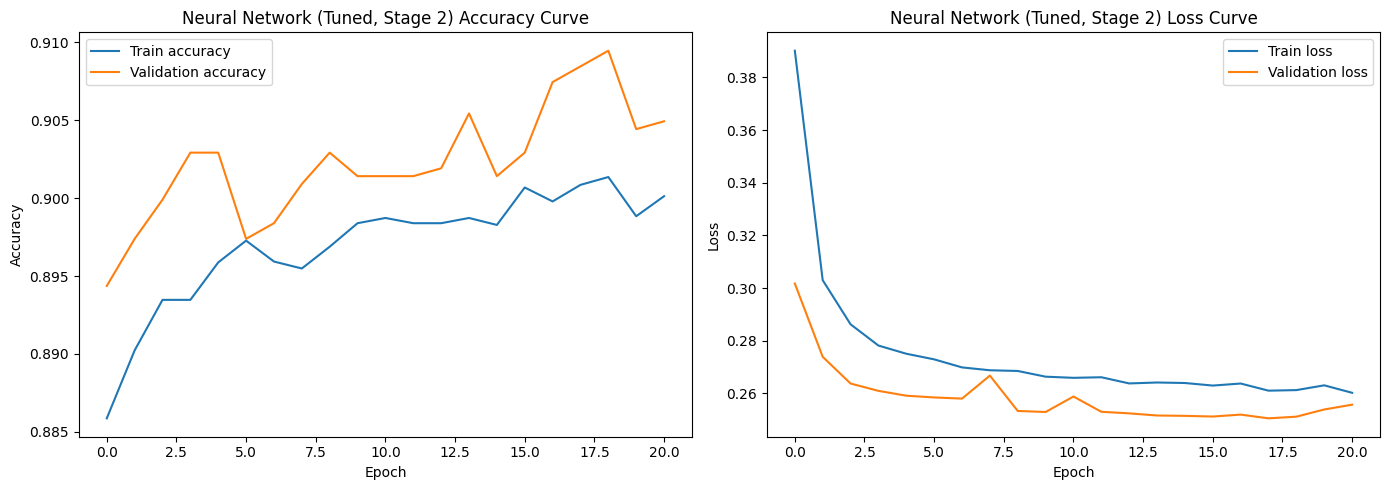

In [ ]:
# Plot learning curves.

plot_nn_learning_curves(
    tuned_history_s2,
    model_name="Neural Network (Tuned, Stage 2)"
)


Neural Network (Tuned, Stage 2) Test loss: 0.2633
Neural Network (Tuned, Stage 2) Accuracy: 0.8984
Neural Network (Tuned, Stage 2) AUC-ROC: 0.9083 

              precision    recall  f1-score   support

           0       0.64      0.70      0.67       722
           1       0.95      0.93      0.94      4249

    accuracy                           0.90      4971
   macro avg       0.79      0.81      0.80      4971
weighted avg       0.90      0.90      0.90      4971



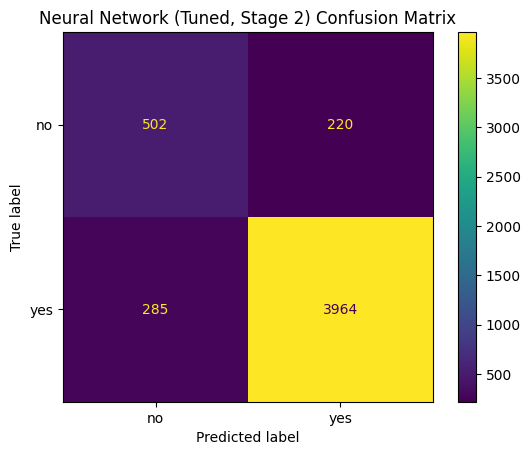

In [ ]:
# Instantiate deep Stage 2 neural network for detailed review of results.

nn_deep_s2, deep_history_s2, deep_score_s2, \
nn_deep_preds_s2, nn_deep_probs_s2 = fit_evaluate_nn(
    X_train=X_train_processed_stage_2,
    y_train=y_train,
    X_val=X_val_processed_stage_2,
    y_val=y_val,
    X_test=X_test_processed_stage_2,
    y_test=y_test,
    hidden_layers=(128, 64, 64, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Deep, Stage 2)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 2: Neural Network - Deep",
        y_true=y_test,
        y_pred=nn_deep_preds_s2,
        y_prob=nn_deep_probs_s2
    )
)

The tuned deep neural network for Stage 2 achieved an accuracy of 0.898 and an AUC-ROC of 0.908, performing very similarly to the baseline model but with a slight improvement in overall ranking performance. The model also shows a stronger ability to identify dropout cases, with recall for class 0 increasing to 0.70, while maintaining high performance for predicting course completion (recall = 0.93). Overall, the deeper architecture produced modest gains in identifying at-risk students without materially changing overall predictive performance.

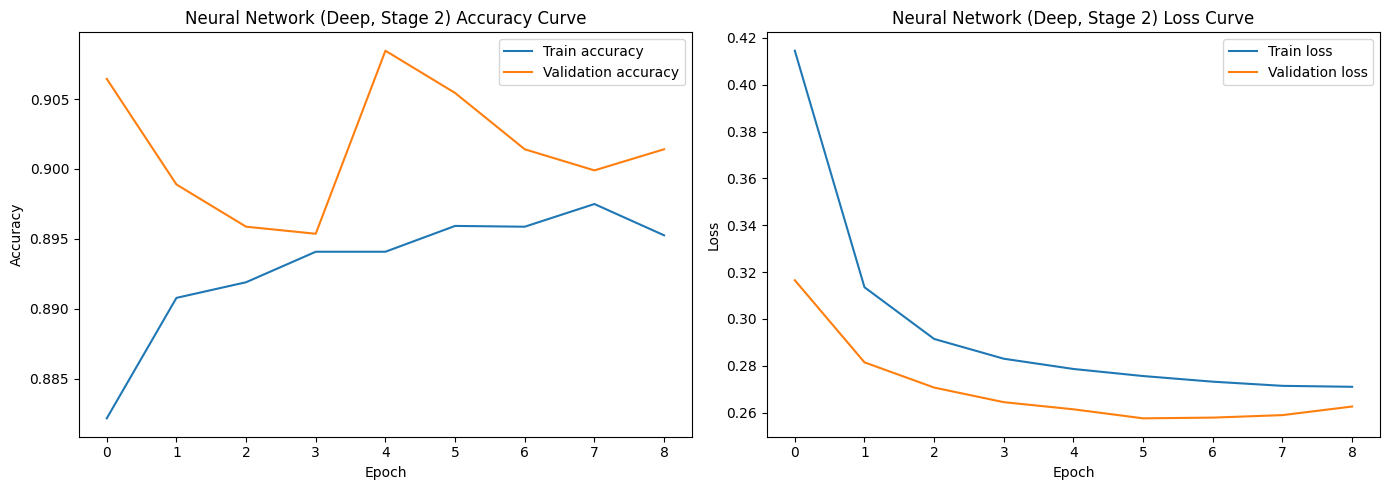

In [ ]:
# Plot learning curves.

plot_nn_learning_curves(
    deep_history_s2,
    model_name="Neural Network (Deep, Stage 2)"
)

The learning curves show stable training behaviour, with training accuracy gradually increasing while training loss steadily declines, indicating that the model is learning useful patterns in the data. Validation accuracy remains slightly higher than training accuracy and validation loss decreases before stabilising, suggesting good generalisation with no clear signs of significant overfitting during training.

# Stage 3: Data Import

In [ ]:
# File URL
file_url_3 = "https://drive.google.com/uc?id=18oyu-RQotQN6jaibsLBoPdqQJbj_cV2-"

study_data_3 = pd.read_csv(file_url_3)

## Data Cleaning

Prior to pre-processing for model-readiness, I will inspect and clean the dataset.

Focus:

- Feature transformation on applicable data.
- Impute the rows with appropriate values.

**Stage 3: Pre-processing instructions**

- Remove any columns not useful in the analysis (LearnerCode).
- Remove columns with categorical features with high cardinality (use >200 unique values, as a guideline for this data set).
- Remove columns with >50% data missing.
- Perform ordinal encoding for ordinal data.
- Perform one-hot encoding for all other categorical data.
- Choose how to engage with rows that have missing values, which can be done in one of two ways for this project:
  *   Impute the rows with appropriate values.
  *   Remove rows with missing values but ONLY in cases where rows with missing values are minimal: <2% of the overall data.






In [ ]:
# Reconcile stage 2 data with stage 1.

new_columns = []

for col in study_data_3.columns:
    if col not in study_data_2.columns:
        print(f"{col} not found in study_data.")
        new_columns.append(col)

isolated_columns_s3 = study_data_3[new_columns]

# Inspect the data.

print("\n", isolated_columns_s3.head(5))

AssessedModules not found in study_data.
PassedModules not found in study_data.
FailedModules not found in study_data.

    AssessedModules  PassedModules  FailedModules
0              4.0            4.0            0.0
1              7.0            7.0            0.0
2              8.0            8.0            0.0
3              8.0            8.0            0.0
4              4.0            4.0            0.0


In [ ]:
# Get information on isolation columns.

print(isolated_columns_s3.info())

# Preliminary summary statistics.

print(isolated_columns_s3.describe(),"\n")

# Check for duplicates within the wider dataset.

print(f"Number of duplicate rows: {study_data_2.duplicated().sum()}","\n")

# Create a summary table of missing values.

missing_summary_s3 = pd.DataFrame({
    "Missing Count": isolated_columns_s3.isna().sum(),
    "Missing %": (isolated_columns_s3.isna().sum() / len(isolated_columns_s3)) * 100
})

print(missing_summary_s3.round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   AssessedModules  22828 non-null  float64
 1   PassedModules    22828 non-null  float64
 2   FailedModules    22828 non-null  float64
dtypes: float64(3)
memory usage: 587.4 KB
None
       AssessedModules  PassedModules  FailedModules
count     22828.000000   22828.000000   22828.000000
mean          6.090328       5.582881       0.507447
std           1.811116       2.361530       1.304677
min           1.000000       0.000000       0.000000
25%           4.000000       4.000000       0.000000
50%           6.000000       6.000000       0.000000
75%           7.000000       7.000000       0.000000
max          12.000000      11.000000      10.000000 

Number of duplicate rows: 0 

                 Missing Count  Missing %
AssessedModules           2231        8.9
PassedModules         

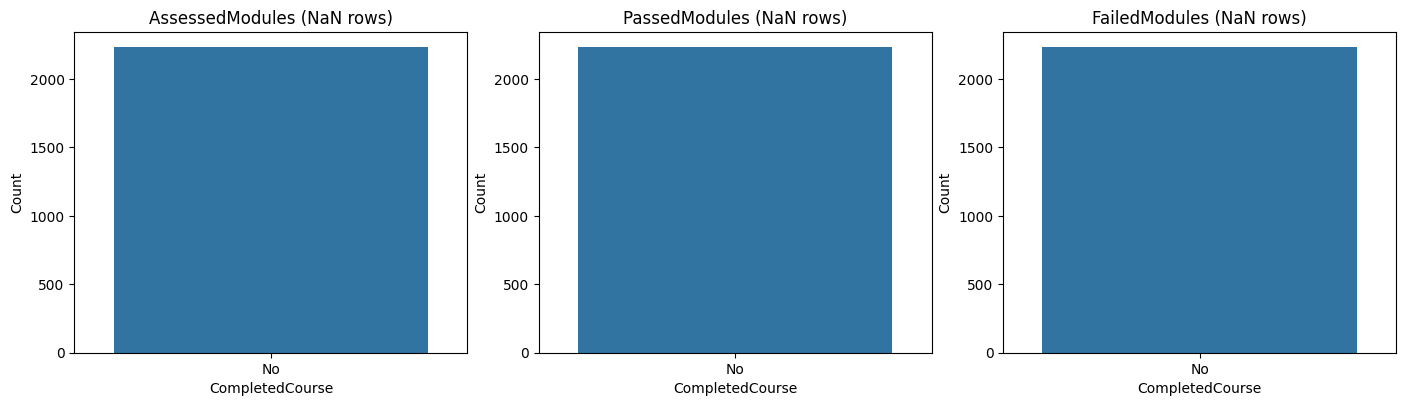

In [ ]:
# Create object that concatenates completedcourse and the isolated columns.

NaN_eval_s3 = pd.concat([study_data['CompletedCourse'],
                         isolated_columns_s3],
                        axis=1)

columns_to_check = isolated_columns_s3.columns

# Columns to inspect.

cols_s3 = isolated_columns_s3.columns

# Define grid size.

n_cols = 3
n_rows = math.ceil(len(cols_s3) / n_cols)

# Create subplot grid.

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
axes = axes.flatten()

# Populate plots.

for i, col in enumerate(cols_s3):
    subset = NaN_eval_s3[NaN_eval_s3[col].isna()]
    sns.countplot(
        data=subset,
        x="CompletedCourse",
        ax=axes[i]
    )

    axes[i].set_title(f"{col} (NaN rows)")
    axes[i].set_xlabel("CompletedCourse")
    axes[i].set_ylabel("Count")

# Remove unused axes if grid > number of columns.

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Tighten layout.

plt.tight_layout(pad=0.5)
plt.show()

Missing values in the module-related variables (modules assessed, passed, and failed) were imputed with zeros, as the absence of recorded module activity typically indicates that the student withdrew before completing any assessments, making zero a more realistic representation than imputing an average or median value.

In [ ]:
# Fill missing values of new columns with 0s.

isolated_columns_s3 = isolated_columns_s3.fillna(0)

# Check whether successful.

print(isolated_columns_s3.isna().sum())

AssessedModules    0
PassedModules      0
FailedModules      0
dtype: int64


## Pre-processing for model-readiness



In [ ]:
# Add the new isolated columns (from S2 & S3) so we can drop NaNs.

study_for_encoding_stage_3 = pd.concat([study_for_encoding,
                                        isolated_columns,     # From Stage 2
                                        isolated_columns_s3],
                                       axis=1)

print(f"Before dropping NaN rows: {study_for_encoding_stage_3.shape}")

# Drop columns with NaN values in the new isolated columns.

study_for_encoding_stage_3 = study_for_encoding_stage_3.dropna(subset=['AuthorisedAbsenceCount',
                                                                       'UnauthorisedAbsenceCount'])

print(f"After dropping NaN rows: {study_for_encoding_stage_3.shape}")

# Check for no NaN values after concatenation.

print("\n", study_for_encoding_stage_3[isolated_columns_s3.columns].isna().sum())

Before dropping NaN rows: (25059, 16)
After dropping NaN rows: (24851, 16)

 AssessedModules    0
PassedModules      0
FailedModules      0
dtype: int64


In [ ]:
# Separate why from the dataframe.

y_s3 = study_for_encoding_stage_3['y']
X_s3 = study_for_encoding_stage_3.drop(columns=['y'])

# Split the original data into train and test sets, with a 80:20 split.
X_train, X_test, y_train, y_test = train_test_split(X_s3, y_s3,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=seed)

# Split the train data further into train and validation sets, with a 90:10 split.
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train,
                                                  test_size=0.1,
                                                  stratify=y_train,
                                                  random_state=seed)

In [ ]:
# Define Stage 3 feature groups.

continuous_cols_s3 = [
    'Age',
    'AuthorisedAbsenceCount',
    'UnauthorisedAbsenceCount',
    'AssessedModules',
    'PassedModules',
    'FailedModules'
]

categorical_cols_s3 = [
    'CentreName',
    'BookingType',
    'LeadSource',
    'Gender',
    'IsFirstIntake',
    'Subregion',
    'ProgressionUniversity',
    'CourseName'
]

ordinal_cols_s3 = ['CourseLevel']

# Fit preprocessing on TRAIN only.

preprocessor_s3 = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), continuous_cols_s3),
        ("cat", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_cols_s3),
        ("ord", "passthrough", ordinal_cols_s3)
    ],
    remainder="drop"
)

# Fit on training data only.
X_train_processed_stage_3 = preprocessor_s3.fit_transform(X_train)

# Transform validation and test using the same fitted preprocessor.
X_val_processed_stage_3 = preprocessor_s3.transform(X_val)
X_test_processed_stage_3 = preprocessor_s3.transform(X_test)

# Recover feature names.
feature_names_s3 = preprocessor_s3.get_feature_names_out()

# Convert back to DataFrames for readability.
X_train_processed_stage_3 = pd.DataFrame(
    X_train_processed_stage_3,
    columns=feature_names_s3,
    index=X_train.index
)

X_val_processed_stage_3 = pd.DataFrame(
    X_val_processed_stage_3,
    columns=feature_names_s3,
    index=X_val.index
)

X_test_processed_stage_3 = pd.DataFrame(
    X_test_processed_stage_3,
    columns=feature_names_s3,
    index=X_test.index
)

# Ensure encoding has occurred.
print(f"New shape of the encoded Stage 3 training data: {X_train_processed_stage_3.shape}")

# Ensure there are no NaN values in the dataset.
print(f"Number of NaN values in Stage 3 training data: {X_train_processed_stage_3.isnull().sum().sum()}")

New shape of the encoded Stage 3 training data: (17892, 177)
Number of NaN values in Stage 3 training data: 0


## XGBoost - Preliminary Instantiation



XGBoost Baseline (Stage 3) Accuracy: 0.9875276604304969
XGBoost Baseline (Stage 3) AUC-ROC: 0.9987192684737943 

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       722
           1       0.99      0.99      0.99      4249

    accuracy                           0.99      4971
   macro avg       0.98      0.97      0.97      4971
weighted avg       0.99      0.99      0.99      4971



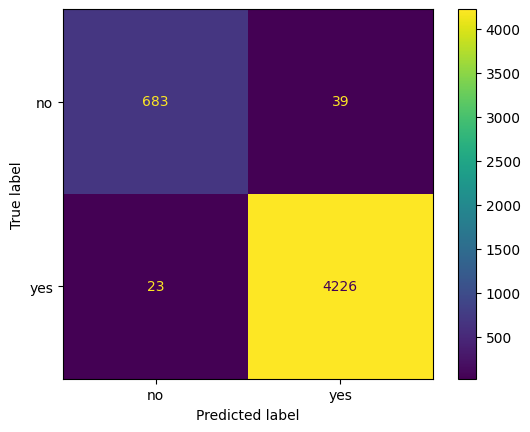

In [ ]:
# Fit Stage 3 baseline model on training data.

xgb_baseline_s3, baseline_preds_s3, baseline_probs_s3 = fit_evaluate_xgb(
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_val=X_val_processed_stage_3,
    y_val=y_val,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Baseline (Stage 3)"
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 3: XGBoost Baseline",
        y_true=y_test,
        y_pred=baseline_preds_s3,
        y_prob=baseline_probs_s3
    )
)

The Stage 3 baseline XGBoost model shows a dramatic improvement over Stage 2, achieving an accuracy of 0.988 and an AUC-ROC of 0.999, indicating near-perfect predictive performance once the final set of academic and engagement variables is included. The model performs strongly across both classes, with dropout recall increasing to 0.95 and course completion recall remaining at 0.99, substantially reducing the imbalance observed in earlier stages. These results demonstrate that the additional Stage 3 features provide highly informative signals for identifying students at risk of dropping out.

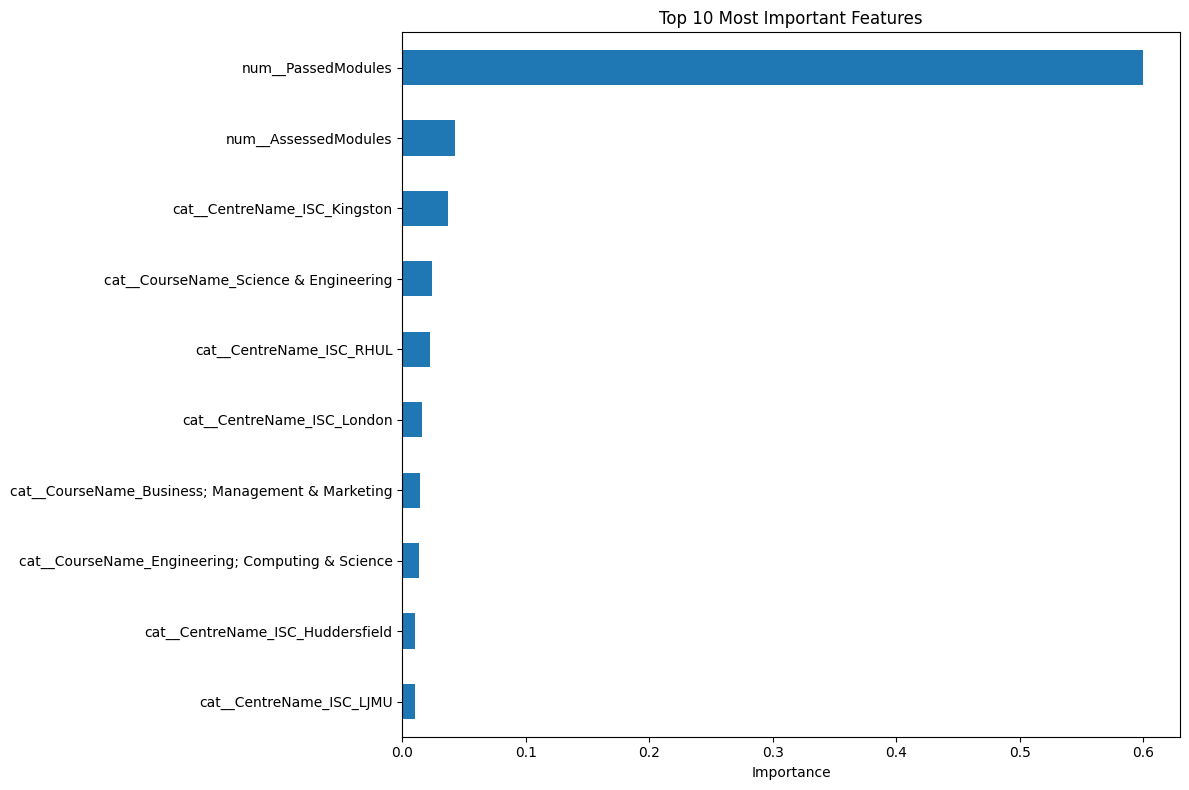

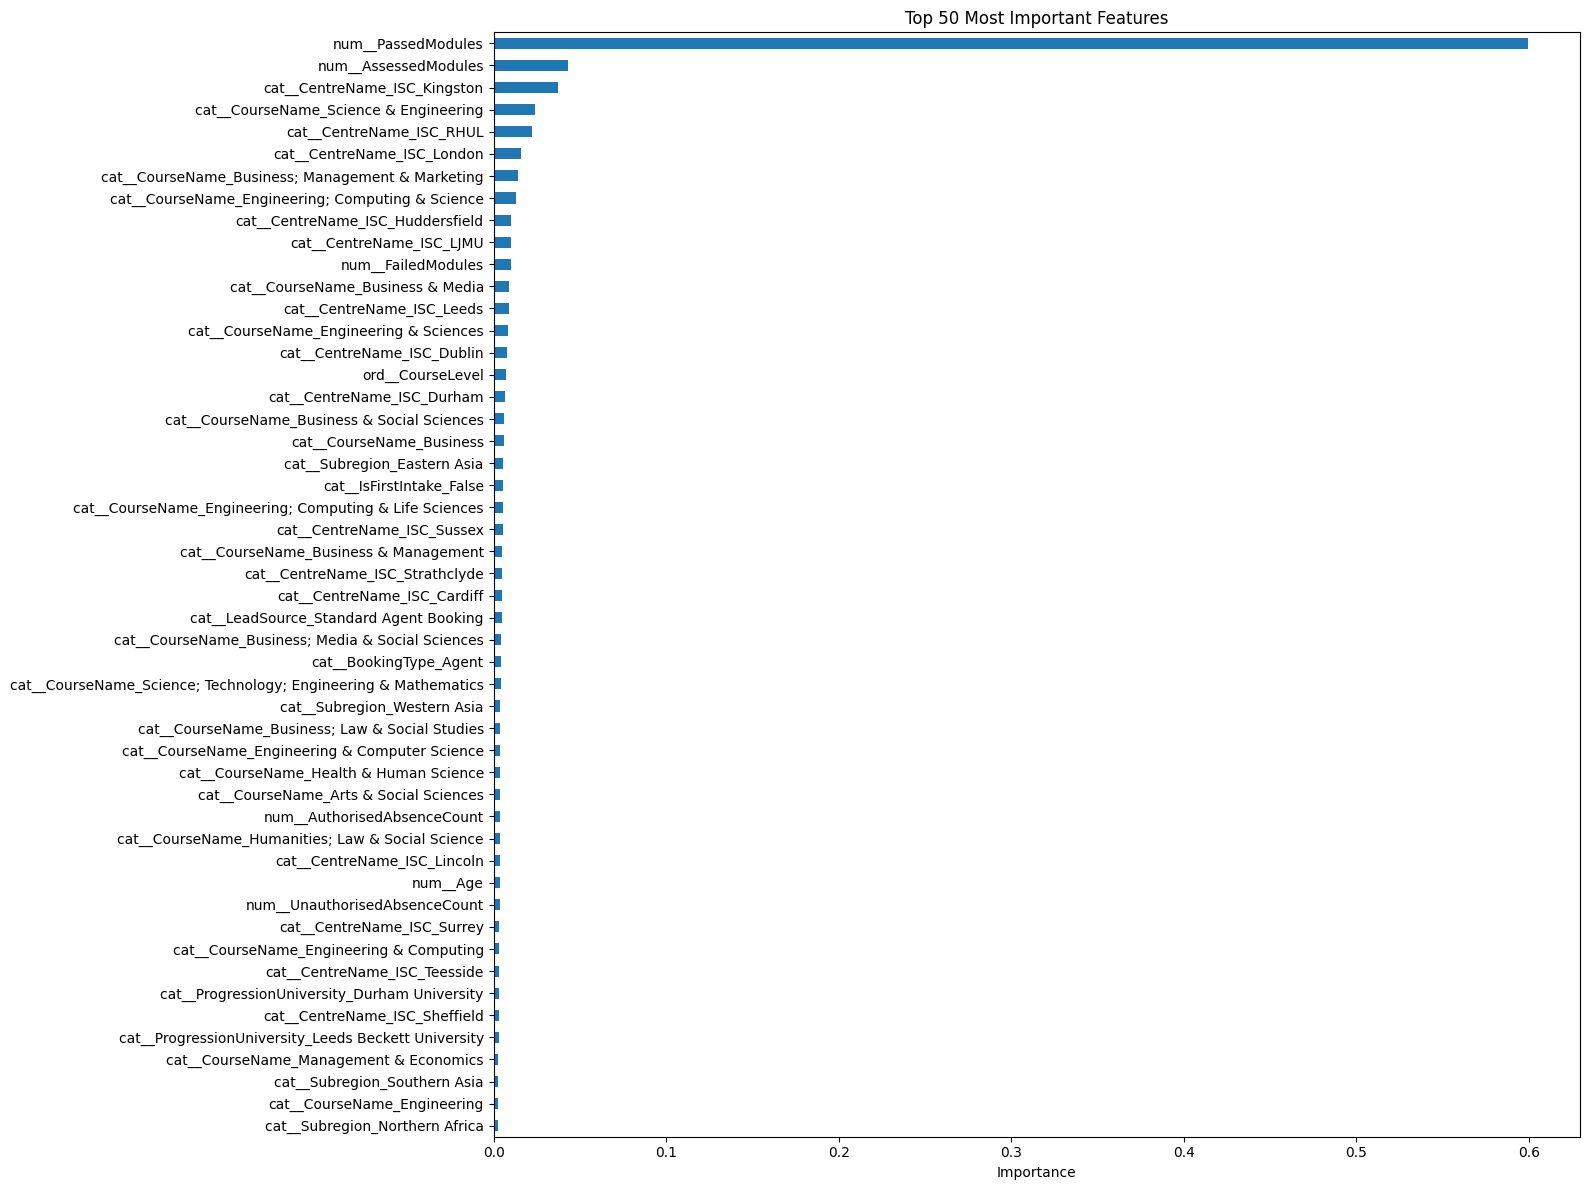

In [ ]:
# Plot Stage 3 feature importance.

plot_xgb_feature_importance(
    model=xgb_baseline_s3,
    X_processed=X_train_processed_stage_3
)

The feature importance results support the strong performance of the Stage 3 model, showing that academic progress variables dominate the predictions.

## XGBoost - Hyperparameter Tuning



In [ ]:
# Set up Stage 3 parameter grid.

models_param_grids_s3 = {
    'Stage 3: XGBoost - 3 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
        }
    },
    'Stage 3: XGBoost - 5 hps': {
        'model': XGBClassifier(
            random_state=seed,
            eval_metric='logloss',
            n_jobs=1
        ),
        'param_grid': {
            'n_estimators': [120, 200, 500],
            'learning_rate': [0.05, 0.1, 0.2],
            'max_depth': [2, 3, 5],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'gamma': [0, 0.1, 0.3],
        }
    }
}

# Stage 3 tuning containers
tuning_rows_s3 = []
best_estimators_s3 = {}

In [ ]:
# Perform Stage 3 hyperparameter tuning.

final_results_s3, best_estimators_s3, tuning_rows_s3 = run_model_gridsearch(
    models_param_grids=models_param_grids_s3,
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    scoring="roc_auc",
    cv=2,
    n_jobs=-1,
    verbose=0
)

print(final_results_s3)

Tuning: Stage 3: XGBoost - 3 hps
Tuning: Stage 3: XGBoost - 5 hps
                      model  best_cv_auc  test_auc  test_accuracy  \
0  Stage 3: XGBoost - 3 hps     0.999025  0.998802       0.987729   
1  Stage 3: XGBoost - 5 hps     0.999031  0.998698       0.987326   

   learning_rate  max_depth  n_estimators colsample_bytree      gamma  
0            0.1        3.0         500.0        Not tuned  Not tuned  
1            0.1        3.0         500.0              0.6        0.0  


Hyperparameter tuning produced only negligible changes relative to the already strong baseline model. The tuned configurations achieved very similar test AUC values: ~0.9987 - 0.9988 and accuracy: ~0.987 – 0.988, indicating that the baseline model was already close to optimal. Expanding the tuning space from three to five hyperparameters produced no meaningful improvement, with the simpler 3-parameter configuration marginally outperforming the extended search in test AUC. Overall, these results suggest that the predictive gains at Stage 3 are driven primarily by the addition of academic performance features rather than further parameter optimisation.

XGBoost Tuned (Stage 3) Accuracy: 0.9859183262924964
XGBoost Tuned (Stage 3) AUC-ROC: 0.9986154474019958 

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       722
           1       0.99      1.00      0.99      4249

    accuracy                           0.99      4971
   macro avg       0.98      0.96      0.97      4971
weighted avg       0.99      0.99      0.99      4971



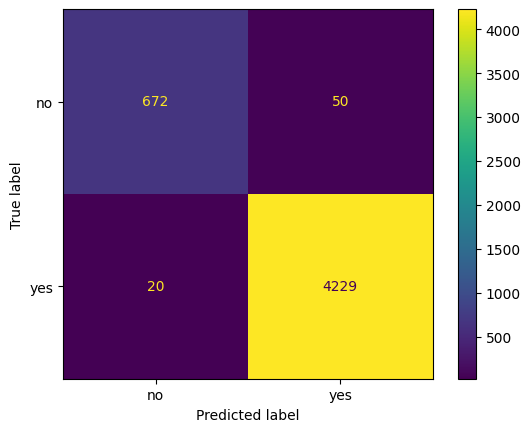

In [ ]:
# Fit Stage 3 tuned model on training data.

xgb_tuned_s3, tuned_preds_s3, tuned_probs_s3 = fit_evaluate_xgb(
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_val=X_val_processed_stage_3,
    y_val=y_val,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    random_state=seed,
    model_name="XGBoost Tuned (Stage 3)",

    # Tuned hyperparameters:
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    colsample_bytree=1.0,
    gamma=0.1
)

# Save the results to the log.

xgb_results.append(
    evaluate_model(
        model_name="Stage 3: XGBoost Tuned",
        y_true=y_test,
        y_pred=tuned_preds_s3,
        y_prob=tuned_probs_s3
    )
)

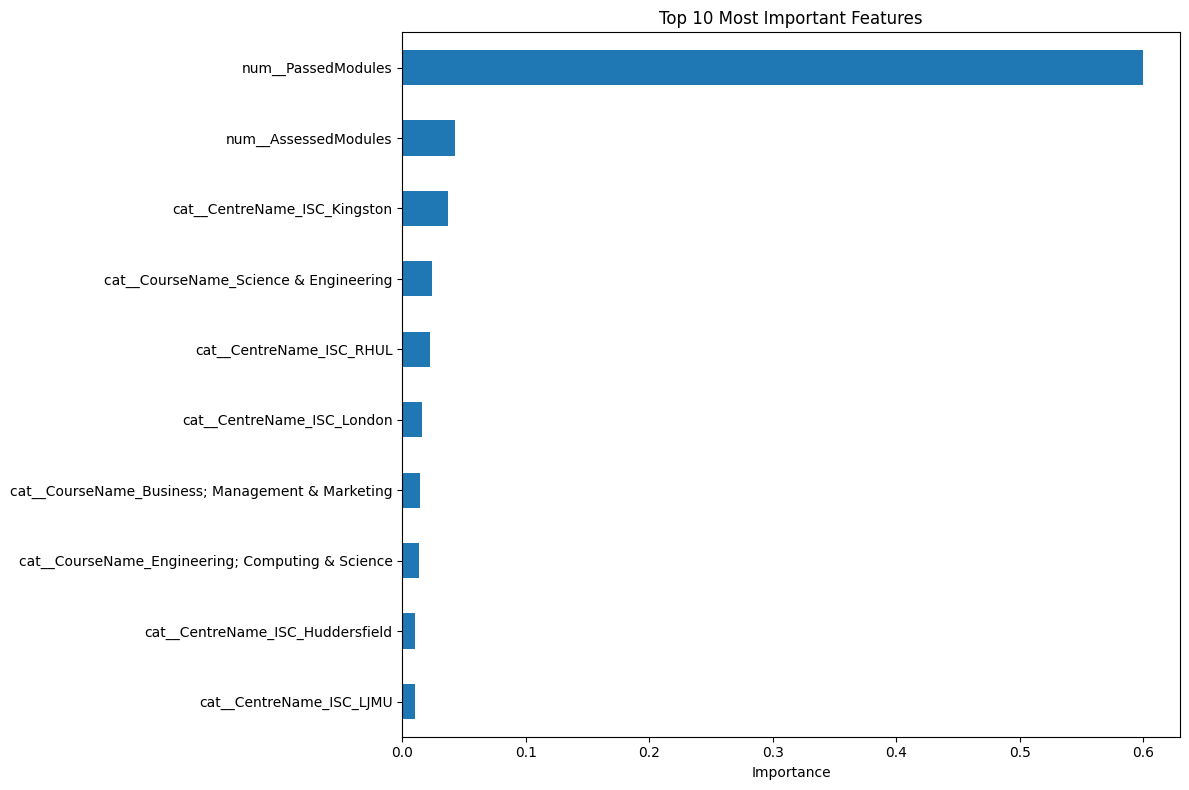

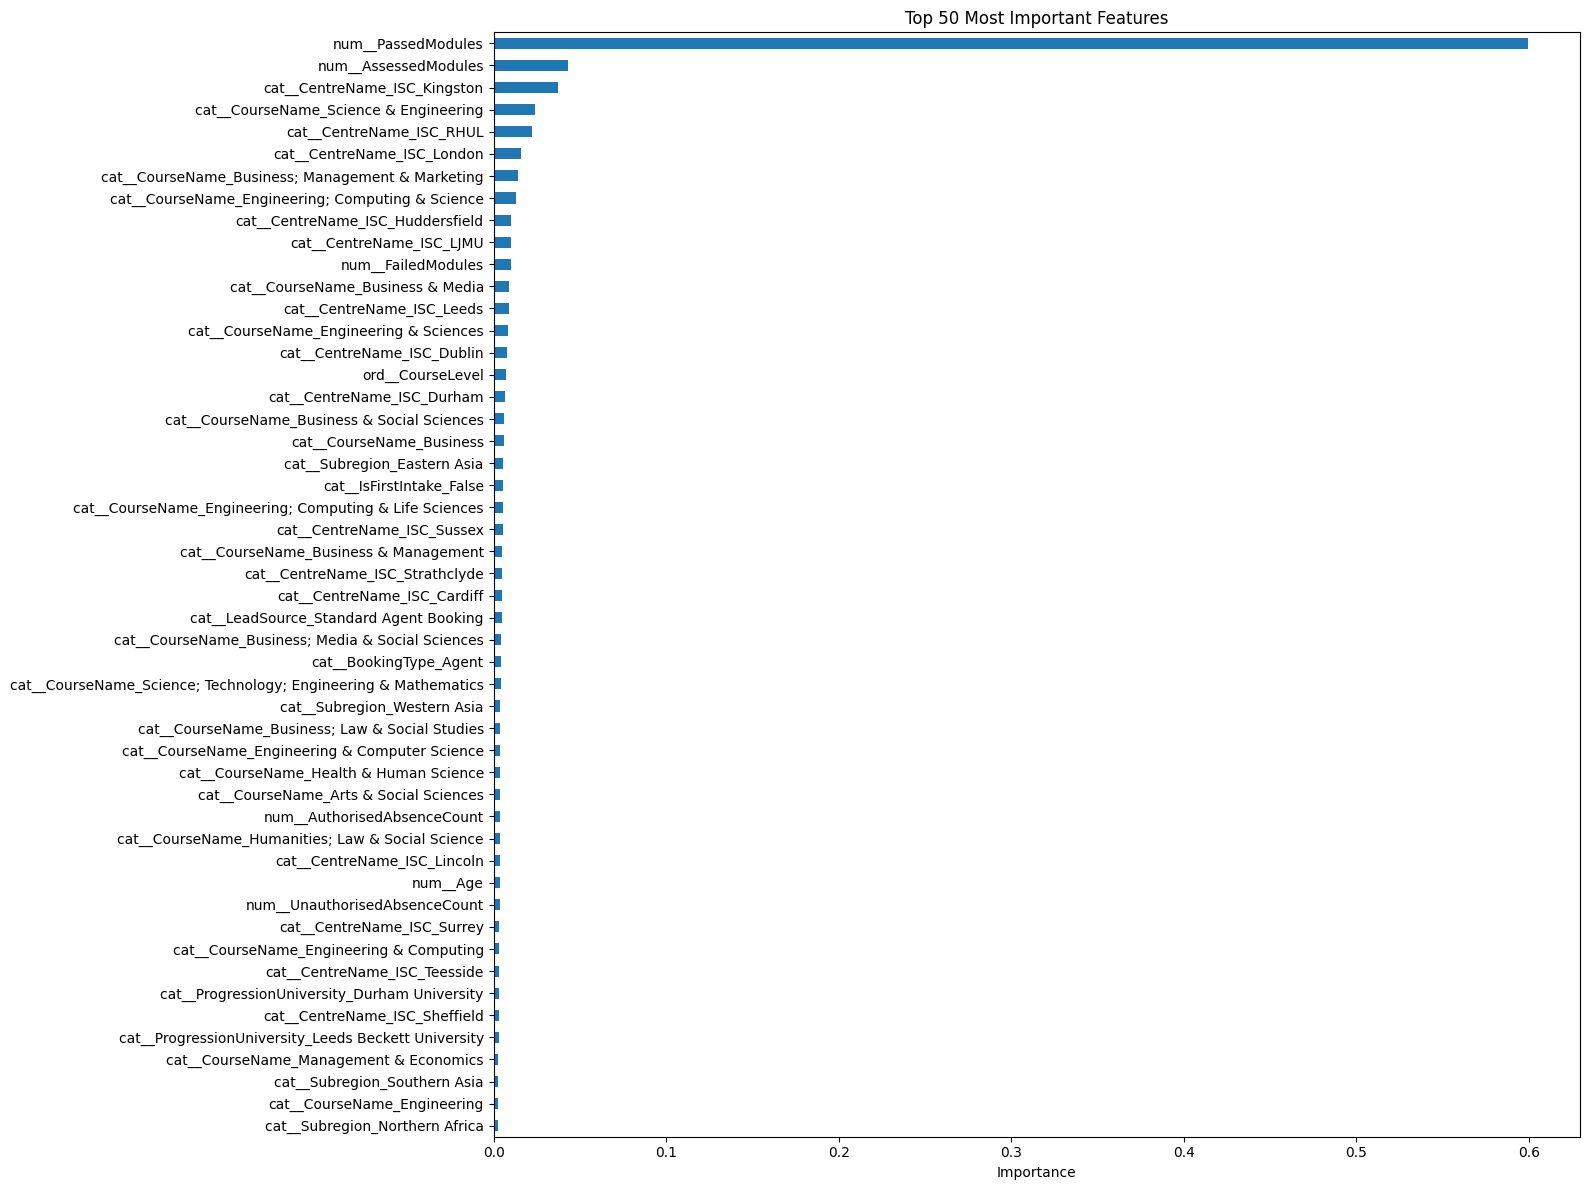

In [ ]:
# Plot Stage 3 feature importance.

plot_xgb_feature_importance(
    model=xgb_baseline_s3,
    X_processed=X_train_processed_stage_3
)

## Neural Network - Preliminary Instantiation


Neural Network Baseline (Stage 3) Test loss: 0.0368
Neural Network Baseline (Stage 3) Accuracy: 0.9845
Neural Network Baseline (Stage 3) AUC-ROC: 0.9984 

              precision    recall  f1-score   support

           0       0.95      0.94      0.95       722
           1       0.99      0.99      0.99      4249

    accuracy                           0.98      4971
   macro avg       0.97      0.97      0.97      4971
weighted avg       0.98      0.98      0.98      4971



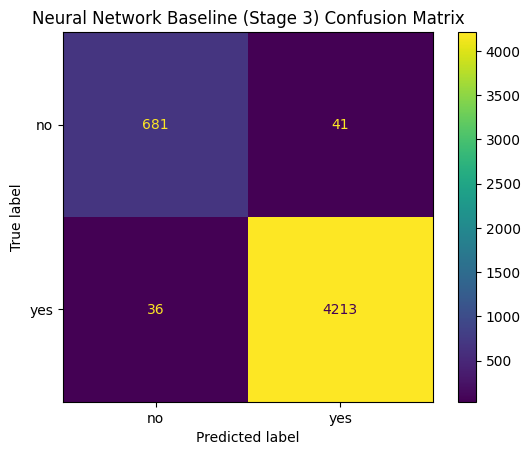

In [ ]:
# Instantiate Stage 3 basic neural network.

nn_baseline_s3, baseline_history_s3, baseline_score_s3, \
nn_baseline_preds_s3, nn_baseline_probs_s3 = fit_evaluate_nn(
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_val=X_val_processed_stage_3,
    y_val=y_val,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    hidden_layers=(64, 32, 16),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,      # default Adam learning rate
    dropout_rate=0.0,        # turned off
    l2_strength=0.0,         # turned off
    batch_size=32,
    epochs=8,
    use_early_stopping=False,
    verbose=0,
    model_name="Neural Network Baseline (Stage 3)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

nn_results.append(
    evaluate_model(
        model_name="Stage 3: Neural Network - Baseline",
        y_true=y_test,
        y_pred=nn_baseline_preds_s3,
        y_prob=nn_baseline_probs_s3
    )
)

The Stage 3 baseline neural network achieved very strong predictive performance, with an accuracy of 0.9845 and an AUC-ROC of 0.9984. The model performs well across both classes, correctly identifying 94% of dropout cases and 99% of course completions, indicating that the inclusion of Stage 3 academic variables provides highly informative signals for prediction.

Compared with the Stage 3 baseline XGBoost model (accuracy 0.9875, AUC-ROC 0.9987), the neural network delivers very similar overall performance, although XGBoost remains marginally stronger in both accuracy and AUC. This suggests that while both approaches perform extremely well with the full feature set, tree-based models retain a slight advantage on this structured tabular dataset.

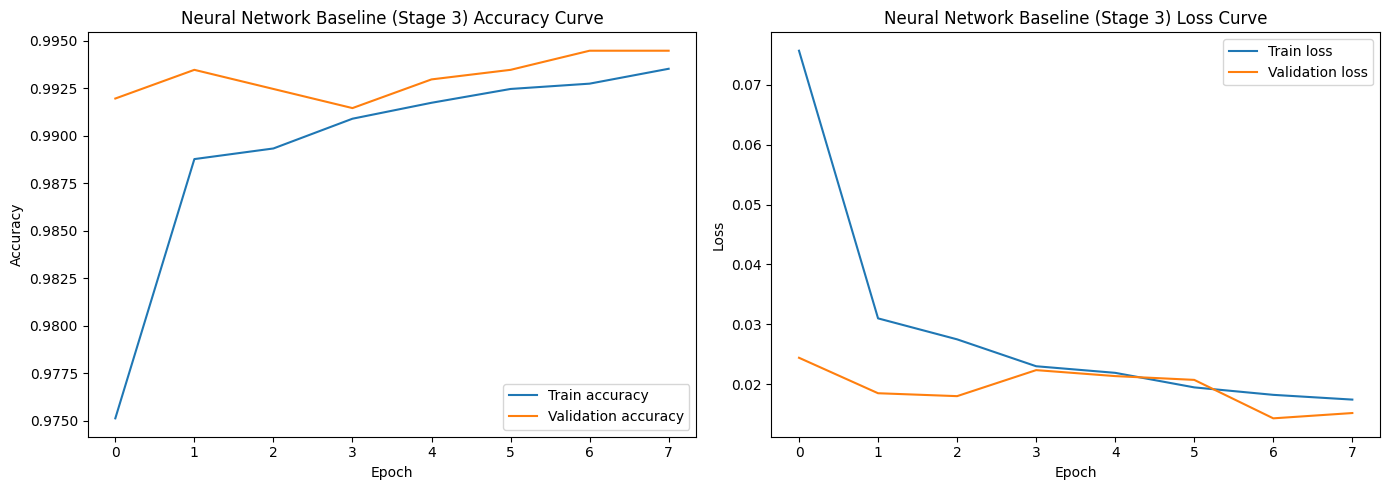

In [ ]:
# Plot accuracy and loss curves.

plot_nn_learning_curves(
    baseline_history_s3,
    model_name="Neural Network Baseline (Stage 3)"
)

The learning curves show stable and well-behaved training, with training accuracy increasing steadily and training loss declining rapidly, indicating effective learning.

## Neural Network - Hyperparameter Tuning

In [ ]:
# Specify Stage 3 hyperparameter grid.

nn_param_grid_s3 = {
    "neurons": [
        (32, 16, 8),
        (64, 32, 16),
        (128, 64, 32)
    ],
    "optimizer": ["adam", "rmsprop"],
    "hidden_activation": ["relu"],
    "dropout_rate": [0.2],
    "l2_strength": [0.001]
}

# Run Stage 3 manual hyperparameter search using the NN function.

nn_tuning_results_s3 = []
best_nn_models_s3 = {}
best_nn_histories_s3 = {}

In [ ]:
for params in ParameterGrid(nn_param_grid_s3):

    # Create a readable model name.
    model_name = (
        f"Stage 3 | NN | neurons={params['neurons']} | "
        f"optimizer={params['optimizer']} | "
        f"activation={params['hidden_activation']} | "
        f"dropout={params['dropout_rate']} | "
        f"l2={params['l2_strength']}"
    )

    model, history, score, test_preds, test_probs = fit_evaluate_nn(
        X_train=X_train_processed_stage_3,
        y_train=y_train,
        X_val=X_val_processed_stage_3,
        y_val=y_val,
        X_test=X_test_processed_stage_3,
        y_test=y_test,
        hidden_layers=params["neurons"],
        hidden_activation=params["hidden_activation"],
        optimizer=params["optimizer"],
        learning_rate=None,                 # use default optimiser learning rate
        dropout_rate=params["dropout_rate"],
        l2_strength=params["l2_strength"],
        batch_size=32,
        epochs=30,
        use_early_stopping=True,
        patience=3,
        verbose=0,
        model_name=model_name,
        show_metrics=False,
        show_classification_report=False,
        show_confusion_matrix=False
    )

    # Validation probabilities for validation AUC.
    val_probs = model.predict(X_val_processed_stage_3, verbose=0).ravel()

    # Store metrics
    nn_tuning_results_s3.append({
        "Model": model_name,
        "Neurons": params["neurons"],
        "Optimizer": params["optimizer"],
        "Activation": params["hidden_activation"],
        "Dropout": params["dropout_rate"],
        "L2": params["l2_strength"],
        "Epochs Run": len(history.history["loss"]),
        "Best Val AUC": roc_auc_score(y_val, val_probs),
        "Test Accuracy": accuracy_score(y_test, test_preds),
        "Test Precision": precision_score(y_test, test_preds),
        "Test Recall": recall_score(y_test, test_preds),
        "Test F1": f1_score(y_test, test_preds),
        "Test AUC-ROC": roc_auc_score(y_test, test_probs)
    })

    best_nn_models_s3[model_name] = model
    best_nn_histories_s3[model_name] = history


# Create and sort Stage 3 results table.

nn_tuning_results_df_s3 = pd.DataFrame(nn_tuning_results_s3).sort_values(
    by="Test AUC-ROC",
    ascending=False
).round(4)

print(nn_tuning_results_df_s3.drop(columns=["Model"]))

         Neurons Optimizer Activation  Dropout     L2  Epochs Run  \
0    (32, 16, 8)      adam       relu      0.2  0.001          27   
2   (64, 32, 16)      adam       relu      0.2  0.001          14   
4  (128, 64, 32)      adam       relu      0.2  0.001          11   
3   (64, 32, 16)   rmsprop       relu      0.2  0.001           9   
5  (128, 64, 32)   rmsprop       relu      0.2  0.001          10   
1    (32, 16, 8)   rmsprop       relu      0.2  0.001          21   

   Best Val AUC  Test Accuracy  Test Precision  Test Recall  Test F1  \
0        0.9996         0.9859          0.9872       0.9965   0.9918   
2        0.9996         0.9863          0.9890       0.9951   0.9920   
4        0.9995         0.9859          0.9890       0.9946   0.9918   
3        0.9991         0.9833          0.9865       0.9941   0.9903   
5        0.9992         0.9835          0.9883       0.9925   0.9904   
1        0.9992         0.9841          0.9892       0.9922   0.9907   

   Test AUC

The hyperparameter tests produced very similar results across all neural network configurations, indicating that model performance was largely insensitive to changes in architecture or optimiser. Test accuracy ranged narrowly between 0.983 and 0.986, while AUC-ROC remained extremely high (≈0.997–0.999) across all models. The best-performing configuration used (32, 16, 8) neurons with the Adam optimiser, achieving a test AUC-ROC of 0.9986 and accuracy of 0.9859, although several alternative configurations produced nearly identical results. Overall, the findings suggest that the strong predictive performance at Stage 3 is driven primarily by the dataset’s academic variables rather than neural network architecture.


Neural Network (Tuned, Stage 3) Test loss: 0.0484
Neural Network (Tuned, Stage 3) Accuracy: 0.9871
Neural Network (Tuned, Stage 3) AUC-ROC: 0.9985 

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       722
           1       0.99      0.99      0.99      4249

    accuracy                           0.99      4971
   macro avg       0.98      0.97      0.97      4971
weighted avg       0.99      0.99      0.99      4971



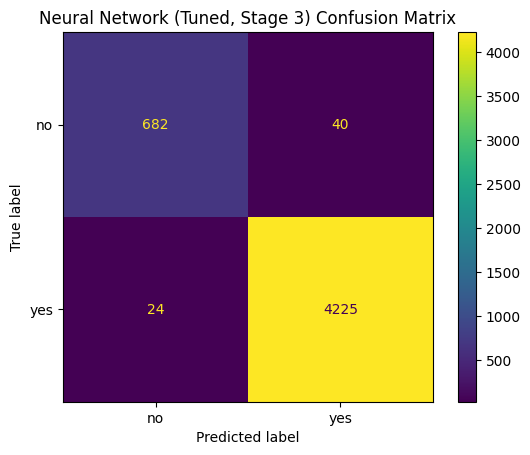

In [ ]:
# Instantiate tuned Stage 3 neural network for detailed review of results.

nn_tuned_s3, tuned_history_s3, tuned_score_s3, \
nn_tuned_preds_s3, nn_tuned_probs_s3 = fit_evaluate_nn(
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_val=X_val_processed_stage_3,
    y_val=y_val,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    hidden_layers=(128, 64, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Tuned, Stage 3)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 3: Neural Network - Tuned",
        y_true=y_test,
        y_pred=nn_tuned_preds_s3,
        y_prob=nn_tuned_probs_s3
    )
)

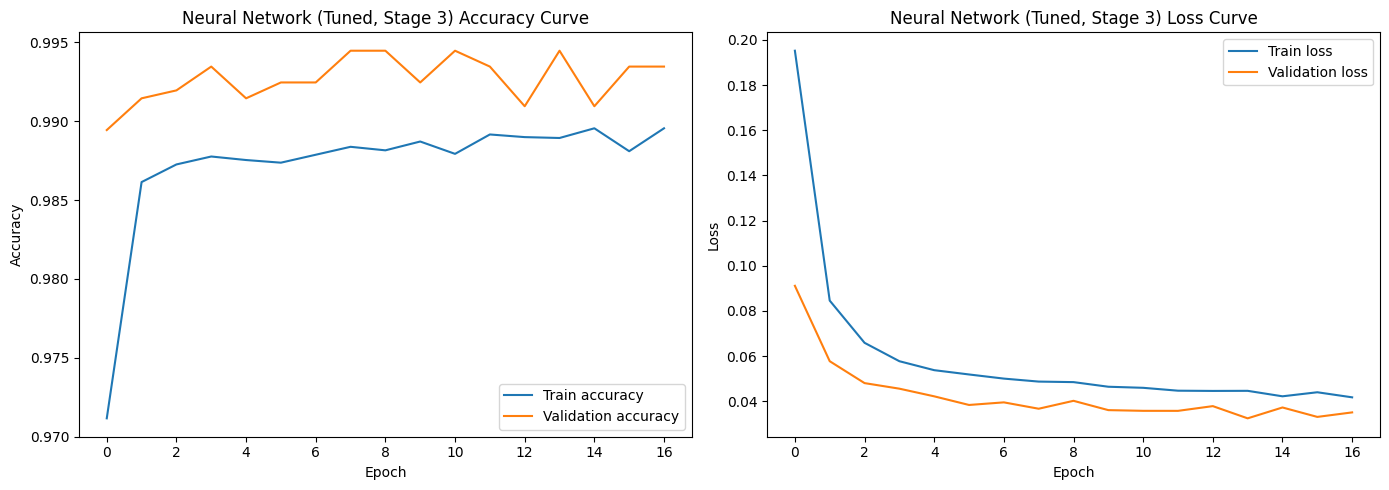

In [ ]:
# Plot learning curves.

plot_nn_learning_curves(
    tuned_history_s3,
    model_name="Neural Network (Tuned, Stage 3)"
)


Neural Network (Deep, Stage 3) Test loss: 0.0548
Neural Network (Deep, Stage 3) Accuracy: 0.9865
Neural Network (Deep, Stage 3) AUC-ROC: 0.9985 

              precision    recall  f1-score   support

           0       0.97      0.93      0.95       722
           1       0.99      1.00      0.99      4249

    accuracy                           0.99      4971
   macro avg       0.98      0.96      0.97      4971
weighted avg       0.99      0.99      0.99      4971



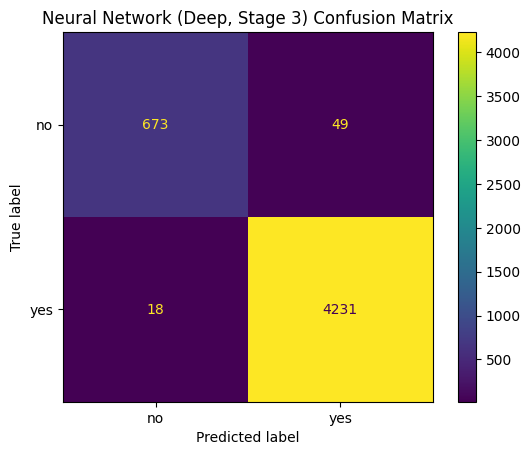

In [ ]:
# Instantiate deep Stage 3 neural network for detailed review of results.

nn_deep_s3, deep_history_s3, deep_score_s3, \
nn_deep_preds_s3, nn_deep_probs_s3 = fit_evaluate_nn(
    X_train=X_train_processed_stage_3,
    y_train=y_train,
    X_val=X_val_processed_stage_3,
    y_val=y_val,
    X_test=X_test_processed_stage_3,
    y_test=y_test,
    hidden_layers=(128, 64, 64, 32, 32),
    hidden_activation="relu",
    optimizer="adam",
    learning_rate=None,
    dropout_rate=0.2,
    l2_strength=0.001,
    batch_size=32,
    epochs=30,
    use_early_stopping=True,
    verbose=0,
    model_name="Neural Network (Deep, Stage 3)",
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True
)

# Save the results to the log.

nn_results.append(
    evaluate_model(
        model_name="Stage 3: Neural Network - Deep",
        y_true=y_test,
        y_pred=nn_deep_preds_s3,
        y_prob=nn_deep_probs_s3
    )
)

The deep Stage 3 neural network achieved very strong predictive performance, with accuracy of 0.9865 and AUC-ROC of 0.9985. Compared with the Stage 3 baseline neural network (accuracy 0.9845, AUC-ROC 0.9984), the deeper model delivers only marginal improvements, indicating that increasing model depth provides limited additional benefit once the full feature set is available. Performance remains strong across both classes, with near-perfect identification of course completions (recall ≈1.00) and high accuracy in detecting dropouts (recall = 0.93). Overall, the results suggest that dataset richness rather than network complexity is the primary driver of predictive performance at Stage 3.

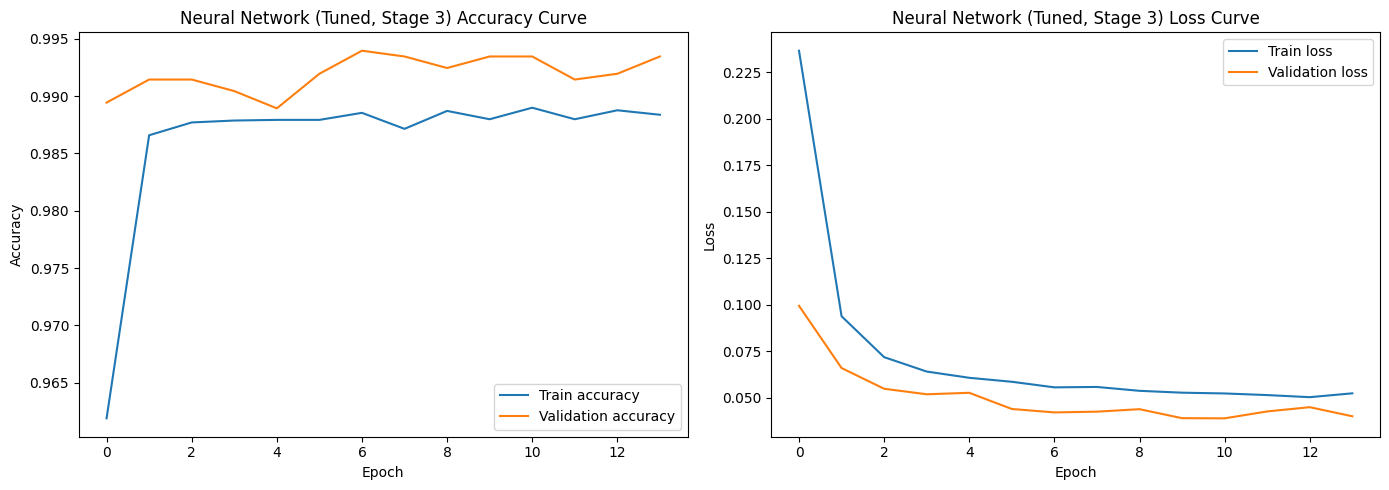

In [ ]:
# Plot learning curves.

plot_nn_learning_curves(
    deep_history_s3,
    model_name="Neural Network (Tuned, Stage 3)"
)

# Summary of Results

XGBoost Results:

,Step,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,1,Stage 1: XGBoost Baseline,0.8883,0.9245,0.9458,0.9350,0.8674
1,2,Stage 1: XGBoost Tuned,0.8841,0.9172,0.9493,0.9330,0.8690
2,3,Stage 2: XGBoost Baseline,0.9103,0.9352,0.9616,0.9482,0.9172
3,4,Stage 2: XGBoost Tuned,0.9089,0.9353,0.9598,0.9474,0.9160
4,5,Stage 3: XGBoost Baseline,0.9875,0.9909,0.9946,0.9927,0.9987
5,6,Stage 3: XGBoost Tuned,0.9859,0.9883,0.9953,0.9918,0.9986


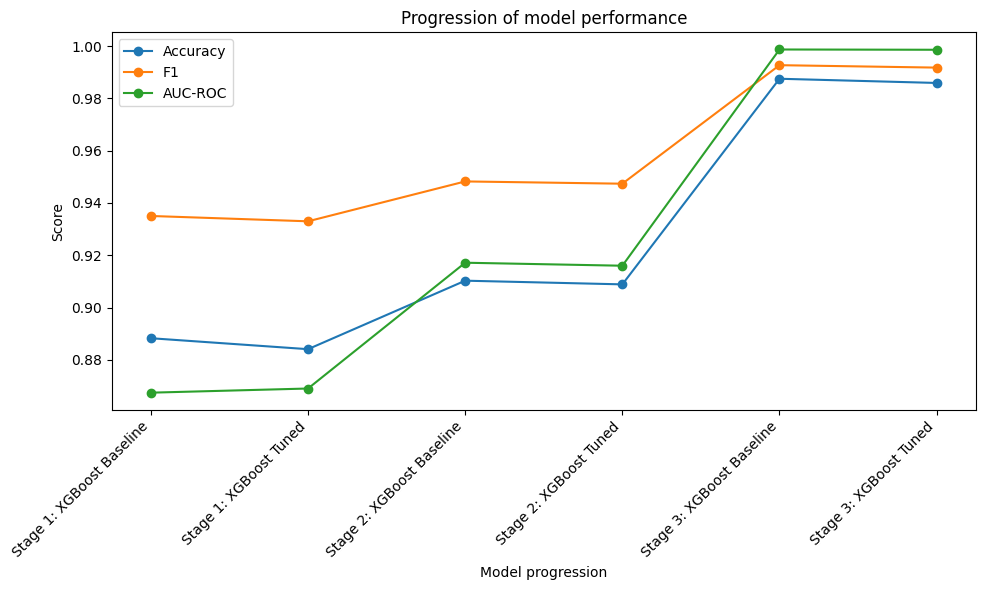

In [ ]:
# Convert results log to DataFrame and preserve model order

xgb_final_results_df = pd.DataFrame(xgb_results)
xgb_final_results_df["Step"] = range(1, len(xgb_final_results_df) + 1)

# Display results table

display(
    xgb_final_results_df[
        ["Step", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
    ].round(4)
)

# Plot performance progression across models

plt.figure(figsize=(10, 6))

plt.plot(xgb_final_results_df["Step"], xgb_final_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(xgb_final_results_df["Step"], xgb_final_results_df["F1"], marker="o", label="F1")
plt.plot(xgb_final_results_df["Step"], xgb_final_results_df["AUC-ROC"], marker="o", label="AUC-ROC")

plt.xticks(
    xgb_final_results_df["Step"],
    xgb_final_results_df["Model"],
    rotation=45,
    ha="right"
)

plt.xlabel("Model progression")
plt.ylabel("Score")
plt.title("Progression of model performance")
plt.legend()
plt.tight_layout()

plt.show()

Model performance improves substantially as additional features are introduced across stages. While Stage 1 models achieve moderate predictive accuracy (AUC ≈0.87) and Stage 2 models show clear improvement (AUC ≈0.92), the Stage 3 models achieve near-perfect performance (AUC ≈0.999) once academic progression variables are included. Hyperparameter tuning produced only marginal differences relative to the baseline models, indicating that the primary driver of performance gains was the addition of Stage 3 academic features rather than parameter optimisation.

Neural Network Results:

,Step,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,1,Stage 1: Neural Network - Baseline,0.8847,0.9365,0.9272,0.9318,0.8732
1,2,Stage 1: Neural Network - Tuned,0.8875,0.9243,0.9451,0.9346,0.8708
2,3,Stage 1: Neural Network - Deep,0.8863,0.9222,0.9460,0.9340,0.8676
3,4,Stage 2: Neural Network - Baseline,0.8994,0.9439,0.9381,0.9410,0.9067
4,5,Stage 2: Neural Network - Tuned,0.9002,0.9383,0.9454,0.9419,0.9108
5,6,Stage 2: Neural Network - Deep,0.8984,0.9474,0.9329,0.9401,0.9083
6,7,Stage 3: Neural Network - Baseline,0.9845,0.9904,0.9915,0.9909,0.9984
7,8,Stage 3: Neural Network - Tuned,0.9871,0.9906,0.9944,0.9925,0.9985
8,9,Stage 3: Neural Network - Deep,0.9865,0.9886,0.9958,0.9921,0.9985


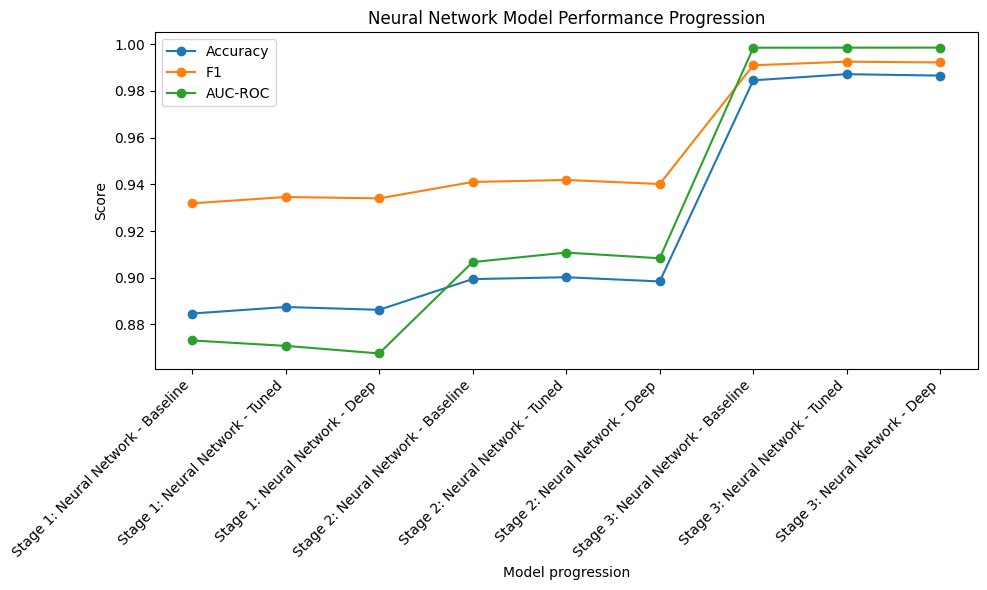

In [ ]:
# Convert neural network results log to DataFrame and preserve model order

nn_final_results_df = pd.DataFrame(nn_results)
nn_final_results_df["Step"] = range(1, len(nn_final_results_df) + 1)

# Display results table

display(
    nn_final_results_df[
        ["Step", "Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
    ].round(4)
)

# Plot performance progression across neural network models

plt.figure(figsize=(10, 6))

plt.plot(nn_final_results_df["Step"], nn_final_results_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(nn_final_results_df["Step"], nn_final_results_df["F1"], marker="o", label="F1")
plt.plot(nn_final_results_df["Step"], nn_final_results_df["AUC-ROC"], marker="o", label="AUC-ROC")

plt.xticks(
    nn_final_results_df["Step"],
    nn_final_results_df["Model"],
    rotation=45,
    ha="right"
)

plt.xlabel("Model progression")
plt.ylabel("Score")
plt.title("Neural Network Model Performance Progression")
plt.legend()
plt.tight_layout()

plt.show()

Neural network performance follows the same pattern as the XGBoost models, improving steadily as additional features are introduced across stages. Stage 1 models achieve moderate performance (AUC ≈0.87), Stage 2 models improve meaningfully (AUC ≈0.91), and Stage 3 models reach near-perfect predictive performance (AUC ≈0.998) once academic progression variables are included. Differences between baseline, tuned, and deep architectures are minimal, indicating that model complexity and tuning contribute little additional benefit compared with the predictive power of the Stage 3 features.

Final Ranked Leaderboard:

,Model,Accuracy,Precision,Recall,F1,AUC-ROC
0,Stage 3: XGBoost Baseline,0.9875,0.9909,0.9946,0.9927,0.9987
1,Stage 3: XGBoost Tuned,0.9859,0.9883,0.9953,0.9918,0.9986
2,Stage 3: Neural Network - Deep,0.9865,0.9886,0.9958,0.9921,0.9985
3,Stage 3: Neural Network - Tuned,0.9871,0.9906,0.9944,0.9925,0.9985
4,Stage 3: Neural Network - Baseline,0.9845,0.9904,0.9915,0.9909,0.9984
5,Stage 2: XGBoost Baseline,0.9103,0.9352,0.9616,0.9482,0.9172
6,Stage 2: XGBoost Tuned,0.9089,0.9353,0.9598,0.9474,0.9160
7,Stage 2: Neural Network - Tuned,0.9002,0.9383,0.9454,0.9419,0.9108
8,Stage 2: Neural Network - Deep,0.8984,0.9474,0.9329,0.9401,0.9083
9,Stage 2: Neural Network - Baseline,0.8994,0.9439,0.9381,0.9410,0.9067


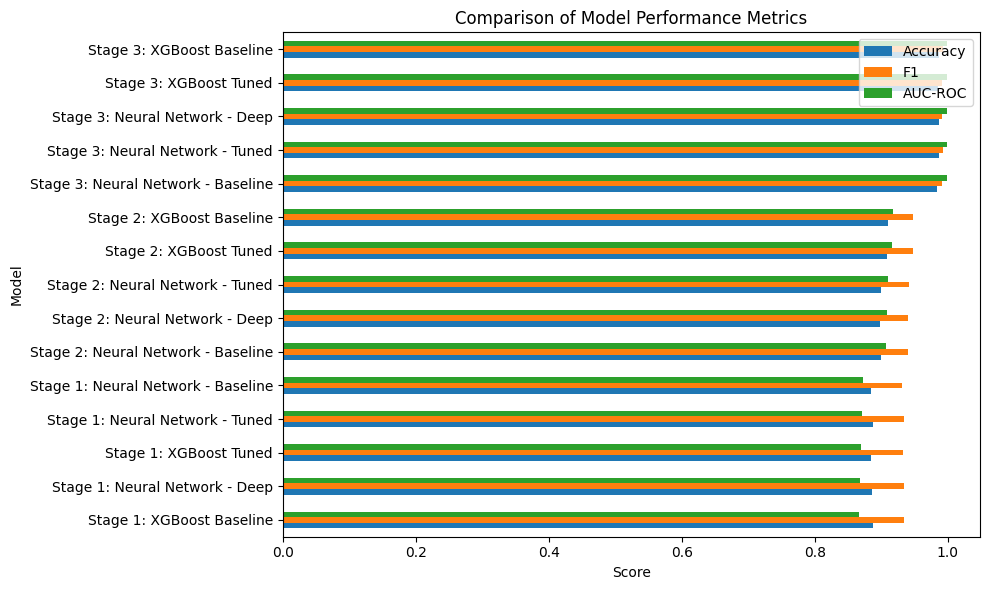

In [ ]:
# Combine XGBoost and Neural Network results

all_model_results_df = pd.concat(
    [xgb_final_results_df, nn_final_results_df],
    ignore_index=True
)

# Sort by AUC-ROC

all_model_results_df = all_model_results_df.sort_values(
    by="AUC-ROC",
    ascending=False
).reset_index(drop=True)

display(
    all_model_results_df[
        ["Model", "Accuracy", "Precision", "Recall", "F1", "AUC-ROC"]
    ].round(4)
)

metrics_to_plot = ["Accuracy", "F1", "AUC-ROC"]

plot_df = all_model_results_df.set_index("Model")[metrics_to_plot]

# Sort plot_df by 'AUC-ROC' in ascending order.

plot_df = plot_df.sort_values(by="AUC-ROC", ascending=True)

plot_df.plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Score")
plt.title("Comparison of Model Performance Metrics")

plt.tight_layout()
plt.show()

The Stage 3 XGBoost baseline model achieved the strongest overall performance, with an accuracy of 0.9875 and an AUC-ROC of 0.9987, narrowly outperforming all other configurations. Across both model types, performance improves consistently from Stage 1 to Stage 3, with accuracy rising from approximately 0.88 to nearly 0.99 and AUC-ROC increasing from ~0.87 to ~0.999. Precision, recall and F1 scores also become increasingly uniform at higher stages, indicating that models not only become more accurate overall but also more balanced in identifying both dropout and completion cases. These results suggest that the additional Stage 3 academic variables substantially strengthen predictive performance, while differences between model architectures and tuning strategies remain relatively small once the full feature set is available.

In [ ]:
# Best model.

best_model = all_model_results_df.iloc[0]

print("Best Model:", best_model["Model"])
print("AUC-ROC:", round(best_model["AUC-ROC"],4))

Best Model: Stage 3: XGBoost Baseline
AUC-ROC: 0.9987


# Declaration
By submitting your project, you indicate that the work is your own and has been created with academic integrity. Refer to the **Cambridge plagiarism regulations**.
